In [1]:
from astropy.io import fits
import numpy as np

## Read in data tables from DAP file

In [2]:
hdulist = fits.open("dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits")

Look at what Tables we have in the file. The data model is explained in [this wiki page](https://sdss-wiki.atlassian.net/wiki/spaces/LVM/pages/14461007/lvmdap+datamodel)

In [3]:
hdulist.info()

Filename: dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     937   ()      
  1  PT            1 BinTableHDU     21   1754R x 6C   [9A, D, D, L, K, K]   
  2  RSP           1 BinTableHDU    101   1754R x 31C   [9A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  3  COEFFS        1 BinTableHDU     35   189432R x 13C   [9A, K, K, D, D, D, D, D, D, D, D, D, D]   
  4  PM_ELINES     1 BinTableHDU     29   26310R x 10C   [9A, K, 12A, D, D, D, D, D, D, D]   
  5  NP_ELINES_B    1 BinTableHDU   1835   1754R x 913C   [9A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

## Read as astropy Tables

In [4]:
from astropy.table import QTable, Table

In [5]:
hdulist["PM_ELINES"]

I used QTable in case the tables contained units information, but they do not :(

In [6]:
tab = QTable.read("dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits")

The first table has the coordinates of each fiber

In [7]:
tab

id,ra,dec,mask,fiberid,exposure
bytes9,float64,float64,bool,int64,int64
8373.3,84.67961498496138,-69.34061933106359,True,3,8373
8373.4,84.7049101580789,-69.33546682542983,True,4,8373
8373.5,84.7301932852563,-69.33031063050338,True,5,8373
8373.6,84.75537595951486,-69.32515079003531,True,6,8373
8373.7,84.78063501226731,-69.31998723866025,True,7,8373
8373.8,84.8058820154534,-69.31482000725026,True,8,8373
8373.9,84.83111696789611,-69.30964909889398,True,9,8373
8373.10,84.85633986843807,-69.30447451668014,True,10,8373
8373.11,84.88146241616775,-69.29929636860746,True,11,8373


### Parametric emission line parameters

Then we have the parametric profile parameters (gaussian fits) for the strongest lines

In [8]:
tab_pm_elines = QTable.read(
    "dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="PM_ELINES"
)

These have a long structure where each row is a (fiber, emline) combination.

In [9]:
tab_pm_elines

id,id_fib,model,wl,flux,e_flux,disp,e_disp,vel,e_vel
bytes9,int64,bytes12,float64,float64,float64,float64,float64,float64,float64
8373.3,0,eline,6562.85,5784.8039,97.0526,0.7926,0.0176,271.2948,4.1523
8373.3,0,eline,6583.45,752.8998,77.5874,0.7926,0.0176,271.2948,4.1523
8373.3,0,eline,6548.05,250.7156,72.4471,0.7926,0.0176,271.2948,4.1523
8373.3,0,eline,6730.82,858.3355,67.8976,0.7812,0.0182,277.4763,5.32
8373.3,0,eline,6716.44,1215.5934,50.688,0.7812,0.0182,277.4763,5.32
8373.3,0,eline,5006.84,3513.4461,635.8285,0.7663,0.0156,269.4501,0.8445
8373.3,0,eline,4958.91,1169.9776,634.9232,0.7663,0.0156,269.4501,0.8445
8373.3,0,eline,4861.36,1694.211,636.0005,0.7663,0.0156,269.4501,0.8445
8373.3,0,eline,4340.49,811.774,163.7356,0.7199,0.0,263.6887,3.915


We can try and convert to a tidy wide format (over emission lines and parameters) with pandas pivot():

In [10]:
import pandas as pd

In [11]:
columns = tab_pm_elines.colnames[4:]
columns

['flux', 'e_flux', 'disp', 'e_disp', 'vel', 'e_vel']

In [12]:
df_pm_elines = pd.pivot(
    tab_pm_elines.to_pandas(),
    index="id_fib",
    columns="wl",
    values=columns,
)
df_pm_elines

flux                                                         \
wl        3726.03    3728.82    4101.77    4340.49    4861.36    4958.91   
id_fib                                                                     
0       2730.7544  3703.2816   264.5096   811.7740  1694.2110  1169.9776   
1       1792.7423  3428.5592   312.2861   827.5106  1420.1649  1136.1131   
2       1553.0398  2663.0928   368.9917   668.6328  1042.4214   957.5687   
3       2314.6695  3394.4066   276.0102   566.3160  1346.7981  1004.0999   
4       3237.8729  5021.3312   364.7615  1110.9854  2132.5272  1281.2952   
...           ...        ...        ...        ...        ...        ...   
1749    4523.4992  7025.7798  1156.1043  1711.9855  4291.5402  4756.6333   
1750    2909.5485  4585.8495   564.1717  1280.5135  3233.8715  3562.6594   
1751    4306.1497  5828.2630   841.4197  1562.0713  4056.6216  4363.7938   
1752    2065.5445  3561.9521   545.9621  1422.2016  3088.8731  3682.5369   
1753    1948.5471  3167.5618   229.4614   952.2408  2397.5433  2958.6235   

                                                    ...   e_vel          \
wl         5006.84   6300.30   6548.05     6562.85  ... 4958.91 5006.84   
id_fib                                              ...                   
0        3513.4461  356.5519  250.7156   5784.8039  ...  0.8445  0.8445   
1        3411.7510  345.0751  212.7325   4951.3773  ...  1.2871  1.2871   
2        2875.5815  306.6964  148.4798   4130.4349  ...  0.7377  0.7377   
3        3015.3150  473.7889  192.2283   4532.8517  ...  1.4548  1.4548   
4        3847.7332  413.7879  340.5693   7346.1953  ...  3.4860  3.4860   
...            ...       ...       ...         ...  ...     ...     ...   
1749    14284.1841  355.7535  463.2456  16629.9903  ...  1.5565  1.5565   
1750    10698.6769  315.4667  347.9881  12946.1866  ...  3.6358  3.6358   
1751    13104.4860  281.7535  334.6857  14794.9534  ...  1.7755  1.7755   
1752    11058.6693  200.9501  214.6718  10652.7323  ...  2.8828  2.8828   
1753     8884.7553  260.7177  187.3049   8577.6181  ...  4.2887  4.2887   

                                                                         
wl     6300.30 6548.05 6562.85 6583.45 6716.44 6730.82 9069.00  9531.10  
id_fib                                                                   
0       1.8925  4.1523  4.1523  4.1523  5.3200  5.3200  1.1780   6.3687  
1       1.4476  0.4793  0.4793  0.4793  7.4778  7.4778  3.8015   6.9340  
2       2.0773  2.8828  2.8828  2.8828  1.4207  1.4207  7.1854   8.8456  
3       2.4571  0.9913  0.9913  0.9913  2.1545  2.1545  1.9540  18.1637  
4       1.8154  5.4583  5.4583  5.4583  2.0226  2.0226  2.4602   4.2389  
...        ...     ...     ...     ...     ...     ...     ...      ...  
1749    5.0695  2.3711  2.3711  2.3711  2.2766  2.2766  1.1637   1.7196  
1750    1.1653  1.4146  1.4146  1.4146  1.6520  1.6520  0.6671   5.3005  
1751    3.7400  1.4386  1.4386  1.4386  1.0044  1.0044  0.6364   5.6363  
1752    6.7701  2.3715  2.3715  2.3715  0.8649  0.8649  0.8540   1.8770  
1753    6.4819  0.6956  0.6956  0.6956  0.9319  0.9319  3.1993   3.0653  

[1754 rows x 90 columns]

Note that the columns is a MultiIndex, addressed by a tuple of (line parameter, line wavelength)

In [13]:
df_pm_elines.columns

MultiIndex([(  'flux', 3726.03),
            (  'flux', 3728.82),
            (  'flux', 4101.77),
            (  'flux', 4340.49),
            (  'flux', 4861.36),
            (  'flux', 4958.91),
            (  'flux', 5006.84),
            (  'flux',  6300.3),
            (  'flux', 6548.05),
            (  'flux', 6562.85),
            (  'flux', 6583.45),
            (  'flux', 6716.44),
            (  'flux', 6730.82),
            (  'flux',  9069.0),
            (  'flux',  9531.1),
            ('e_flux', 3726.03),
            ('e_flux', 3728.82),
            ('e_flux', 4101.77),
            ('e_flux', 4340.49),
            ('e_flux', 4861.36),
            ('e_flux', 4958.91),
            ('e_flux', 5006.84),
            ('e_flux',  6300.3),
            ('e_flux', 6548.05),
            ('e_flux', 6562.85),
            ('e_flux', 6583.45),
            ('e_flux', 6716.44),
            ('e_flux', 6730.82),
            ('e_flux',  9069.0),
            ('e_flux',  9531.1),
          

For instance, to get the velocities of H alpha:

In [14]:
df_pm_elines[("vel", 6562.85)]

id_fib
0       271.2948
1       267.8486
2       271.6251
3       257.2515
4       247.3627
          ...   
1749    268.6882
1750    273.7483
1751    272.9735
1752    270.2144
1753    264.4150
Name: (vel, 6562.85), Length: 1754, dtype: float64

### Non-parametric emission line parameters


These are separate for the blue, red, and infrared ranges.

They have a more sensible layout with one row per fiber and lots of columns for all the flux, velocity, dispersion, EW of all the different lines, plus their corresponding errors.

In [15]:
tab_np_elines_r = QTable.read(
    "dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="NP_ELINES_R"
)
tab_np_elines_r

id,flux_HeI_5876.0,flux_NaI_5889.95,flux_NaI_5895.92,flux_[FeVII]_6087.0,flux_[OI]_6300.3,flux_[SIII]_6312.06,flux_[OI]_6363.78,flux_[FeX]_6374.51,flux_[ArV]_6435.1,flux_[NII]_6548.05,flux_Halpha_6562.85,flux_[NII]_6583.45,flux_HeI_6678.15,flux_[SII]_6716.44,flux_[SII]_6730.82,flux_FeI_6855.18,flux_[ArV]_7005.67,flux_HeI_7065.19,flux_[ArIII]_7135.8,flux_[FeII]_7155.14,flux_[FeII]_7171.98,flux_CII_7236.0,flux_HeI_7281.35,flux_[FeI]_7290.42,flux_[CaII]_7291.46,flux_[OII]_7318.92,flux_[CaII]_7323.88,flux_[OII]_7329.66,flux_[NiII]_7377.83,flux_[FeII]_7388.16,flux_[NiII]_7411.61,flux_[FeII]_7452.5,vel_HeI_5876.0,vel_NaI_5889.95,vel_NaI_5895.92,vel_[FeVII]_6087.0,vel_[OI]_6300.3,vel_[SIII]_6312.06,vel_[OI]_6363.78,vel_[FeX]_6374.51,vel_[ArV]_6435.1,vel_[NII]_6548.05,vel_Halpha_6562.85,vel_[NII]_6583.45,vel_HeI_6678.15,vel_[SII]_6716.44,vel_[SII]_6730.82,vel_FeI_6855.18,vel_[ArV]_7005.67,vel_HeI_7065.19,vel_[ArIII]_7135.8,vel_[FeII]_7155.14,vel_[FeII]_7171.98,vel_CII_7236.0,vel_HeI_7281.35,vel_[FeI]_7290.42,vel_[CaII]_7291.46,vel_[OII]_7318.92,vel_[CaII]_7323.88,vel_[OII]_7329.66,vel_[NiII]_7377.83,vel_[FeII]_7388.16,vel_[NiII]_7411.61,vel_[FeII]_7452.5,disp_HeI_5876.0,disp_NaI_5889.95,disp_NaI_5895.92,disp_[FeVII]_6087.0,disp_[OI]_6300.3,disp_[SIII]_6312.06,disp_[OI]_6363.78,disp_[FeX]_6374.51,disp_[ArV]_6435.1,disp_[NII]_6548.05,disp_Halpha_6562.85,disp_[NII]_6583.45,disp_HeI_6678.15,disp_[SII]_6716.44,disp_[SII]_6730.82,disp_FeI_6855.18,disp_[ArV]_7005.67,disp_HeI_7065.19,disp_[ArIII]_7135.8,disp_[FeII]_7155.14,disp_[FeII]_7171.98,disp_CII_7236.0,disp_HeI_7281.35,disp_[FeI]_7290.42,disp_[CaII]_7291.46,disp_[OII]_7318.92,disp_[CaII]_7323.88,disp_[OII]_7329.66,disp_[NiII]_7377.83,disp_[FeII]_7388.16,disp_[NiII]_7411.61,disp_[FeII]_7452.5,EW_HeI_5876.0,EW_NaI_5889.95,EW_NaI_5895.92,EW_[FeVII]_6087.0,EW_[OI]_6300.3,EW_[SIII]_6312.06,EW_[OI]_6363.78,EW_[FeX]_6374.51,EW_[ArV]_6435.1,EW_[NII]_6548.05,EW_Halpha_6562.85,EW_[NII]_6583.45,EW_HeI_6678.15,EW_[SII]_6716.44,EW_[SII]_6730.82,EW_FeI_6855.18,EW_[ArV]_7005.67,EW_HeI_7065.19,EW_[ArIII]_7135.8,EW_[FeII]_7155.14,EW_[FeII]_7171.98,EW_CII_7236.0,EW_HeI_7281.35,EW_[FeI]_7290.42,EW_[CaII]_7291.46,EW_[OII]_7318.92,EW_[CaII]_7323.88,EW_[OII]_7329.66,EW_[NiII]_7377.83,EW_[FeII]_7388.16,EW_[NiII]_7411.61,EW_[FeII]_7452.5,e_flux_HeI_5876.0,e_flux_NaI_5889.95,e_flux_NaI_5895.92,e_flux_[FeVII]_6087.0,e_flux_[OI]_6300.3,e_flux_[SIII]_6312.06,e_flux_[OI]_6363.78,e_flux_[FeX]_6374.51,e_flux_[ArV]_6435.1,e_flux_[NII]_6548.05,e_flux_Halpha_6562.85,e_flux_[NII]_6583.45,e_flux_HeI_6678.15,e_flux_[SII]_6716.44,e_flux_[SII]_6730.82,e_flux_FeI_6855.18,e_flux_[ArV]_7005.67,e_flux_HeI_7065.19,e_flux_[ArIII]_7135.8,e_flux_[FeII]_7155.14,e_flux_[FeII]_7171.98,e_flux_CII_7236.0,e_flux_HeI_7281.35,e_flux_[FeI]_7290.42,e_flux_[CaII]_7291.46,e_flux_[OII]_7318.92,e_flux_[CaII]_7323.88,e_flux_[OII]_7329.66,e_flux_[NiII]_7377.83,e_flux_[FeII]_7388.16,e_flux_[NiII]_7411.61,e_flux_[FeII]_7452.5,e_vel_HeI_5876.0,e_vel_NaI_5889.95,e_vel_NaI_5895.92,e_vel_[FeVII]_6087.0,e_vel_[OI]_6300.3,e_vel_[SIII]_6312.06,e_vel_[OI]_6363.78,e_vel_[FeX]_6374.51,e_vel_[ArV]_6435.1,e_vel_[NII]_6548.05,e_vel_Halpha_6562.85,e_vel_[NII]_6583.45,e_vel_HeI_6678.15,e_vel_[SII]_6716.44,e_vel_[SII]_6730.82,e_vel_FeI_6855.18,e_vel_[ArV]_7005.67,e_vel_HeI_7065.19,e_vel_[ArIII]_7135.8,e_vel_[FeII]_7155.14,e_vel_[FeII]_7171.98,e_vel_CII_7236.0,e_vel_HeI_7281.35,e_vel_[FeI]_7290.42,e_vel_[CaII]_7291.46,e_vel_[OII]_7318.92,e_vel_[CaII]_7323.88,e_vel_[OII]_7329.66,e_vel_[NiII]_7377.83,e_vel_[FeII]_7388.16,e_vel_[NiII]_7411.61,e_vel_[FeII]_7452.5,e_disp_HeI_5876.0,e_disp_NaI_5889.95,e_disp_NaI_5895.92,e_disp_[FeVII]_6087.0,e_disp_[OI]_6300.3,e_disp_[SIII]_6312.06,e_disp_[OI]_6363.78,e_disp_[FeX]_6374.51,e_disp_[ArV]_6435.1,e_disp_[NII]_6548.05,e_disp_Halpha_6562.85,e_disp_[NII]_6583.45,e_disp_HeI_6678.15,e_disp_[SII]_6716.44,e_disp_[SII]_6730.82,e_disp_FeI_6855.18,e_disp_[ArV]_7005.67,e_disp_HeI_7065.19,e_disp_[ArIII]_7135.8,e_disp_[FeII]_7155.14,e_disp_

In [16]:
tab_np_elines_i = QTable.read(
    "dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="NP_ELINES_I"
)
tab_np_elines_i

id,flux_[FeII]_7637.52,flux_[FeII]_7686.19,flux_[FeII]_7686.9,flux_[ArIII]_7751.06,flux_OI_7774.0,flux_[FeXI]_7891.8,flux_[CrII]_7999.85,flux_[CrII]_8125.22,flux_[CrII]_8229.55,flux_HeII_8236.77,flux_HI_8239.24,flux_HI_8240.82,flux_HI_8242.51,flux_HI_8244.32,flux_HI_8246.27,flux_HI_8248.35,flux_HI_8250.6,flux_HI_8253.03,flux_HI_8255.65,flux_HI_8258.49,flux_HI_8261.57,flux_HI_8264.92,flux_HI_8268.57,flux_HI_8272.56,flux_HI_8276.94,flux_HI_8281.75,flux_HI_8287.06,flux_HI_8292.94,flux_HI_8299.47,flux_[NiII]_8300.99,flux_HI_8306.75,flux_[CrII]_8308.39,flux_HI_8314.89,flux_HI_8324.06,flux_HI_8334.42,flux_HI_8345.55,flux_[CrII]_8357.51,flux_HI_8359.0,flux_HI_8374.48,flux_HI_8392.4,flux_OI_8446.0,flux_HI_8467.25,flux_CaII_8498.02,flux_HI_8502.48,flux_CaII_8542.09,flux_HI_8545.38,flux_[ClII]_8578.7,flux_HI_8598.39,flux_[FeII]_8616.96,flux_CaII_8662.14,flux_HI_8665.02,flux_[CI]_8727.13,flux_HI_8750.47,flux_HI_8862.78,flux_[FeII]_8891.88,flux_HI_9014.91,flux_[FeII]_9033.45,flux_[FeII]_9051.92,flux_[SIII]_9069.0,flux_[ClII]_9123.6,flux_[FeII]_9226.6,flux_HI_9229.02,flux_OI_9266.0,flux_[FeII]_9267.54,flux_[FeII]_9399.02,flux_[FeII]_9470.93,flux_[SIII]_9531.1,flux_HI_9545.97,flux_[FeII]_9682.13,vel_[FeII]_7637.52,vel_[FeII]_7686.19,vel_[FeII]_7686.9,vel_[ArIII]_7751.06,vel_OI_7774.0,vel_[FeXI]_7891.8,vel_[CrII]_7999.85,vel_[CrII]_8125.22,vel_[CrII]_8229.55,vel_HeII_8236.77,vel_HI_8239.24,vel_HI_8240.82,vel_HI_8242.51,vel_HI_8244.32,vel_HI_8246.27,vel_HI_8248.35,vel_HI_8250.6,vel_HI_8253.03,vel_HI_8255.65,vel_HI_8258.49,vel_HI_8261.57,vel_HI_8264.92,vel_HI_8268.57,vel_HI_8272.56,vel_HI_8276.94,vel_HI_8281.75,vel_HI_8287.06,vel_HI_8292.94,vel_HI_8299.47,vel_[NiII]_8300.99,vel_HI_8306.75,vel_[CrII]_8308.39,vel_HI_8314.89,vel_HI_8324.06,vel_HI_8334.42,vel_HI_8345.55,vel_[CrII]_8357.51,vel_HI_8359.0,vel_HI_8374.48,vel_HI_8392.4,vel_OI_8446.0,vel_HI_8467.25,vel_CaII_8498.02,vel_HI_8502.48,vel_CaII_8542.09,vel_HI_8545.38,vel_[ClII]_8578.7,vel_HI_8598.39,vel_[FeII]_8616.96,vel_CaII_8662.14,vel_HI_8665.02,vel_[CI]_8727.13,vel_HI_8750.47,vel_HI_8862.78,vel_[FeII]_8891.88,vel_HI_9014.91,vel_[FeII]_9033.45,vel_[FeII]_9051.92,vel_[SIII]_9069.0,vel_[ClII]_9123.6,vel_[FeII]_9226.6,vel_HI_9229.02,vel_OI_9266.0,vel_[FeII]_9267.54,vel_[FeII]_9399.02,vel_[FeII]_9470.93,vel_[SIII]_9531.1,vel_HI_9545.97,vel_[FeII]_9682.13,disp_[FeII]_7637.52,disp_[FeII]_7686.19,disp_[FeII]_7686.9,disp_[ArIII]_7751.06,disp_OI_7774.0,disp_[FeXI]_7891.8,disp_[CrII]_7999.85,disp_[CrII]_8125.22,disp_[CrII]_8229.55,disp_HeII_8236.77,disp_HI_8239.24,disp_HI_8240.82,disp_HI_8242.51,disp_HI_8244.32,disp_HI_8246.27,disp_HI_8248.35,disp_HI_8250.6,disp_HI_8253.03,disp_HI_8255.65,disp_HI_8258.49,disp_HI_8261.57,disp_HI_8264.92,disp_HI_8268.57,disp_HI_8272.56,disp_HI_8276.94,disp_HI_8281.75,disp_HI_8287.06,disp_HI_8292.94,disp_HI_8299.47,disp_[NiII]_8300.99,disp_HI_8306.75,disp_[CrII]_8308.39,disp_HI_8314.89,disp_HI_8324.06,disp_HI_8334.42,disp_HI_8345.55,disp_[CrII]_8357.51,disp_HI_8359.0,disp_HI_8374.48,disp_HI_8392.4,disp_OI_8446.0,disp_HI_8467.25,disp_CaII_8498.02,disp_HI_8502.48,disp_CaII_8542.09,disp_HI_8545.38,disp_[ClII]_8578.7,disp_HI_8598.39,disp_[FeII]_8616.96,disp_CaII_8662.14,disp_HI_8665.02,disp_[CI]_8727.13,disp_HI_8750.47,disp_HI_8862.78,disp_[FeII]_8891.88,disp_HI_9014.91,disp_[FeII]_9033.45,disp_[FeII]_9051.92,disp_[SIII]_9069.0,disp_[ClII]_9123.6,disp_[FeII]_9226.6,disp_HI_9229.02,disp_OI_9266.0,disp_[FeII]_9267.54,disp_[FeII]_9399.02,disp_[FeII]_9470.93,disp_[SIII]_9531.1,disp_HI_9545.97,disp_[FeII]_9682.13,EW_[FeII]_7637.52,EW_[FeII]_7686.19,EW_[FeII]_7686.9,EW_[ArIII]_7751.06,EW_OI_7774.0,EW_[FeXI]_7891.8,EW_[CrII]_7999.85,EW_[CrII]_8125.22,EW_[CrII]_8229.55,EW_HeII_8236.77,EW_HI_8239.24,EW_HI_8240.82,EW_HI_8242.51,EW_HI_8244.32,EW_HI_8246.27,EW_HI_8248.35,EW_HI_8250.6,EW_HI_8253.03,EW_HI_8255.65,EW_HI_8258.49,EW_HI_8261.57,EW_HI_8264.92,EW_HI_8268.57,EW_HI_8272.56,EW_HI_8276.94,EW_HI_8281.75,EW_HI_8287.06,EW_HI_8292.94,EW_HI_8299.47,EW_[NiII]_8300.99,EW_HI_8306.75,EW_

In [17]:
tab_np_elines_b = QTable.read(
    "dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="NP_ELINES_B"
)
tab_np_elines_b

<QTable length=1754>
    id      flux_HI_3686.83   ... e_EW_[FeVII]_5720.7 e_EW_[NII]_5754.59
  bytes9        float64       ...       float64            float64      
--------- ------------------- ... ------------------- ------------------
   8373.3   618.4965547503998 ...   5.958570893165432 12.991664793664107
   8373.4 -106.80487300031682 ...  3.8547162439606804  5.522225801225674
   8373.5  -293.8673583292537 ...  16.237167536855097  9.557508199195327
   8373.6 -111.27282689011767 ...  13.819703067735906 10.579437964368303
   8373.7 -1063.4618110880224 ...   4.883140450564118  4.600612491031913
   8373.8 -10.692180035978788 ...  11.475166913444486 24.440637129654107
   8373.9  -191.4927778947072 ...  12.462842171666326   4.73650381373429
  8373.10  169.27519316662716 ...   5.099011803988586  8.057253945656434
  8373.11   -176.384885037704 ...  11.911354815018532 11.998963384826176
      ...                 ... ...                 ...                ...
8373.1934  -764.3241161557131 ...  1.9174922196393196  1.689266026014509
8373.1935 -497.91781521204774 ...  1.5356591027477038 1.4211186044998165
8373.1936  -1445.115044147005 ...  1.4178018198714197 3.2158659685460766
8373.1937  -1090.767103482152 ...  1.9465061240246988  4.462642063974313
8373.1938  -568.8375672942157 ...   4.495647998541786  4.633143562259341
8373.1939  -256.5995106572837 ...   5.350401863897878  4.118201776390348
8373.1940 -467.16386146041793 ...  1.3621347981121732 2.0974140488557547
8373.1941  -844.3344127834796 ...   3.484610465223699  1.568914321524928
8373.1942   96.05856798586026 ...   1.611921788507857 1.6059201864469819
8373.1943  -580.4918519531091 ...   5.895431455842896  5.946022200732261

### Stellar population fits to the continuum

Just for completeness since I shan't be using these much

In [18]:
tab_coeffs = QTable.read(
    "dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="COEFFS"
)
tab_coeffs

id,id_fib,rsp,TEFF,LOGG,META,ALPHAM,COEFF,Min.Coeff,log(M/L),AV,N.Coeff,Err.Coeff
bytes9,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8373.3,0,0,3.8065,4.0113,-2.0998,0.3273,0.0,0.0,14.6447,0.0,0.0,0.0
8373.3,0,1,3.7847,3.7481,-1.3644,0.3267,0.0,0.0,14.4138,0.0,0.0,0.0
8373.3,0,2,3.6626,1.7684,-1.3138,0.2218,0.0,0.0,13.753,0.0,0.0,0.0
8373.3,0,3,3.7833,4.2391,-0.2624,0.0914,0.0,0.0,13.4045,0.0,0.0,0.0
8373.3,0,4,3.6829,3.8664,0.02,0.0379,0.0,0.0,13.4159,0.0,0.0,0.0
8373.3,0,5,3.6615,4.5936,-0.0338,0.0238,0.0,0.0,13.9712,0.0,0.0,0.0
8373.3,0,6,3.7571,3.7104,-0.7526,0.1597,0.0,0.0,13.9862,0.0,0.0,0.0
8373.3,0,7,3.6112,1.292,-0.8048,0.1121,0.0,0.0,13.207,0.0,0.0,0.0
8373.3,0,8,3.7213,2.9467,-1.6334,0.2709,0.0,0.0,13.9755,0.0,0.0,0.0


In [19]:
tab_rsp = QTable.read("dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits", hdu="RSP")
tab_rsp

id,MIN_CHISQ,Teff,e_Teff,Log_g,e_Log_g,Fe,e_Fe,alpha,e_alpha,Av,e_Av,z,e_z,disp,e_disp,flux,redshift,med_flux,e_med_flux,Teff_MW,e_Teff_MW,Log_g_MW,e_Log_g_MW,Fe_MW,e_Fe_MW,alpha_MW,e_alpha_MW,sys_vel,log_ML,log_Mass
bytes9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8373.3,20.32977695586812,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,207059.32184412077,0.0008899999999997599,15.627969741821289,38.1043240997069,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.58657271746187
8373.4,25.575721527770984,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,177477.93275753612,0.0008899999999997599,24.543241500854492,37.21840787320706,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.78260207654748
8373.5,0.7299641143752427,3555.0902462555,0.0,4.327252388000488,0.0,-0.3941993713378906,0.0,0.00478574400767684,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,196809.89092120552,0.0008899999999997599,9.193729400634766,42.26018096678992,3555.0902462555,0.0,4.327252388000488,0.0,-0.3941993713378906,0.0,0.00478574400767684,0.0,266.81528761992803,10.68238318528452,18.734010990982505
8373.6,0.8794091099516925,3526.09993499729,0.0,4.522058010101318,0.0,-0.32452675700187683,0.0,-0.003393014194443822,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,248117.0639239618,0.0008899999999997599,12.113139152526855,36.55011921332216,3526.09993499729,0.0,4.522058010101318,0.0,-0.32452675700187683,0.0,-0.003393014194443822,0.0,266.81528761992803,11.003058555648048,19.174451350658575
8373.7,1.2464219674510042,9620.485155304048,0.0,3.3079607486724854,0.0,-1.4022248983383179,0.0,0.21680104732513428,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,126662.23566173905,0.0008899999999997599,32.65169143676758,36.251405217639274,9620.485155304048,0.0,3.3079607486724854,0.0,-1.4022248983383179,0.0,0.21680104732513428,0.0,266.81528761992803,8.409484437987992,17.011526210389306
8373.8,0.6526486681354977,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,109352.5056246256,0.0008899999999997599,16.62453269958496,36.94692175460713,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.613419602295817
8373.9,1.0259011926661685,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,161075.7360371008,0.0008899999999997599,22.683765411376953,32.68011978821746,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.748385303065287
8373.10,1.1110938603015392,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,162639.9014625608,0.0008899999999997599,17.67206382751465,36.409490559730514,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.639957427210007
8373.11,0.7147627832750623,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,0.0,0.0,0.0008899999999997599,0.0,1.0,0.0,131102.83848983084,0.0008899999999997599,16.29622459411621,32.08620921820691,9823.886682138105,0.0,3.3634653091430664,0.0,-1.3771982192993164,0.0,0.34995967149734497,0.0,266.81528761992803,8.304534067069383,16.604757157237817


## Convert fiber positions to SkyCoord

In [20]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [21]:
c = SkyCoord(ra=tab["ra"] * u.deg, dec=tab["dec"] * u.deg)

In [22]:
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.67961498, -69.34061933), (84.70491016, -69.33546683),
     (84.73019329, -69.33031063), ..., (84.1578801 , -68.9535739 ),
     (84.13298384, -68.958647  ), (84.10798919, -68.96371618)]>

In [23]:
c[0].separation(c[1]).to(u.arcsec)

<Angle 37.10144686 arcsec>

In [24]:
c[0].position_angle(c[1]).to_value(u.deg)

np.float64(60.01487186467033)

## Correlations between different lines

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
sns.set_context("talk")

### [O III] doublet flux ratios

The ratio 4959/5007 ought to be almost exactly 1/3

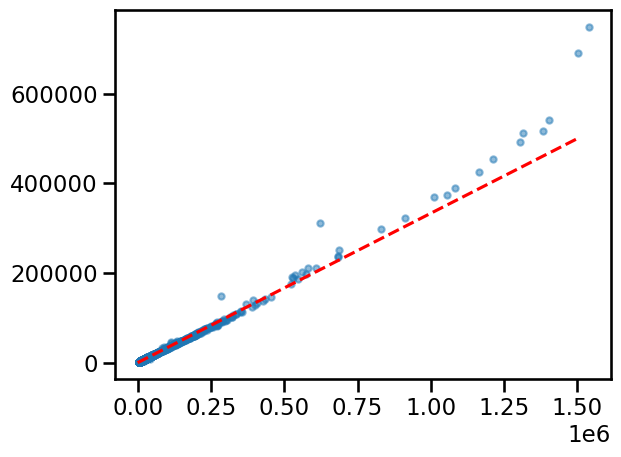

In [27]:
fig, ax = plt.subplots()
ax.scatter(
    "flux_[OIII]_5006.84",
    "flux_[OIII]_4958.91",
    alpha=0.5,
    marker=".",
    data=tab_np_elines_b,
)

ax.plot([0.0, 1.5e6], [0.0, 1.5e6 / 3], color="r", linestyle="dashed")

It looke like it almost is, but falls systematically below the line for most points. This must be some calibration error

Try to explicitly plot ration against log of flux

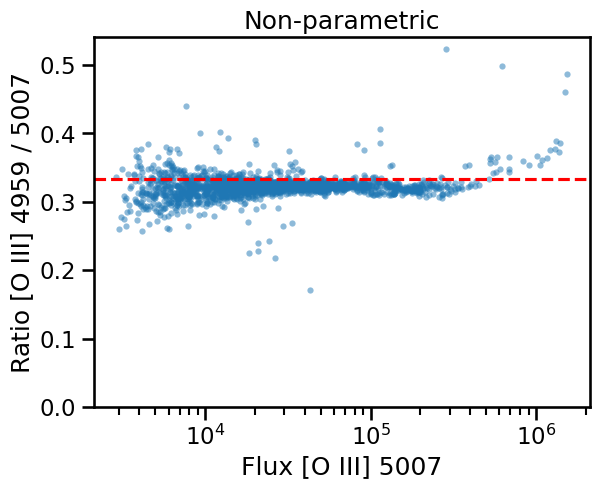

In [28]:
fig, ax = plt.subplots()
x = tab_np_elines_b["flux_[OIII]_5006.84"]
y = tab_np_elines_b["flux_[OIII]_4958.91"] / tab_np_elines_b["flux_[OIII]_5006.84"]
ax.scatter(
    x,
    y,
    alpha=0.5,
    linewidth=0,
    marker=".",
)
ax.set(
    xscale="log",
    ylim=[0, None],
    xlabel="Flux [O III] 5007",
    ylabel="Ratio [O III] 4959 / 5007",
)
ax.set_title("Non-parametric")
ax.axhline(1 / 3, color="r", linestyle="dashed")

In [29]:
f"Ratio 4959/5007 = {np.mean(y):.9f} +/- {np.std(y):.9f}"

'Ratio 4959/5007 = 0.322354436 +/- 0.018045004'

And try also for the parametric values

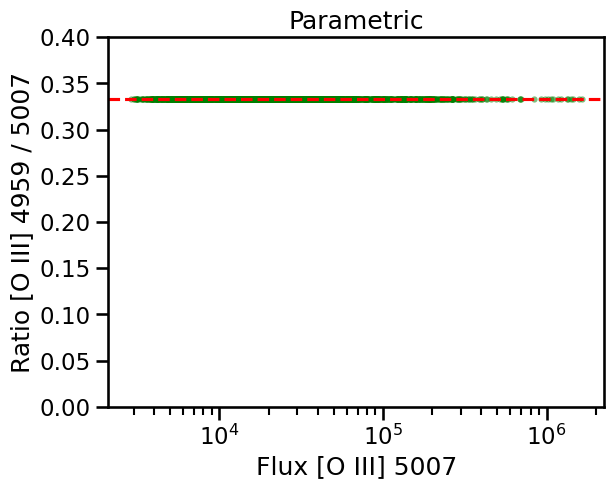

In [30]:
fig, ax = plt.subplots()
x = df_pm_elines[("flux", 5006.84)]
y = df_pm_elines[("flux", 4958.91)] / df_pm_elines[("flux", 5006.84)]
ax.scatter(
    x,
    y,
    alpha=0.5,
    linewidth=0,
    marker=".",
    color="g",
)
ax.set(
    xscale="log",
    ylim=[0, 0.4],
    xlabel="Flux [O III] 5007",
    ylabel="Ratio [O III] 4959 / 5007",
)
ax.set_title("Parametric")
ax.axhline(1 / 3, color="r", linestyle="dashed")
...;

Hmm, that is a perfect result – very suspicious! Presumably, the fitting procedure ties together the ratio of these two lines.

In [31]:
f"Ratio 4959/5007 = {np.mean(y):.9f} +/- {np.std(y):.9f}"

'Ratio 4959/5007 = 0.333000000 +/- 0.000000003'

### [O III] doublet velocities

First the non-parametric

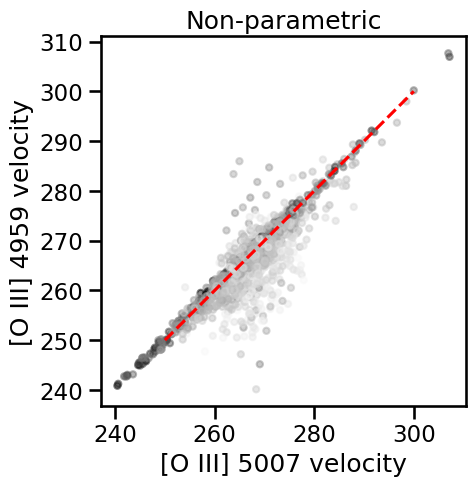

In [32]:
fig, ax = plt.subplots()
ax.scatter(
    "vel_[OIII]_5006.84",
    "vel_[OIII]_4958.91",
    alpha=0.5,
    marker=".",
    c=np.log10(tab_np_elines_b["flux_[OIII]_5006.84"]),
    data=tab_np_elines_b,
    cmap="gray_r",
)
ax.plot([250, 300], [250, 300], color="r", linestyle="dashed")
ax.set(
    xlabel="[O III] 5007 velocity",
    ylabel="[O III] 4959 velocity",
)
ax.set_title("Non-parametric")
ax.set_aspect("equal")

In [33]:
dvel = tab_np_elines_b["vel_[OIII]_4958.91"] - tab_np_elines_b["vel_[OIII]_5006.84"]
f"d Vel 4959 - 5007 = {np.mean(dvel):.9f} +/- {np.std(dvel):.9f}"

'd Vel 4959 - 5007 = -1.433174453 +/- 3.604919925'

Then the parametric

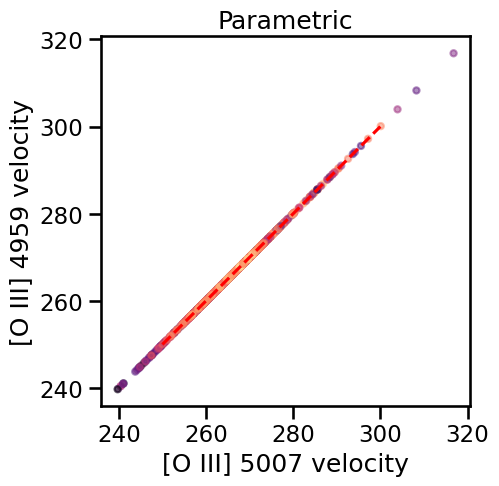

In [34]:
fig, ax = plt.subplots()
x = df_pm_elines[("vel", 5006.84)]
y = df_pm_elines[("vel", 4958.91)]
z = np.log10(df_pm_elines[("flux", 5006.84)])

ax.scatter(
    x,
    y,
    alpha=0.5,
    marker=".",
    c=z,
    cmap="magma_r",
)
ax.plot([250, 300], [250, 300], color="r", linestyle="dashed")
ax.set(
    xlabel="[O III] 5007 velocity",
    ylabel="[O III] 4959 velocity",
)
ax.set_title("Parametric")
ax.set_aspect("equal")

In [35]:
dvel = y - x
f"d Vel 4959 - 5007 = {np.mean(dvel):.9f} +/- {np.std(dvel):.9f}"

'd Vel 4959 - 5007 = 0.000000000 +/- 0.000000000'

Again, a perfect correlation, so the parameters must be tied.

Now try the parametric versus non-parametric:

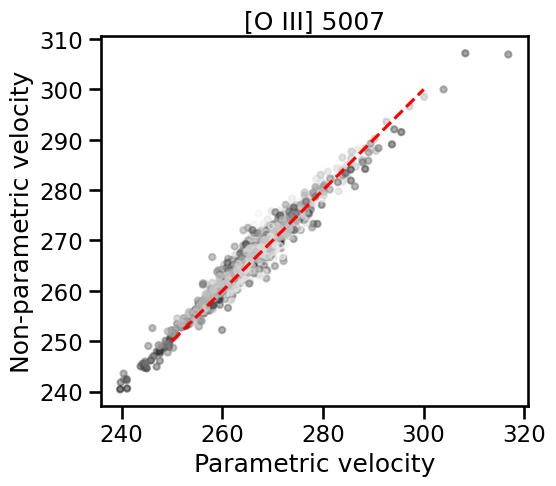

In [36]:
fig, ax = plt.subplots()
x = df_pm_elines[("vel", 5006.84)]
y = tab_np_elines_b["vel_[OIII]_5006.84"]
z = np.log10(df_pm_elines[("flux", 5006.84)])

ax.scatter(
    x,
    y,
    alpha=0.5,
    marker=".",
    c=z,
    cmap="gray_r",
)
ax.plot([250, 300], [250, 300], color="r", linestyle="dashed")
ax.set(
    xlabel="Parametric velocity",
    ylabel="Non-parametric velocity",
)
ax.set_title("[O III] 5007")
ax.set_aspect("equal")

### Other non-parametric lines with seaborn pairplot()

#### H Balmer lines in the blue range

In [37]:
hi_vel_cols_b = [
    _
    for _ in tab_np_elines_b.colnames
    if _.startswith("vel_H") and not _.startswith("vel_HeI")
]
hi_vel_cols_b

['vel_HI_3686.83',
 'vel_HI_3691.56',
 'vel_HI_3697.15',
 'vel_HI_3703.85',
 'vel_HI_3711.97',
 'vel_HI_3734.37',
 'vel_HI_3750.15',
 'vel_HI_3770.63',
 'vel_HI_3797.9',
 'vel_HI_3835.38',
 'vel_HI_3889.05',
 'vel_Hepsilon_3970.07',
 'vel_Hdelta_4101.77',
 'vel_Hgamma_4340.49',
 'vel_Hbeta_4861.36']

In [38]:
vmin, vmax = 225, 305

In [39]:
def draw_line(x, y, **kws):
    ax = plt.gca()
    ax.plot([vmin, vmax], [vmin, vmax], color="k", linestyle="dotted")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

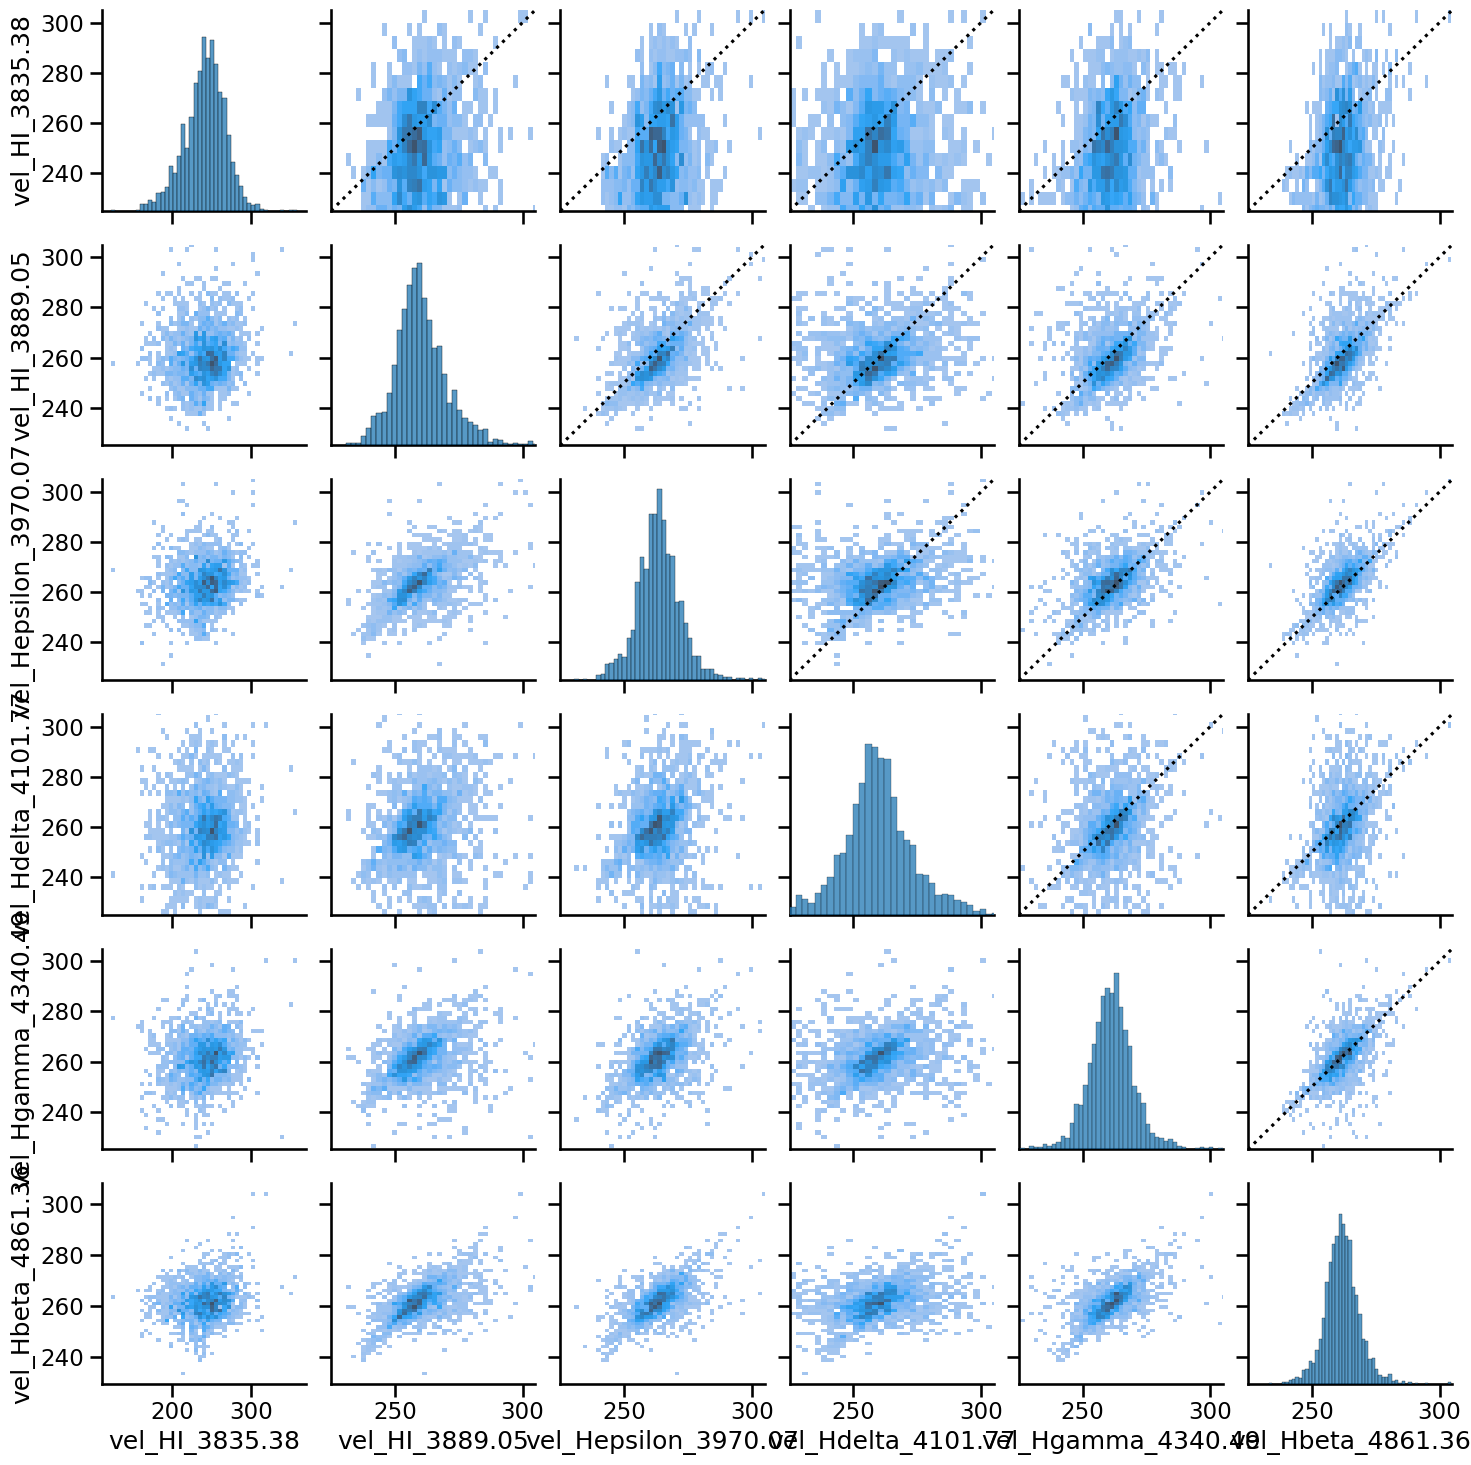

In [40]:
sns.pairplot(
    tab_np_elines_b.to_pandas(), vars=hi_vel_cols_b[-6:], kind="hist"
).map_upper(draw_line)

In [41]:
hi_vel_cols_i = [
    _
    for _ in tab_np_elines_i.colnames
    if _.startswith("vel_H") and not _.startswith("vel_HeI")
]
hi_vel_cols_i

['vel_HI_8239.24',
 'vel_HI_8240.82',
 'vel_HI_8242.51',
 'vel_HI_8244.32',
 'vel_HI_8246.27',
 'vel_HI_8248.35',
 'vel_HI_8250.6',
 'vel_HI_8253.03',
 'vel_HI_8255.65',
 'vel_HI_8258.49',
 'vel_HI_8261.57',
 'vel_HI_8264.92',
 'vel_HI_8268.57',
 'vel_HI_8272.56',
 'vel_HI_8276.94',
 'vel_HI_8281.75',
 'vel_HI_8287.06',
 'vel_HI_8292.94',
 'vel_HI_8299.47',
 'vel_HI_8306.75',
 'vel_HI_8314.89',
 'vel_HI_8324.06',
 'vel_HI_8334.42',
 'vel_HI_8345.55',
 'vel_HI_8359.0',
 'vel_HI_8374.48',
 'vel_HI_8392.4',
 'vel_HI_8467.25',
 'vel_HI_8502.48',
 'vel_HI_8545.38',
 'vel_HI_8598.39',
 'vel_HI_8665.02',
 'vel_HI_8750.47',
 'vel_HI_8862.78',
 'vel_HI_9014.91',
 'vel_HI_9229.02',
 'vel_HI_9545.97']

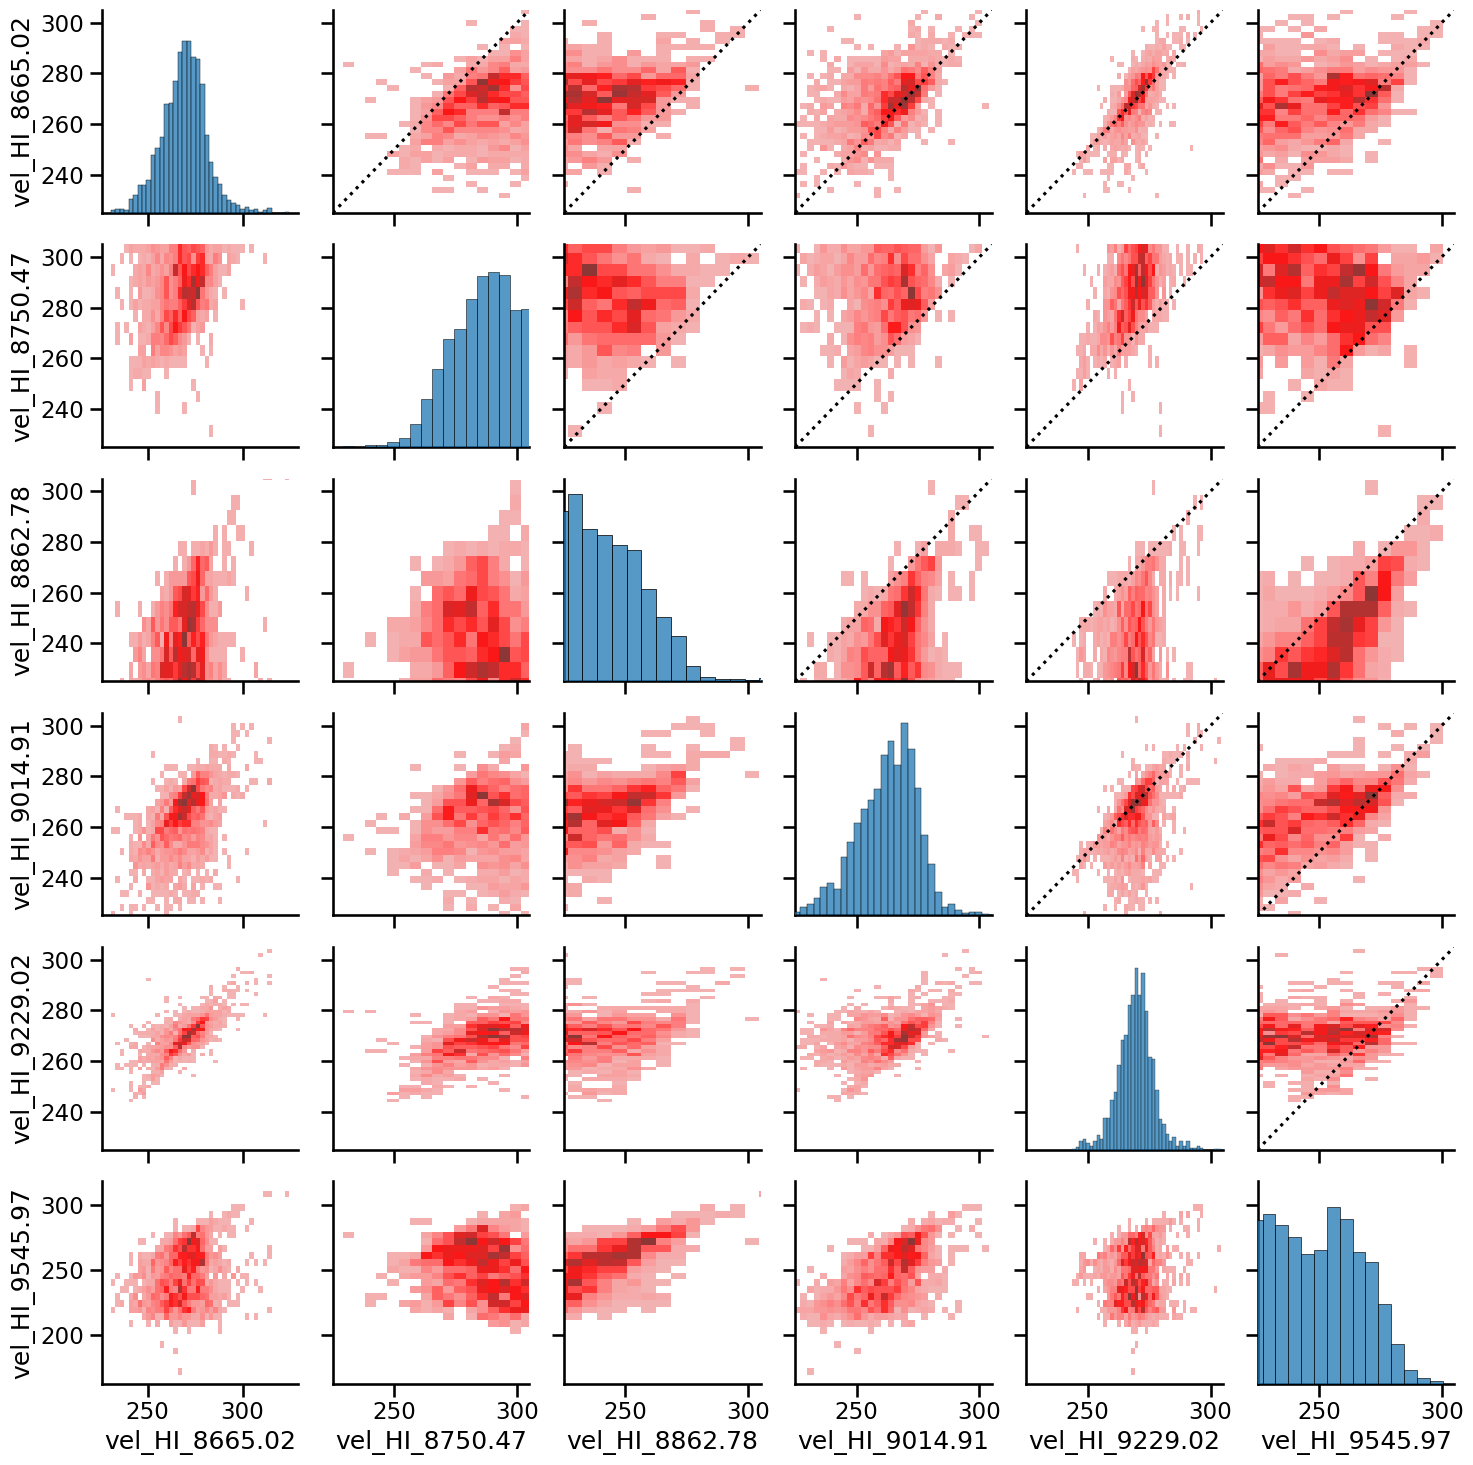

In [42]:
sns.pairplot(
    tab_np_elines_i.to_pandas(),
    vars=hi_vel_cols_i[-6:],
    kind="hist",
    plot_kws=dict(color="r"),
    #    plot_kws=dict(alpha=0.1),
    #    hue="disp_HI_9545.97",
).map_upper(draw_line)

In [43]:
hi_vel_cols_r = [
    _
    for _ in tab_np_elines_r.colnames
    if _.startswith("vel_H")
    # and not _.startswith("vel_HeI")
]
hi_vel_cols_r

['vel_HeI_5876.0',
 'vel_Halpha_6562.85',
 'vel_HeI_6678.15',
 'vel_HeI_7065.19',
 'vel_HeI_7281.35']

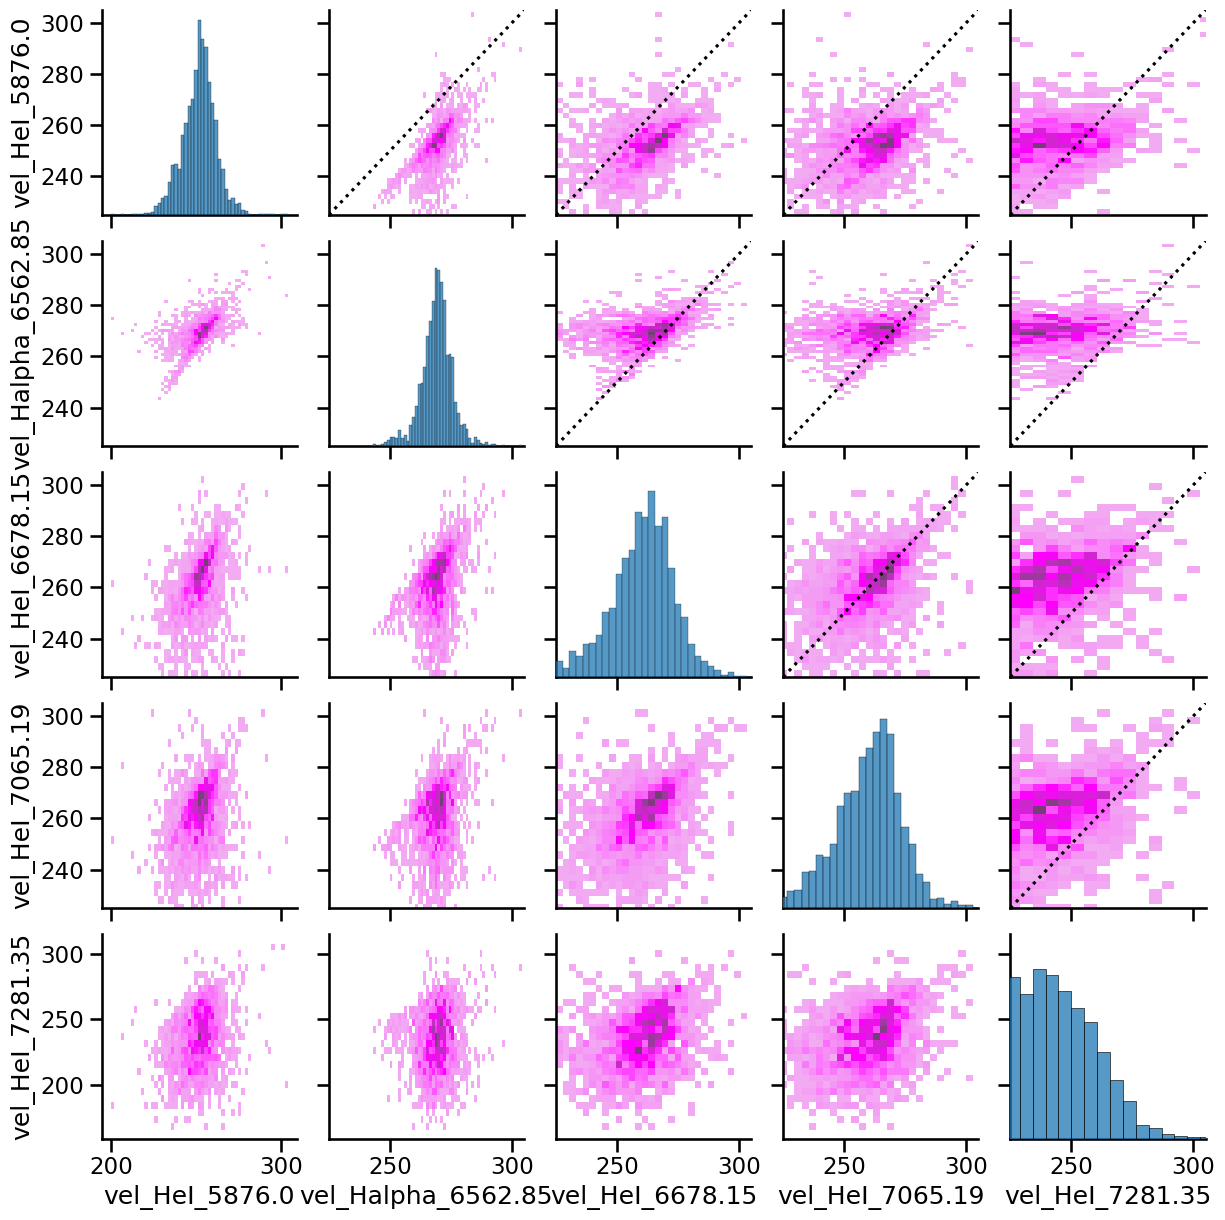

In [44]:
sns.pairplot(
    tab_np_elines_r.to_pandas(),
    vars=hi_vel_cols_r,
    kind="hist",
    plot_kws=dict(color="m"),
    #    plot_kws=dict(alpha=0.1),
    #    hue="disp_HI_9545.97",
).map_upper(draw_line)

In [45]:
x_iii_vel_cols_b = [
    _
    for _ in tab_np_elines_b.colnames
    if _.startswith("vel_") and "III" in _ and not "Fe" in _
]
x_iii_vel_cols_b

['vel_[NeIII]_3868.75',
 'vel_[NeIII]_3967.46',
 'vel_[OIII]_4363.21',
 'vel_[OIII]_4958.91',
 'vel_[OIII]_5006.84',
 'vel_[ArIII]_5191.82',
 'vel_[ClIII]_5517.71']

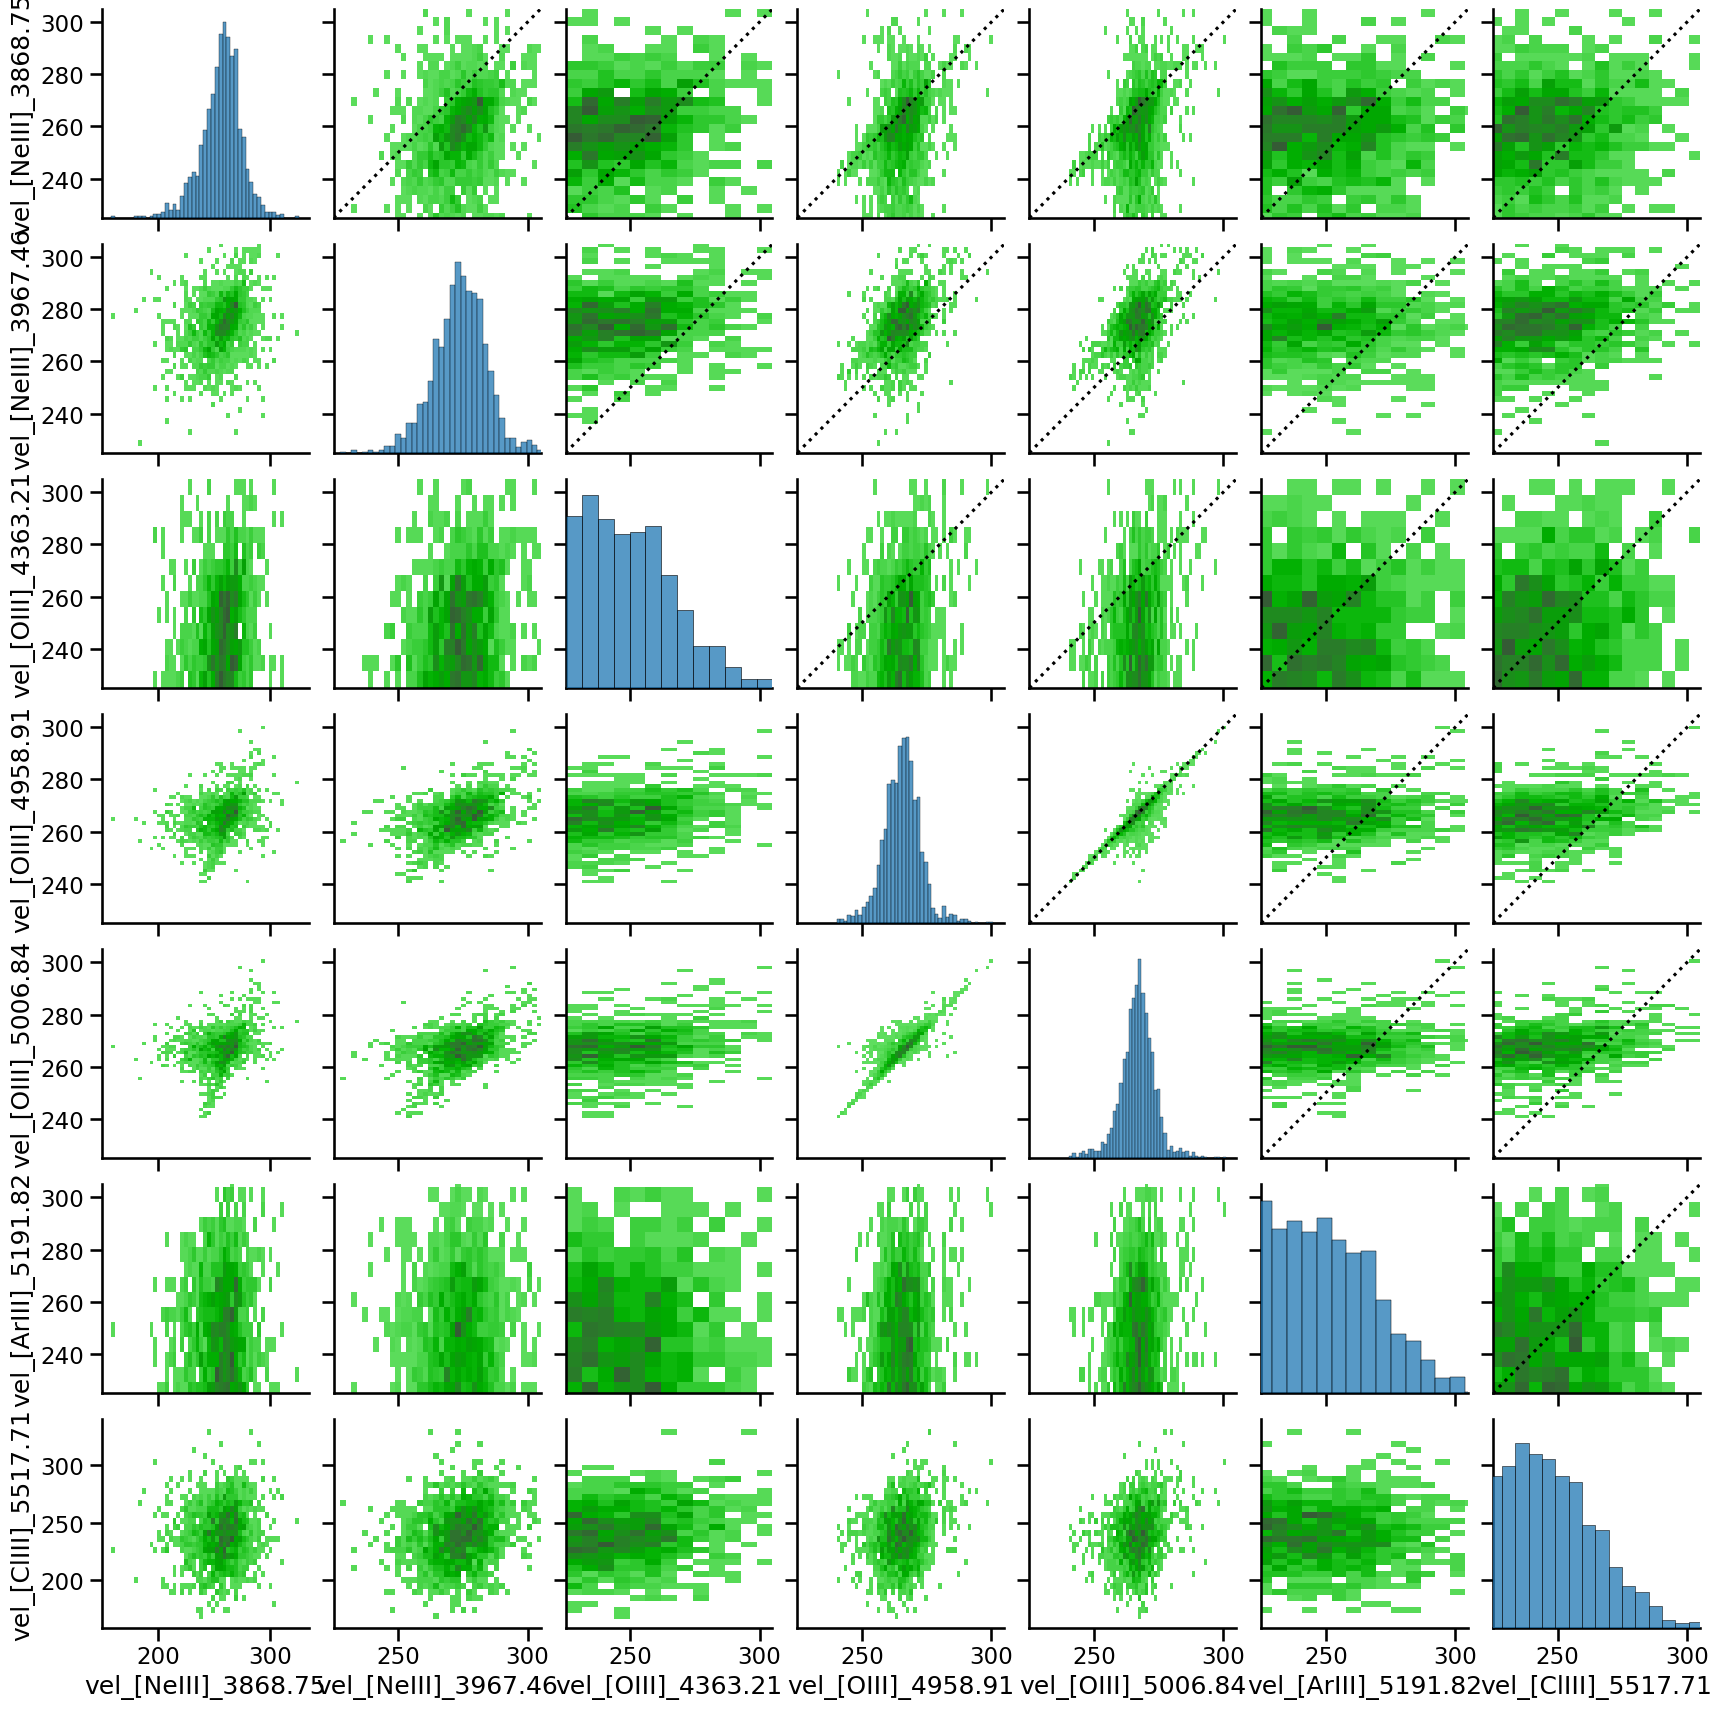

In [46]:
sns.pairplot(
    tab_np_elines_b.to_pandas(),
    vars=x_iii_vel_cols_b,
    kind="hist",
    plot_kws=dict(color="g"),
).map_upper(draw_line)

In [47]:
x_iv_vel_cols_b = [
    _
    for _ in tab_np_elines_b.colnames
    if _.startswith("vel_") and ("IV" in _ or "HeII" in _)
]
x_iv_vel_cols_b

['vel_HeII_4685.68',
 'vel_[ArIV]_4711.33',
 'vel_[NeIV]_4724.17',
 'vel_[ArIV]_4740.2',
 'vel_[FeXIV]_5302.86',
 'vel_HeII_5411.52']

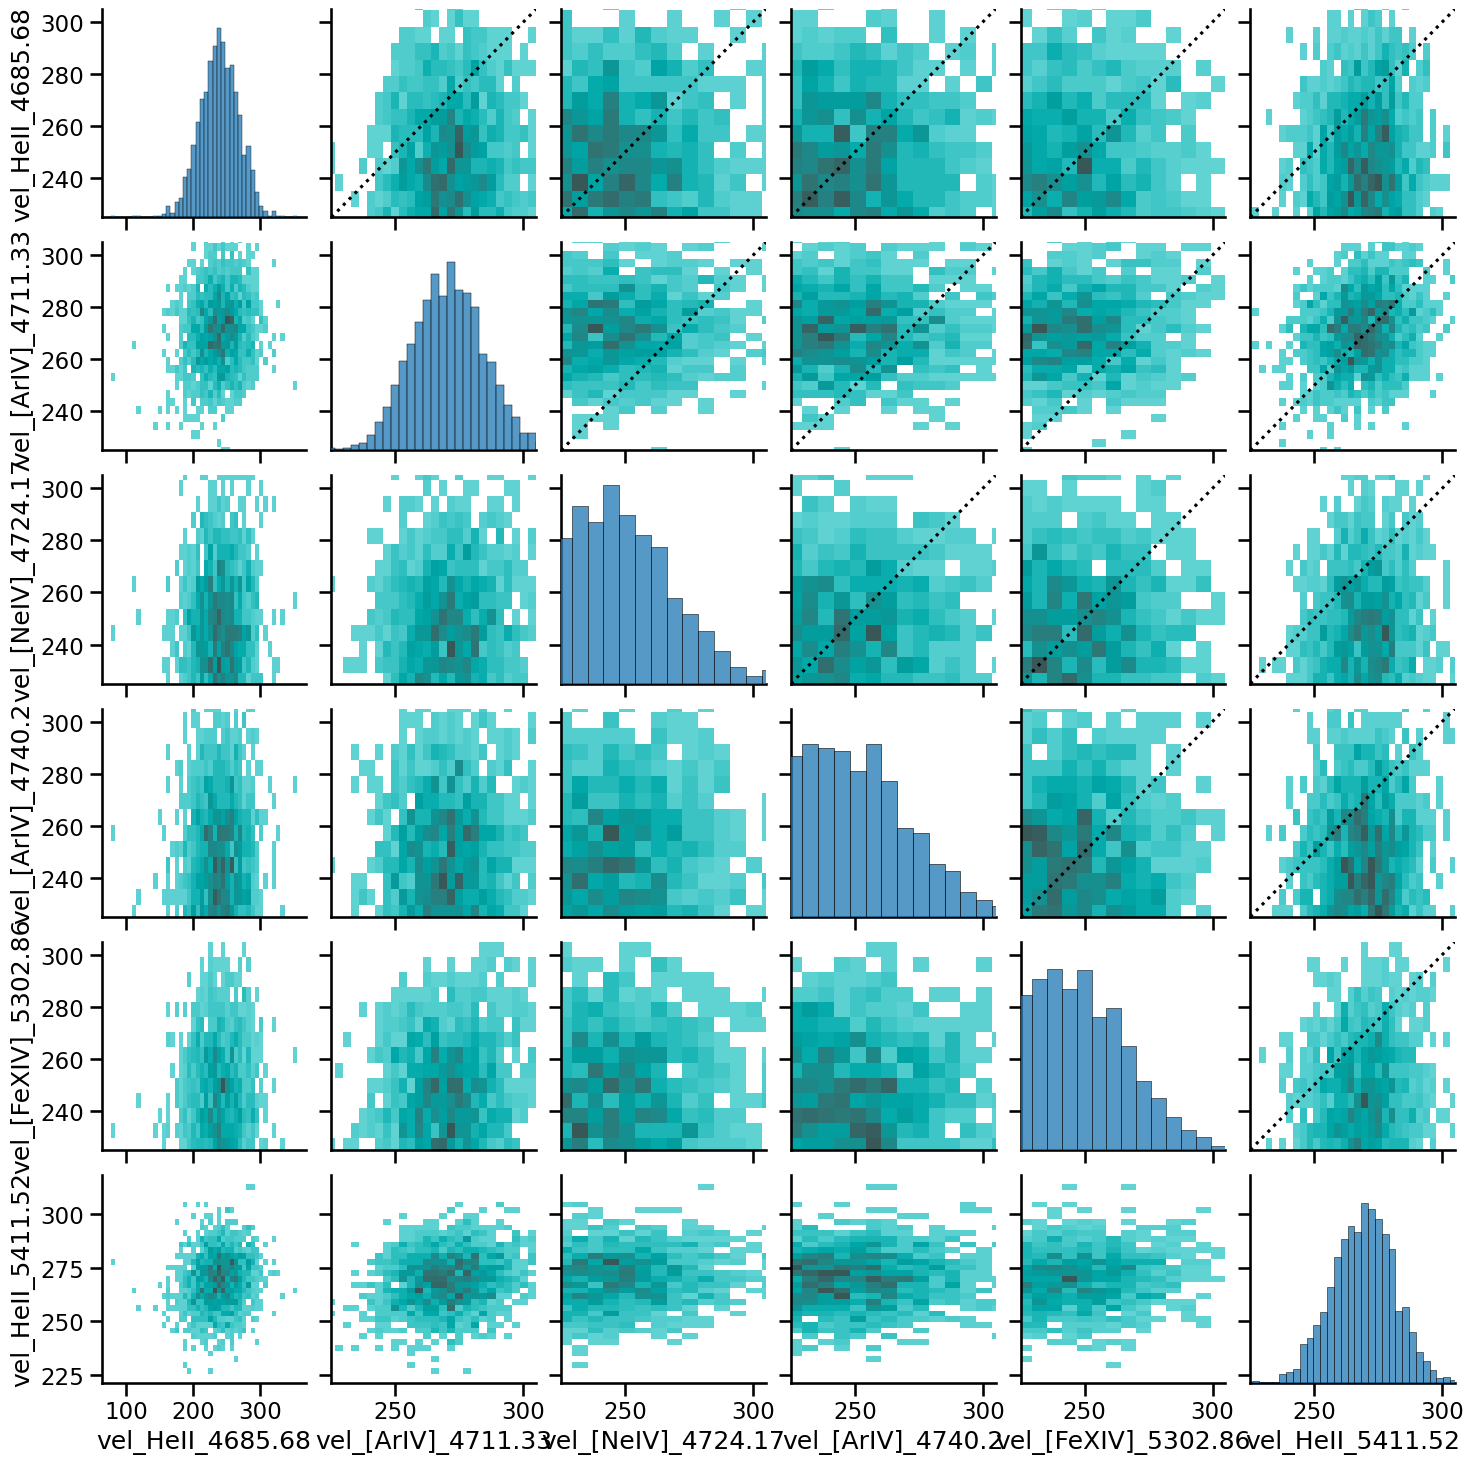

In [48]:
sns.pairplot(
    tab_np_elines_b.to_pandas(),
    vars=x_iv_vel_cols_b,
    kind="hist",
    plot_kws=dict(color="c"),
).map_upper(draw_line)

In [49]:
x_iii_vel_cols_r = [
    _
    for _ in tab_np_elines_r.colnames
    if _.startswith("vel_") and ("III" in _ or "IV" in _)
]
x_iii_vel_cols_r

['vel_[SIII]_6312.06', 'vel_[ArIII]_7135.8']

In [50]:
x_iii_vel_cols_i = [
    _
    for _ in tab_np_elines_i.colnames
    if _.startswith("vel_") and ("III" in _ or "IV" in _)
]
x_iii_vel_cols_i

['vel_[ArIII]_7751.06', 'vel_[SIII]_9069.0', 'vel_[SIII]_9531.1']

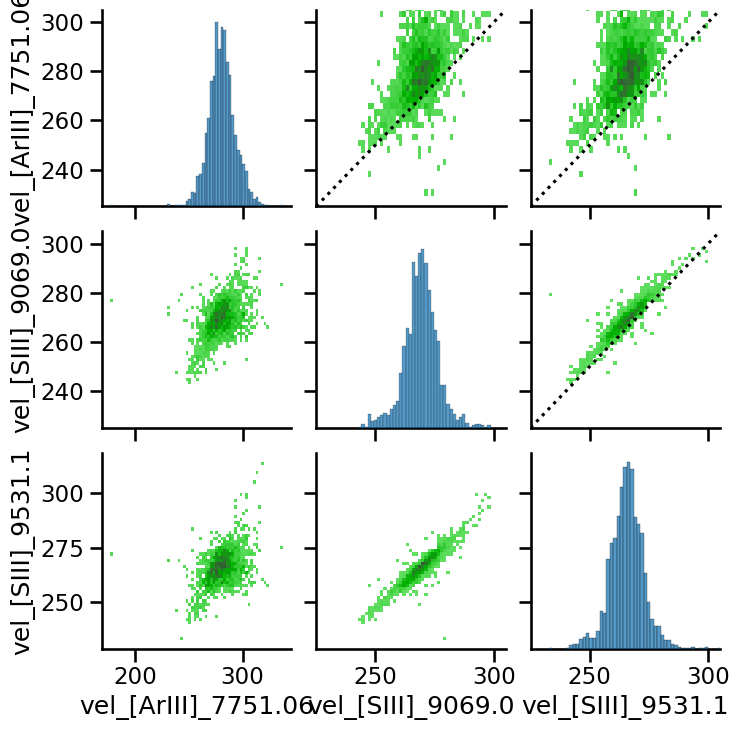

In [51]:
sns.pairplot(
    tab_np_elines_i.to_pandas(),
    vars=x_iii_vel_cols_i,
    kind="hist",
    plot_kws=dict(color="g"),
).map_upper(draw_line)

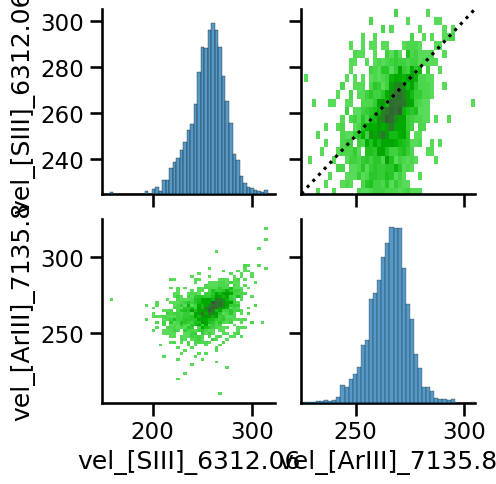

In [52]:
sns.pairplot(
    tab_np_elines_r.to_pandas(),
    vars=x_iii_vel_cols_r,
    kind="hist",
    plot_kws=dict(color="g"),
).map_upper(draw_line)

In [53]:
x_ii_vel_cols_r = [
    _
    for _ in tab_np_elines_r.colnames
    if _.startswith("vel_")
    and (
        "II" in _
        and not "III" in _
        and not "H" in _
        and not "Fe" in _
        and not "Ni" in _
        and not "Ca" in _
    )
]
x_ii_vel_cols_r

['vel_[NII]_6548.05',
 'vel_[NII]_6583.45',
 'vel_[SII]_6716.44',
 'vel_[SII]_6730.82',
 'vel_CII_7236.0',
 'vel_[OII]_7318.92',
 'vel_[OII]_7329.66']

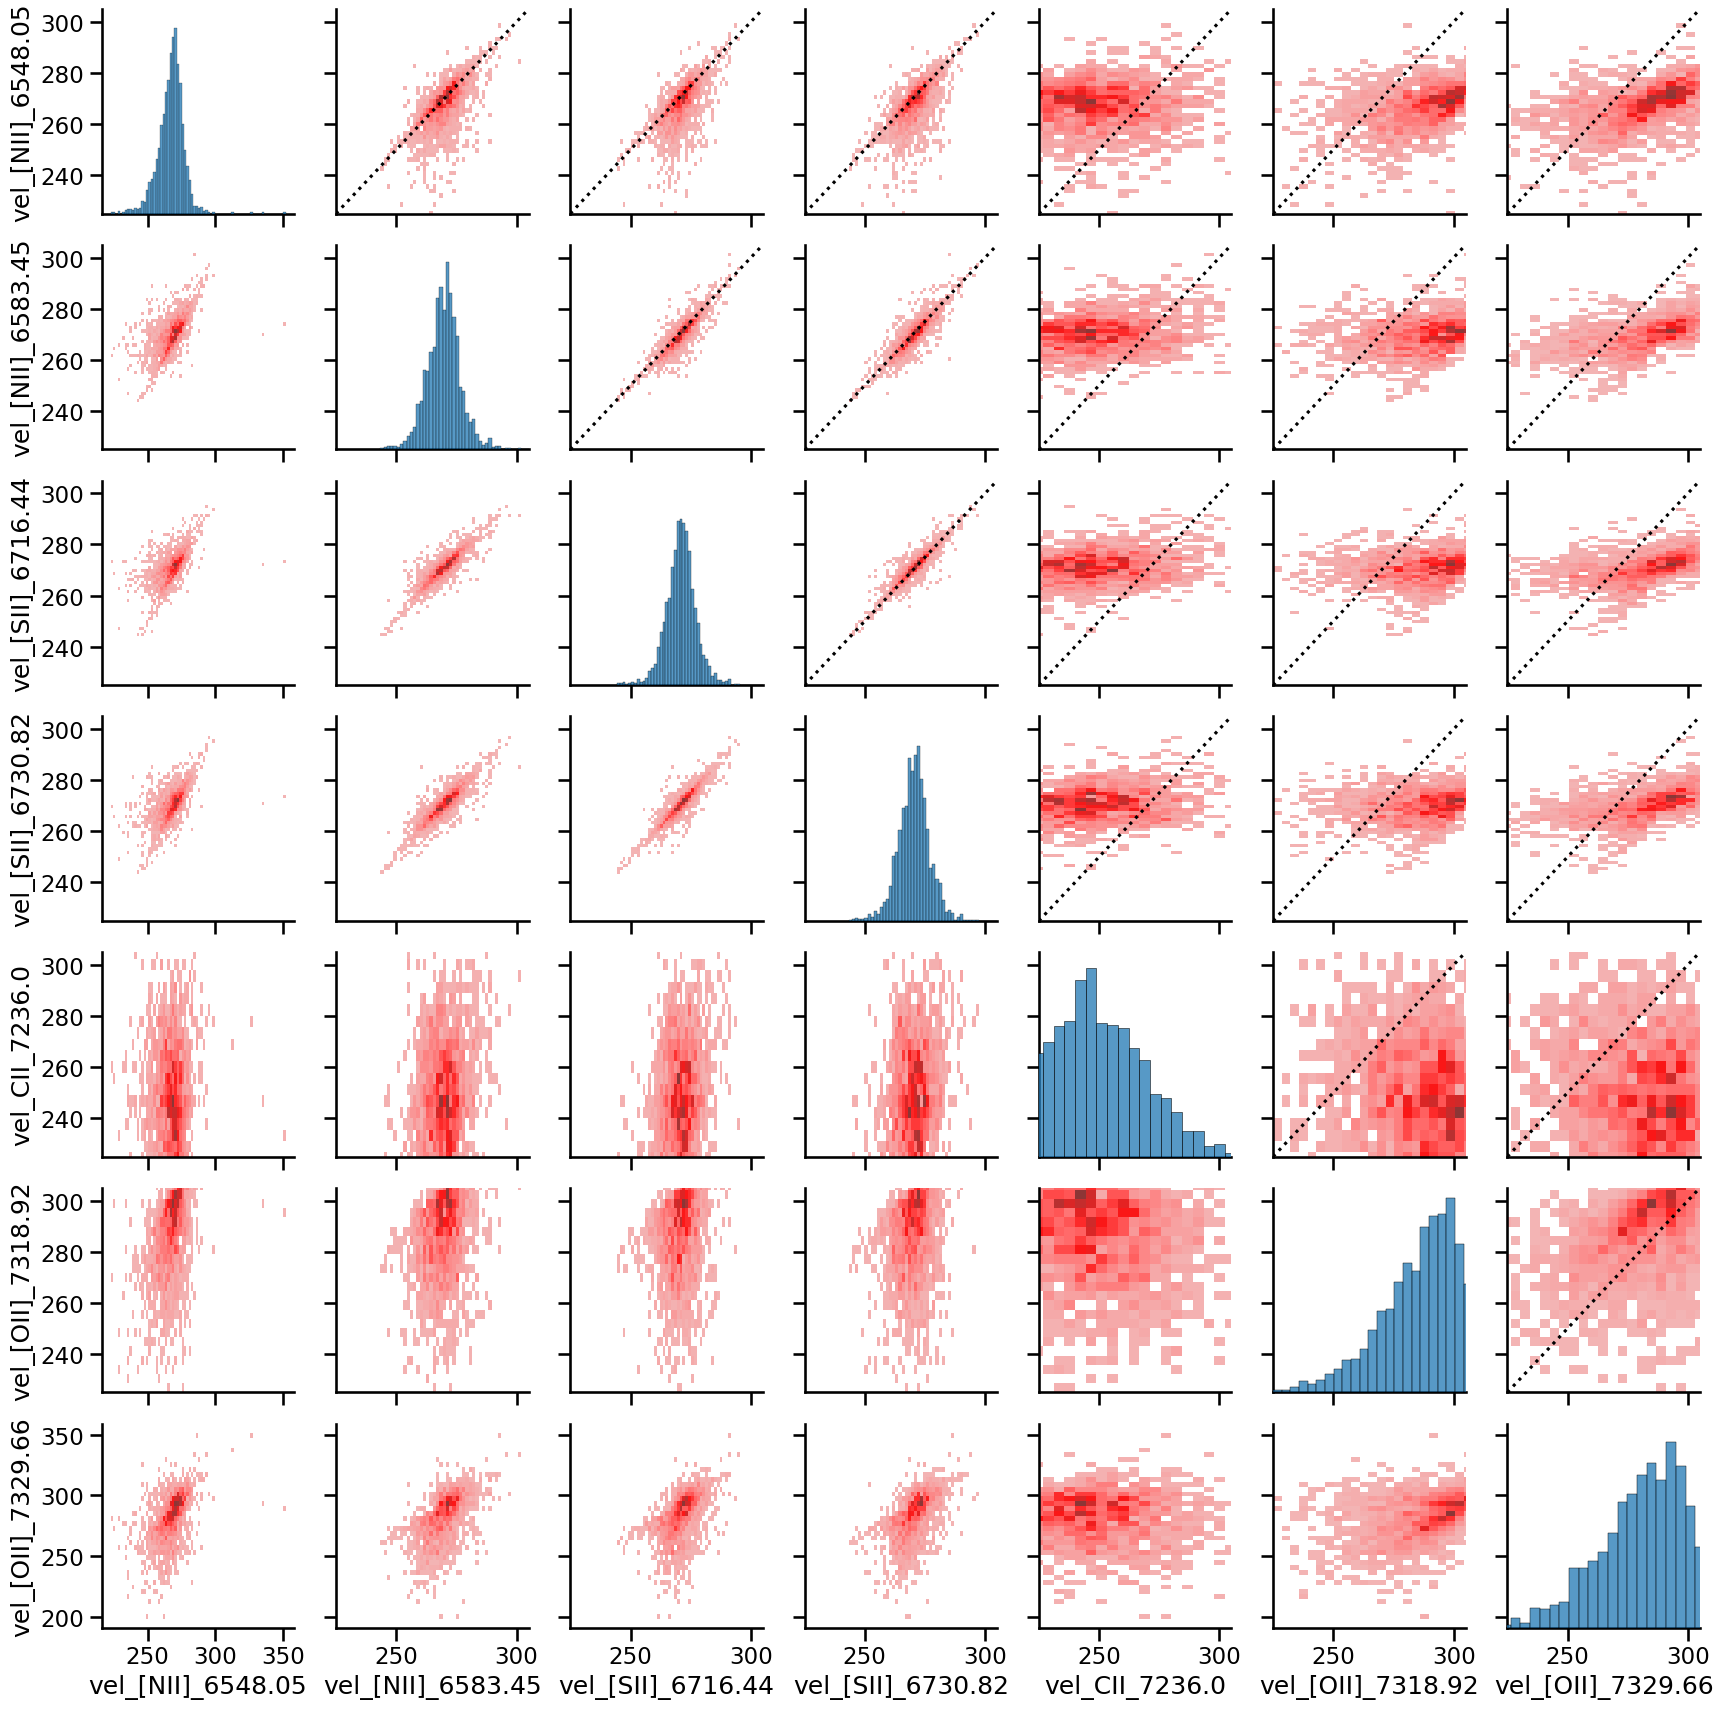

In [54]:
sns.pairplot(
    tab_np_elines_r.to_pandas(),
    vars=x_ii_vel_cols_r,
    kind="hist",
    plot_kws=dict(color="r"),
).map_upper(draw_line)

In [55]:
sns.PairGrid.map_offdiag

<function seaborn.axisgrid.PairGrid.map_offdiag(self, func, **kwargs)>

In [56]:
tabs = list(
    _.to_pandas().set_index("id")
    for _ in [tab_np_elines_b, tab_np_elines_r, tab_np_elines_i]
)
df_np = pd.concat(
    tabs,
    axis=1,
)
df_np.columns

Index(['flux_HI_3686.83', 'flux_HI_3691.56', 'flux_HI_3697.15',
       'flux_HI_3703.85', 'flux_HI_3711.97', 'flux_[OII]_3726.03',
       'flux_[OII]_3728.82', 'flux_HI_3734.37', 'flux_HI_3750.15',
       'flux_[FeVII]_3758.9',
       ...
       'e_EW_[ClII]_9123.6', 'e_EW_[FeII]_9226.6', 'e_EW_HI_9229.02',
       'e_EW_OI_9266.0', 'e_EW_[FeII]_9267.54', 'e_EW_[FeII]_9399.02',
       'e_EW_[FeII]_9470.93', 'e_EW_[SIII]_9531.1', 'e_EW_HI_9545.97',
       'e_EW_[FeII]_9682.13'],
      dtype='str', length=1720)

#### Choose some sets of lines

These are ones to look at to see if there are general problems between blue and red, which Eduardo had pointed out with the Orion maps

In [57]:
np_select = [
    "vel_[OII]_3726.03",
    "vel_Hgamma_4340.49",
    "vel_Halpha_6562.85",
    "vel_[SII]_6716.44",
    "vel_HI_9229.02",
]

And these are to see if we have any data on the more interesting lines

In [58]:
np_high = [
    "vel_[ArIV]_4740.2",
    "vel_[NeIII]_3868.75",
    "vel_[NeIII]_3967.46",
]
np_low = [
    "vel_[NI]_5197.9",
    "vel_[NI]_5200.26",
    "vel_[OI]_6300.3",
    "vel_[OI]_6363.78",
    "vel_OI_7774.0",
    "vel_OI_8446.0",
    "vel_[CI]_8727.13",
    "vel_OI_9266.0",
]
np_ii = [
    "vel_[OII]_3726.03",
    "vel_[OII]_3728.82",
    "vel_[SII]_4068.6",
    "vel_[SII]_4076.35",
    "vel_[NII]_5754.59",
    "vel_[NII]_6548.05",
    "vel_[NII]_6583.45",
    "vel_[SII]_6716.44",
    "vel_[SII]_6730.82",
    "vel_[OII]_7318.92",
    "vel_[OII]_7329.66",
]
np_iii = [
    _ for _ in df_np.columns if _.startswith("vel") and "III" in _ and not "Fe" in _
]
np_iii

['vel_[NeIII]_3868.75',
 'vel_[NeIII]_3967.46',
 'vel_[OIII]_4363.21',
 'vel_[OIII]_4958.91',
 'vel_[OIII]_5006.84',
 'vel_[ArIII]_5191.82',
 'vel_[ClIII]_5517.71',
 'vel_[SIII]_6312.06',
 'vel_[ArIII]_7135.8',
 'vel_[ArIII]_7751.06',
 'vel_[SIII]_9069.0',
 'vel_[SIII]_9531.1']

In [59]:
[_ for _ in df_np.columns if _.startswith("vel")]

['vel_HI_3686.83',
 'vel_HI_3691.56',
 'vel_HI_3697.15',
 'vel_HI_3703.85',
 'vel_HI_3711.97',
 'vel_[OII]_3726.03',
 'vel_[OII]_3728.82',
 'vel_HI_3734.37',
 'vel_HI_3750.15',
 'vel_[FeVII]_3758.9',
 'vel_HI_3770.63',
 'vel_HI_3797.9',
 'vel_HeI_3819.61',
 'vel_HI_3835.38',
 'vel_[NeIII]_3868.75',
 'vel_HeI_3888.65',
 'vel_HI_3889.05',
 'vel_CaII_3933.66',
 'vel_HeI_3964.73',
 'vel_[NeIII]_3967.46',
 'vel_CaII_3968.47',
 'vel_Hepsilon_3970.07',
 'vel_HeI_4026.19',
 'vel_[SII]_4068.6',
 'vel_[SII]_4076.35',
 'vel_Hdelta_4101.77',
 'vel_HeI_4120.81',
 'vel_[FeII]_4177.21',
 'vel_[FeV]_4227.2',
 'vel_[FeII]_4243.98',
 'vel_CII_4267.0',
 'vel_[FeII]_4287.4',
 'vel_Hgamma_4340.49',
 'vel_[FeII]_4358.1',
 'vel_[FeII]_4358.37',
 'vel_[FeII]_4359.34',
 'vel_[OIII]_4363.21',
 'vel_[FeII]_4413.78',
 'vel_[FeII]_4414.45',
 'vel_[FeII]_4416.27',
 'vel_[FeII]_4452.11',
 'vel_[FeII]_4457.95',
 'vel_[FeII]_4470.29',
 'vel_HeI_4471.48',
 'vel_[FeII]_4474.91',
 'vel_[NiII]_4485.21',
 'vel_[MgI]_4562.4

#### Blue range vs red range

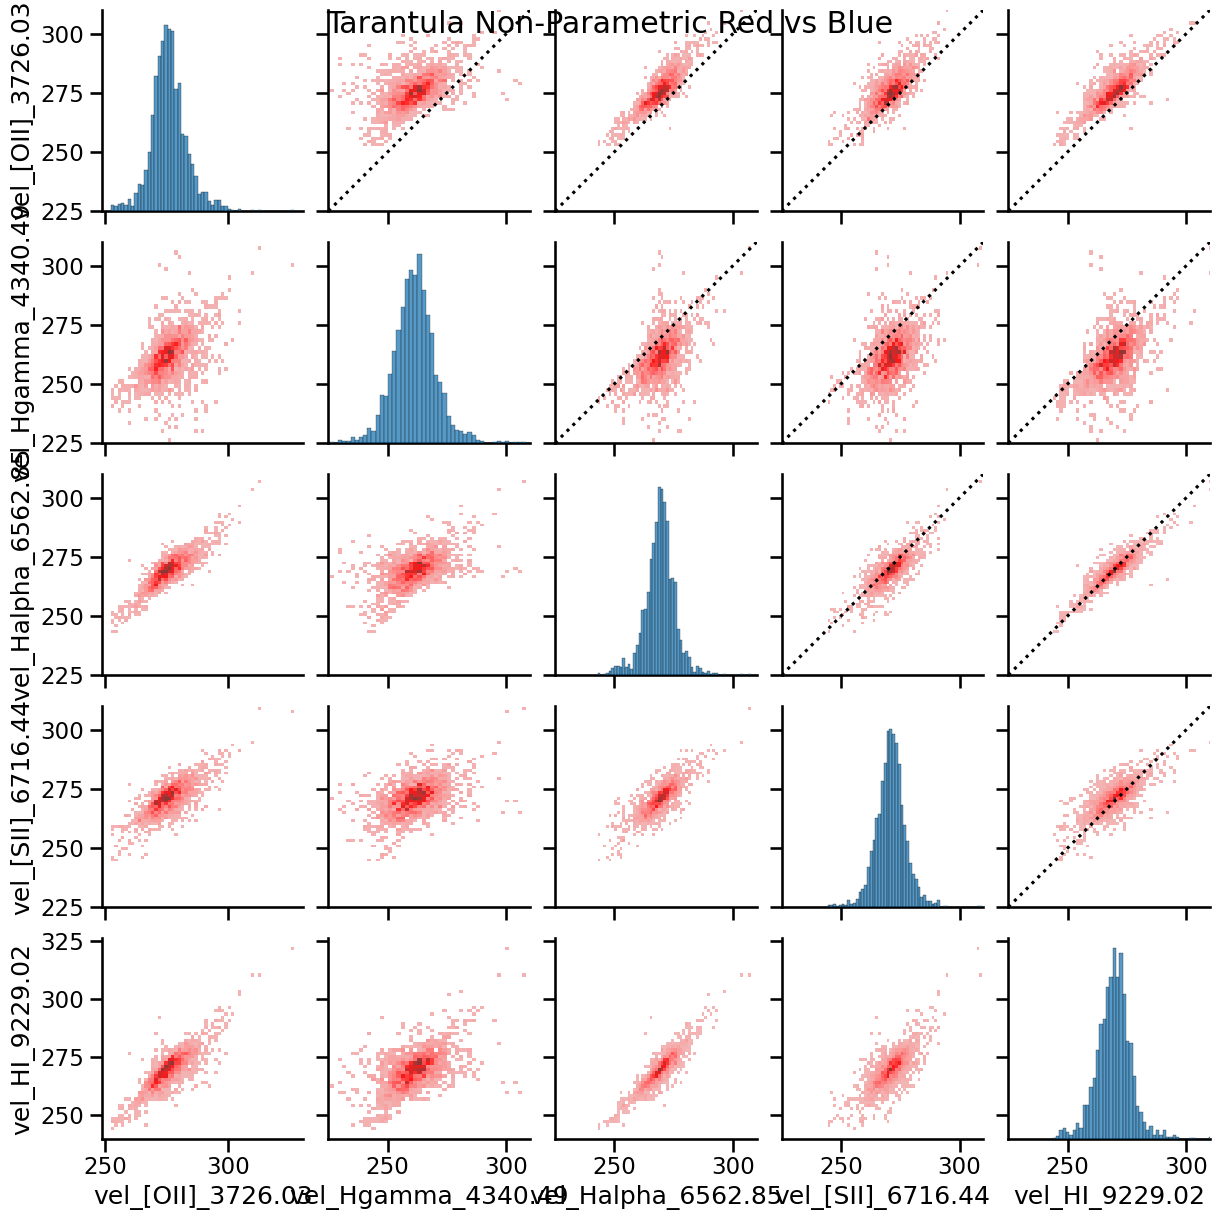

In [60]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    vars=np_select,
    kind="hist",
    plot_kws=dict(color="r"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric Red vs Blue")
g.fig.savefig("tarantula-np-blue-red-vel-correlations.pdf")

#### High-ionization

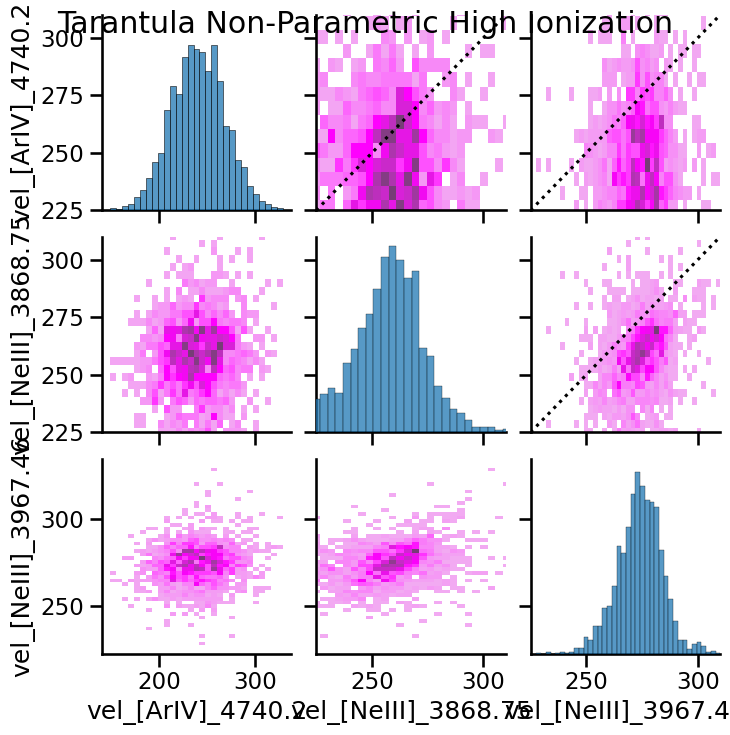

In [61]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    vars=np_high,
    kind="hist",
    plot_kws=dict(color="m"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric High Ionization")
g.fig.savefig("tarantula-np-high-vel-correlations.pdf")

#### Neutral lines

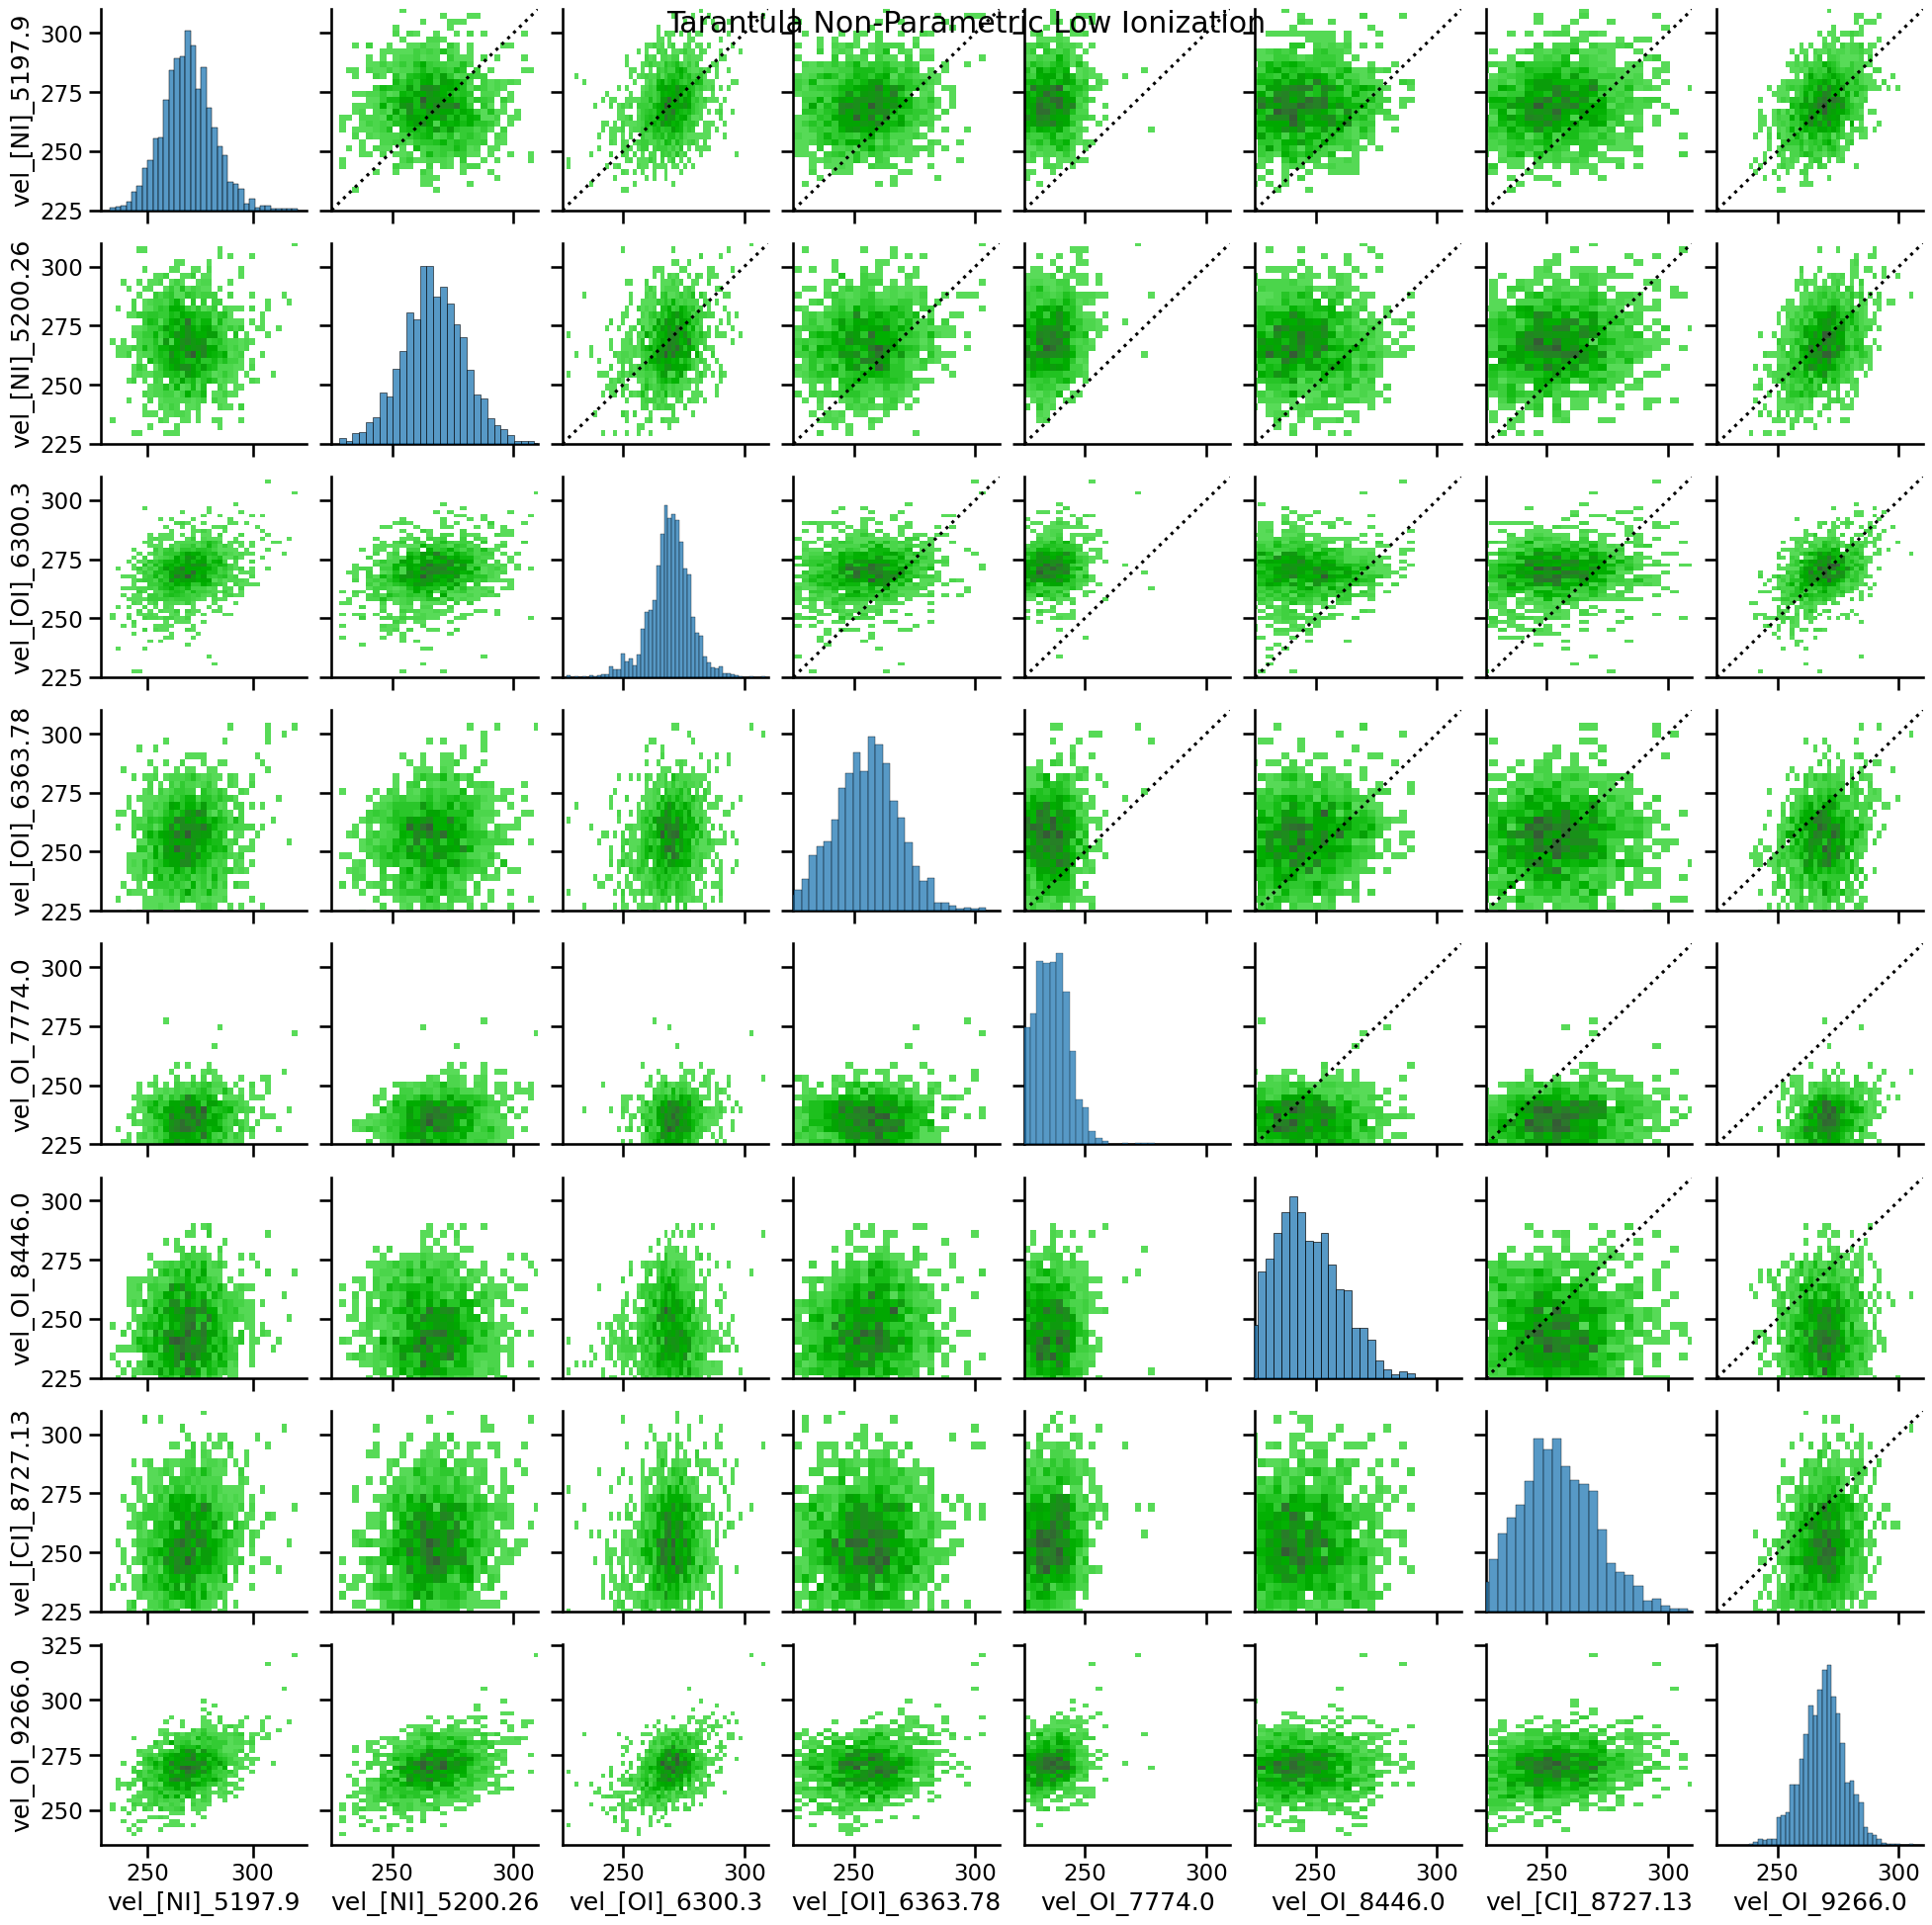

In [62]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    vars=np_low,
    kind="hist",
    plot_kws=dict(color="g"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric Low Ionization")
g.fig.savefig("tarantula-np-low-vel-correlations.pdf")

#### Singly ionized collisional

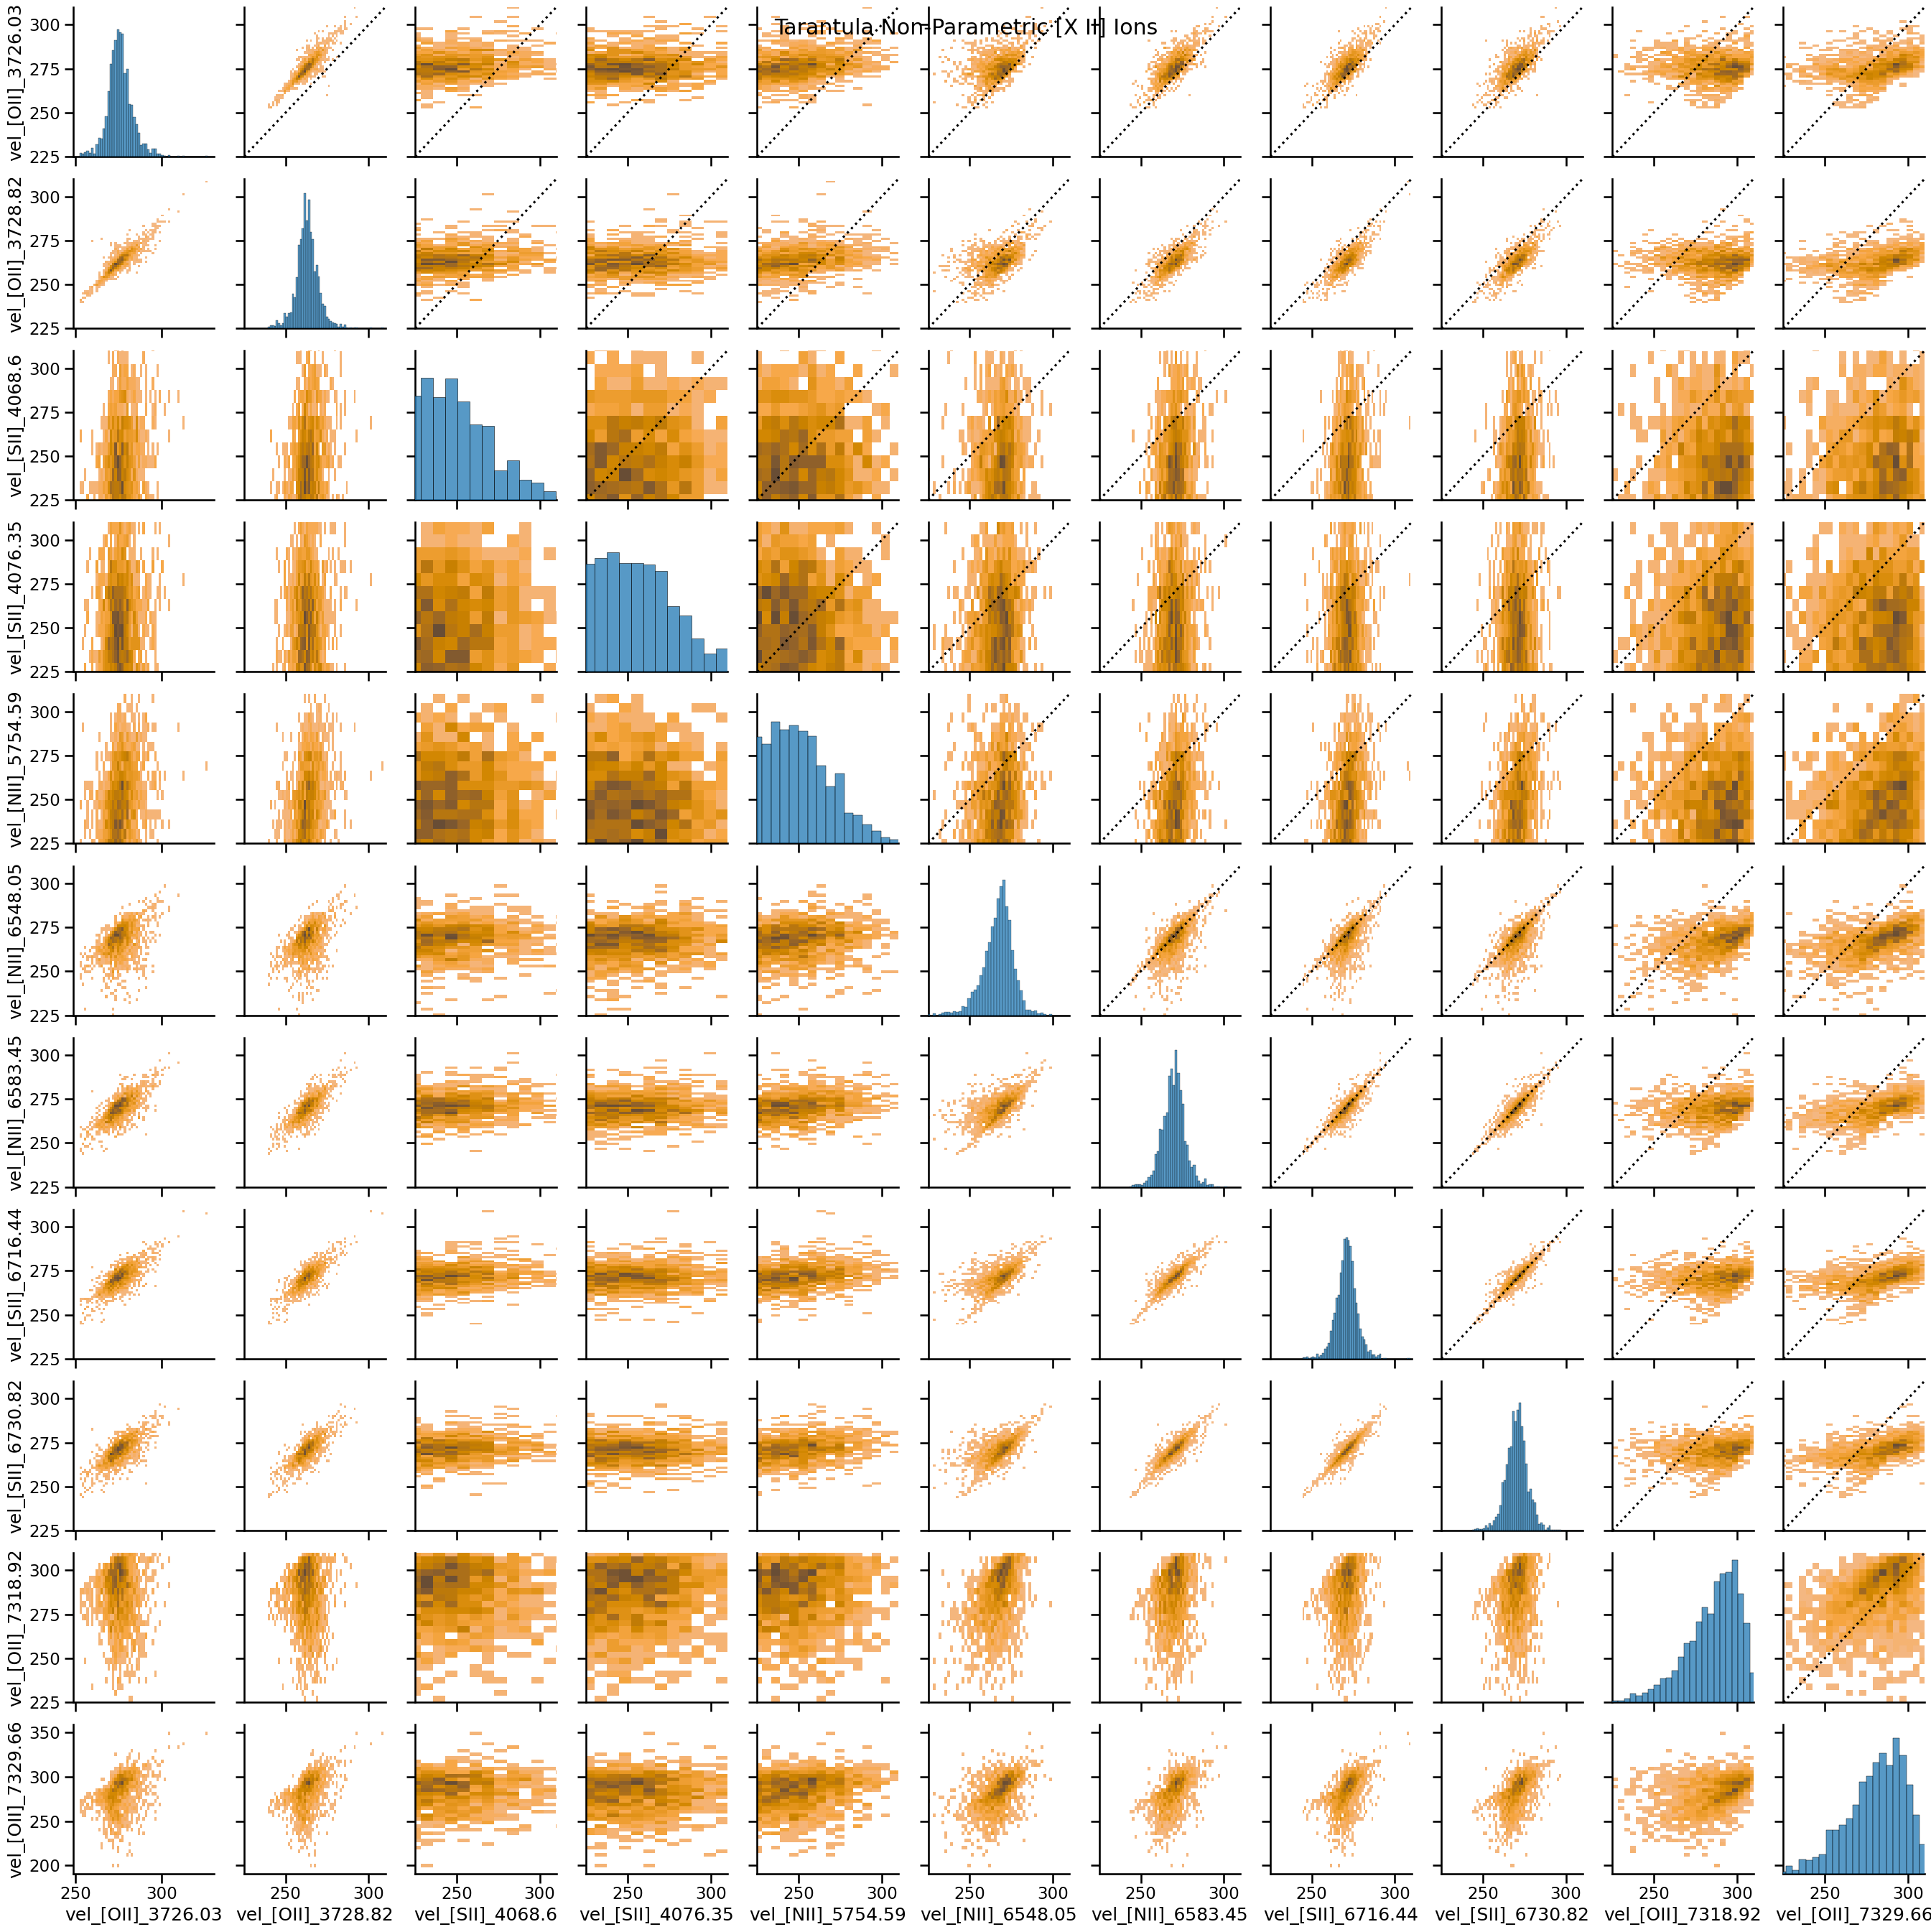

In [63]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    vars=np_ii,
    kind="hist",
    plot_kws=dict(color="orange"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric [X II] Ions")
g.fig.savefig("tarantula-np-ii-vel-correlations.pdf")

This shows that some of the lines are very well correlated

In [64]:
df_np[np_ii].corr()

,vel_[OII]_3726.03,vel_[OII]_3728.82,vel_[SII]_4068.6,vel_[SII]_4076.35,vel_[NII]_5754.59,vel_[NII]_6548.05,vel_[NII]_6583.45,vel_[SII]_6716.44,vel_[SII]_6730.82,vel_[OII]_7318.92,vel_[OII]_7329.66
vel_[OII]_3726.03,1.000000,0.895096,0.234103,0.075754,0.328858,0.426701,0.750004,0.758332,0.732367,0.073547,0.390332
vel_[OII]_3728.82,0.895096,1.000000,0.256299,0.067718,0.329660,0.472853,0.793179,0.809408,0.792141,0.101923,0.427031
vel_[SII]_4068.6,0.234103,0.256299,1.000000,-0.013726,0.129794,0.171089,0.260090,0.259785,0.252855,0.107378,0.200098
vel_[SII]_4076.35,0.075754,0.067718,-0.013726,1.000000,0.004697,0.091035,0.081889,0.081971,0.084779,0.092203,0.045810
vel_[NII]_5754.59,0.328858,0.329660,0.129794,0.004697,1.000000,0.190125,0.314431,0.312995,0.314011,0.102977,0.264791
vel_[NII]_6548.05,0.426701,0.472853,0.171089,0.091035,0.190125,1.000000,0.615844,0.606826,0.600519,0.472504,0.480888
vel_[NII]_6583.45,0.750004,0.793179,0.260090,0.081889,0.314431,0.615844,1.000000,0.877260,0.874742,0.318150,0.545393
vel_[SII]_6716.44,0.758332,0.809408,0.259785,0.081971,0.312995,0.606826,0.877260,1.000000,0.904067,0.269384,0.498386
vel_[SII]_6730.82,0.732367,0.792141,0.252855,0.084779,0.314011,0.600519,0.874742,0.904067,1.000000,0.298085,0.533097
vel_[OII]_7318.92,0.073547,0.101923,0.107378,0.092203,0.102977,0.472504,0.318150,0.269384,0.298085,1.000000,0.423547


So the blue [O II] lines have r=0.92 with each other, but r=0.7 to 0.8 with the red ones. The 3728.82 line is the best, reaching r=0.94 with the [S II] and [N II] lines. However, 3728.82 has a systematic velocity shift of about -5 km/s from the red lines, whereas 3726.03 has no velocity shift.

The auroral [S II] and [N II] lines are noisier, with r=0.5 to 0.7, presumably because they are weaker

The nebular [N II] and [S II] lines are good. Best correlation is r=0.992 between the two [S II] lines. Their correlation with [N II] 6584 is 0.984 and with 6548 is 0.93, similar to correlation between the [N II] lines

**Conclusion:** best lines are
* [O II] 3728.82 but with a -5 velocity offset
* [N II] 6583.45
* [S II] 6716.44
* [S II] 6730.82



In [65]:
np_ii_best = [
    "vel_[OII]_3728.82",
    "vel_[NII]_6583.45",
    "vel_[SII]_6716.44",
    "vel_[SII]_6730.82",
    "vel_[OI]_6300.3",
]

I have added the [O I] 6300 line, which was the only half-way decent low ionization one so we can compare it with these.

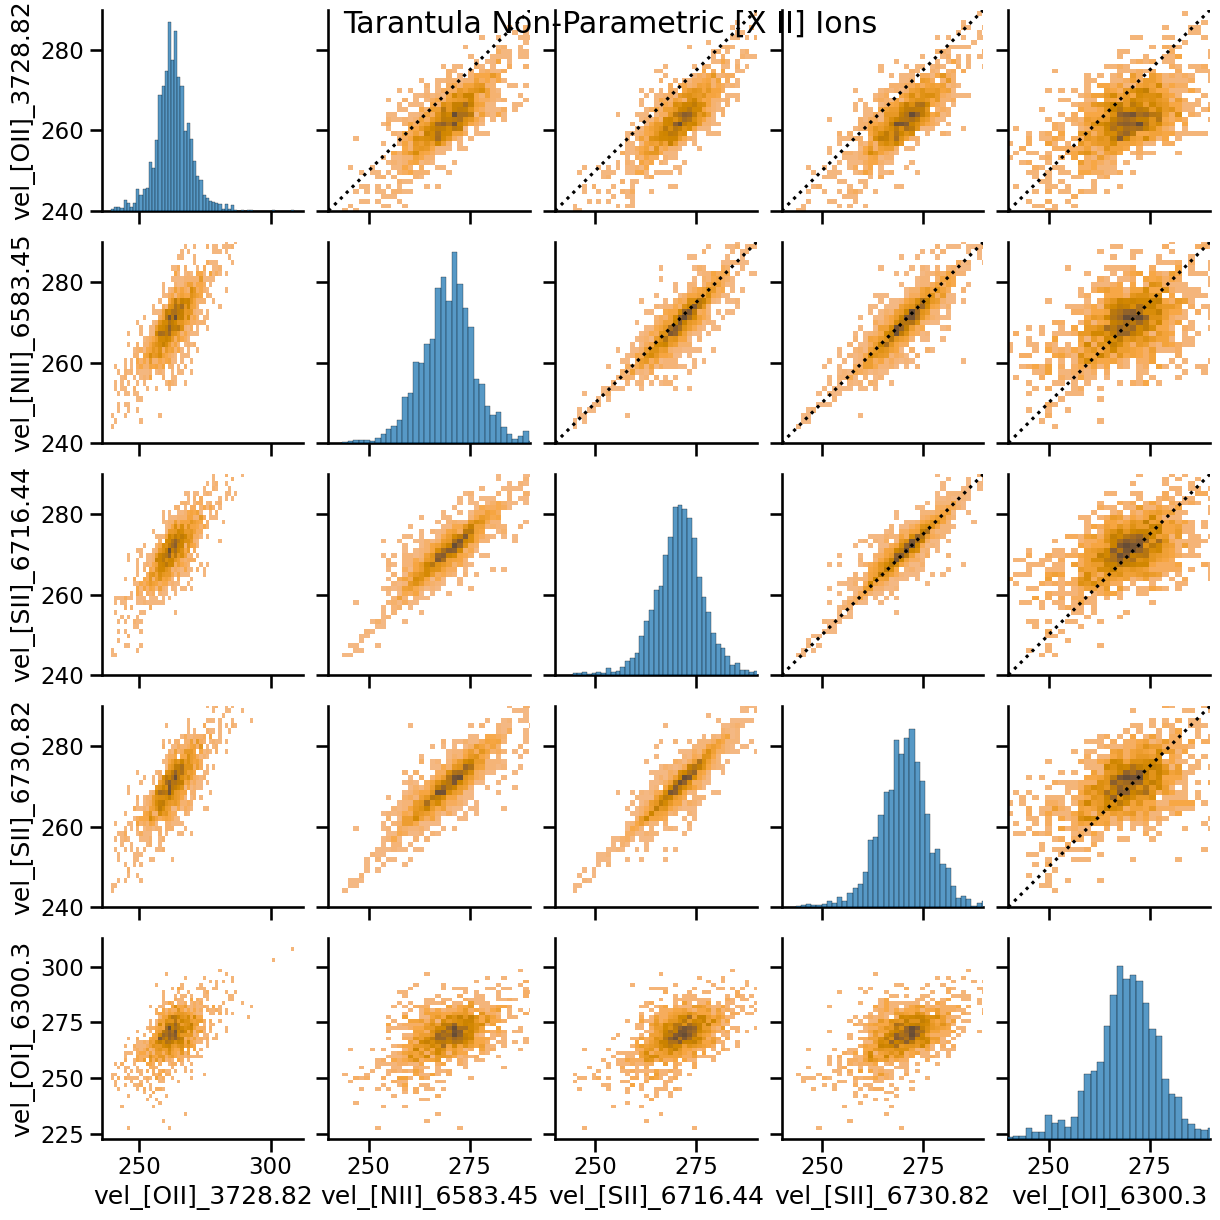

In [66]:
vmin, vmax = 240, 290
g = sns.pairplot(
    df_np,
    vars=np_ii_best,
    kind="hist",
    plot_kws=dict(color="orange"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric [X II] Ions")
g.fig.savefig("tarantula-np-ii-best-vel-correlations.pdf")

#### Doubly ionized collisional

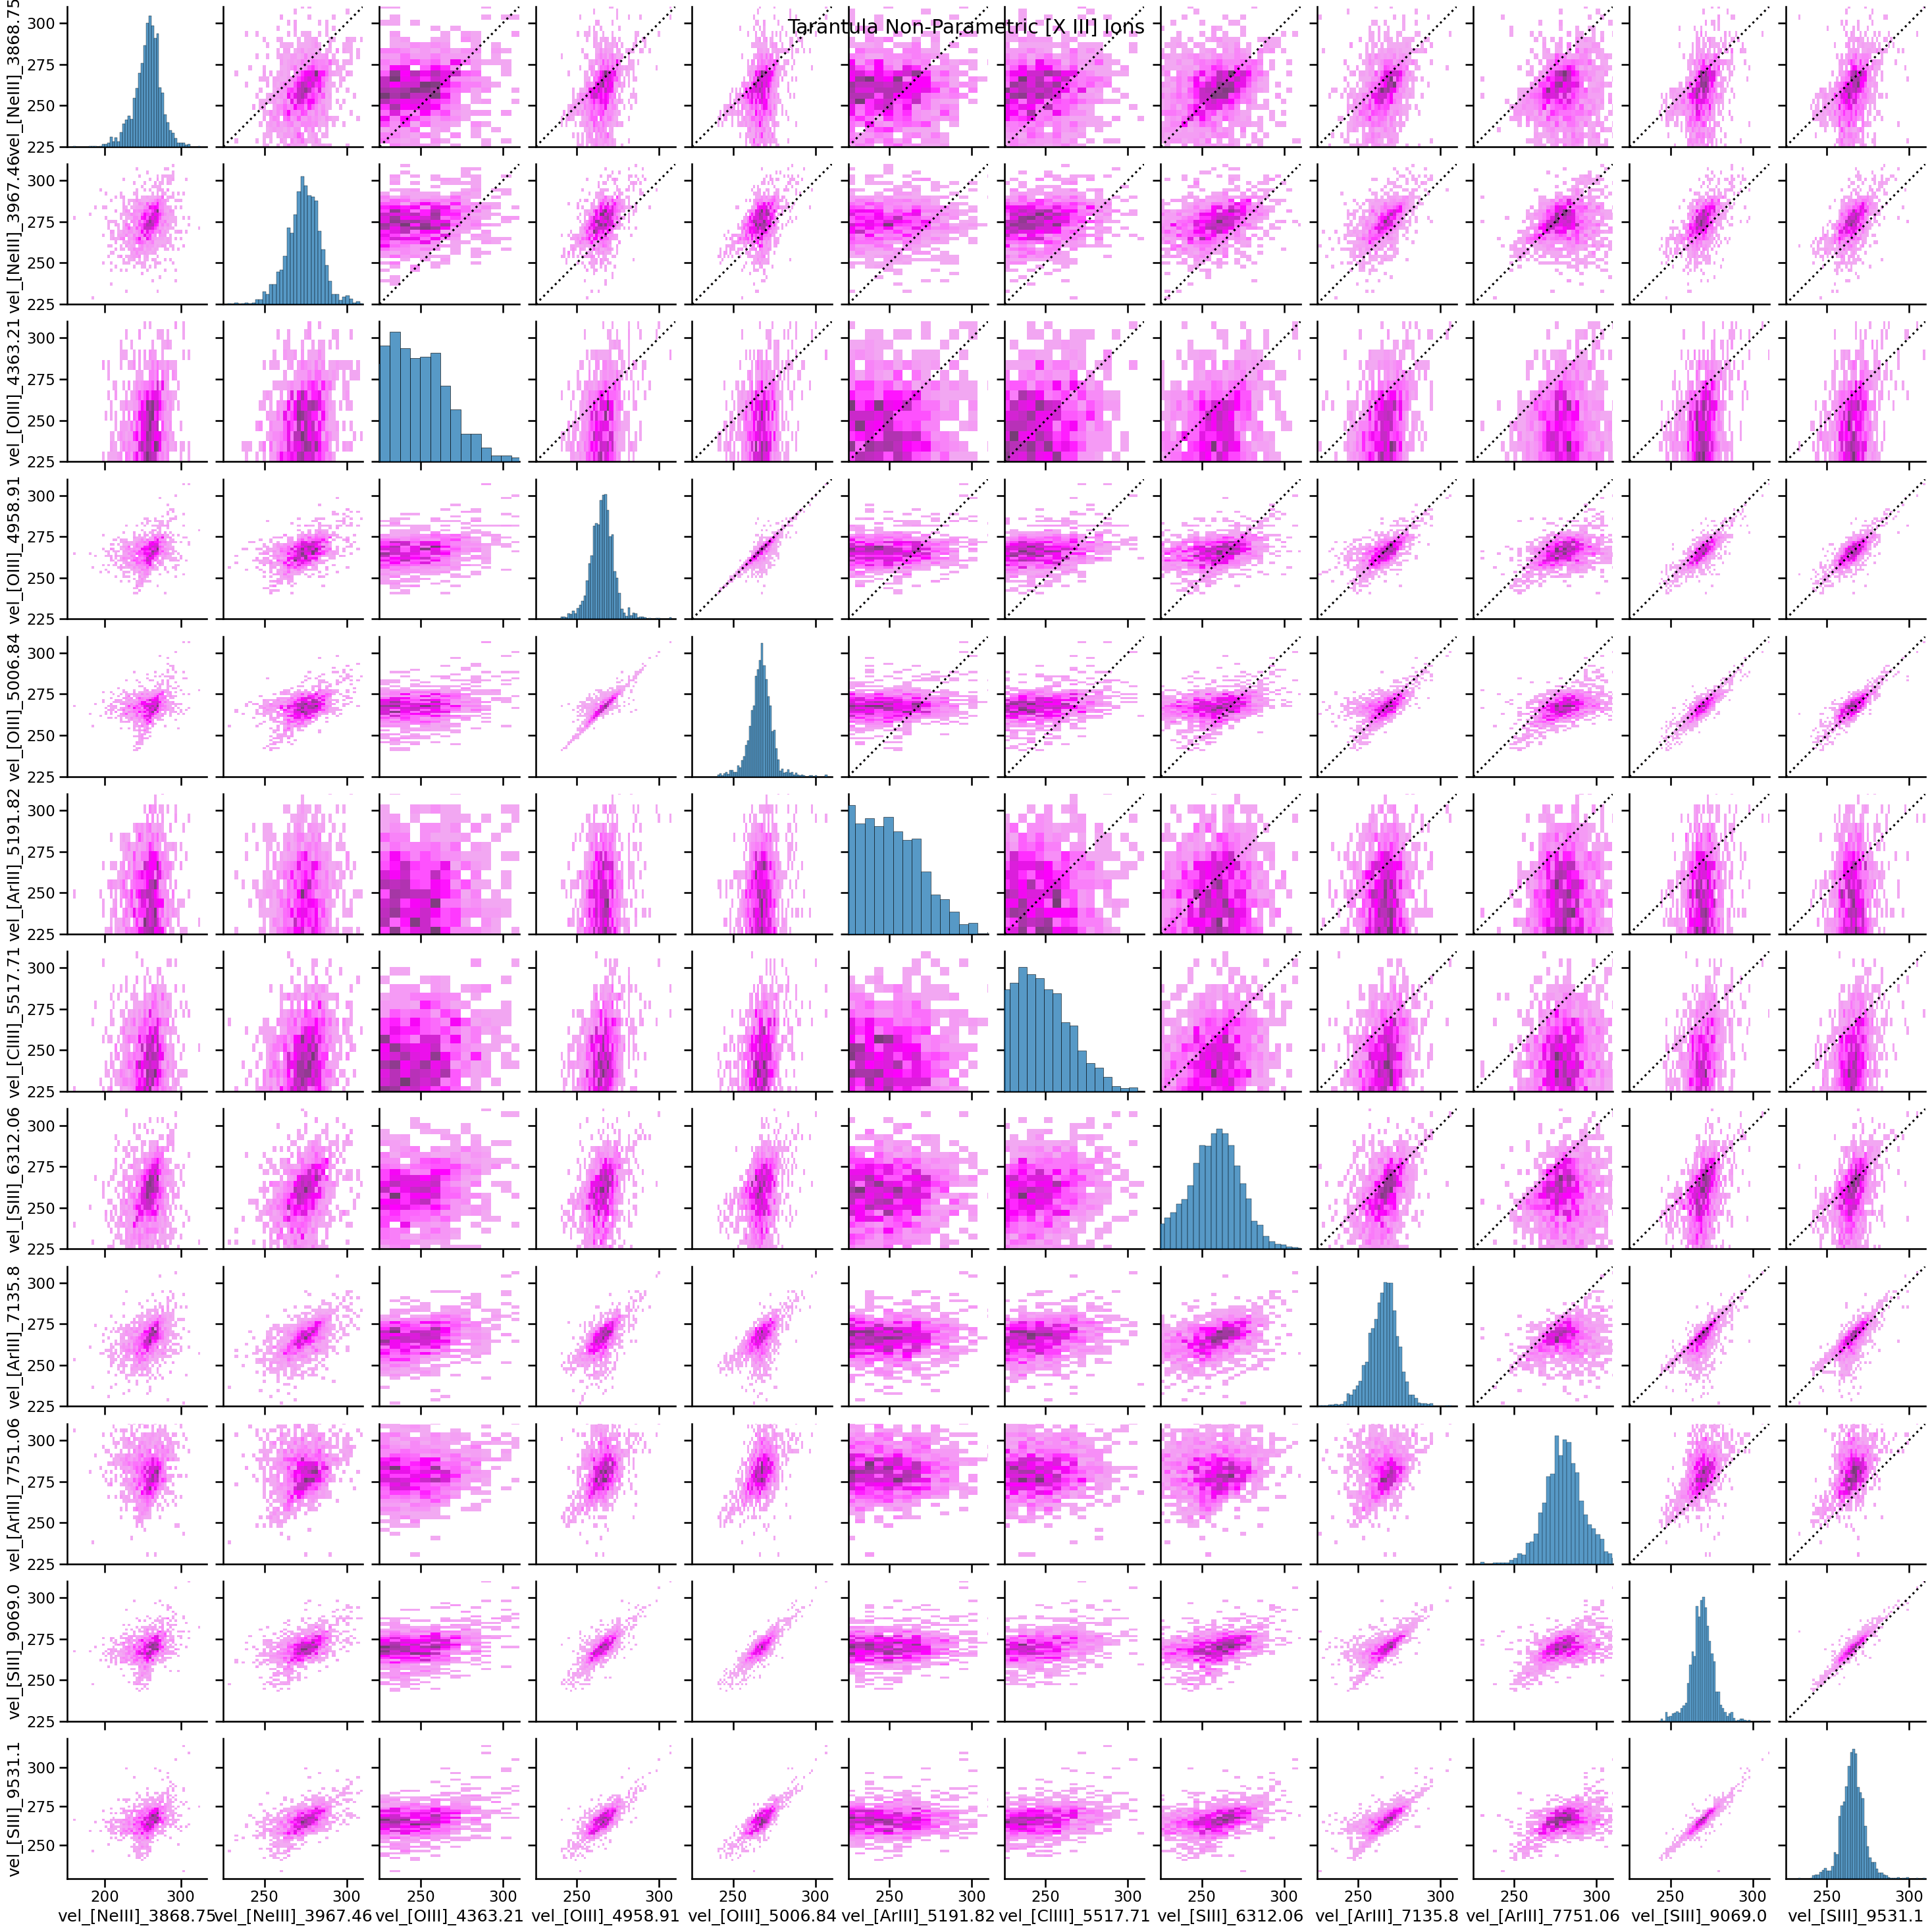

In [67]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    vars=np_iii,
    kind="hist",
    plot_kws=dict(color="purple"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric [X III] Ions")
g.fig.savefig("tarantula-np-iii-vel-correlations.pdf")

In [68]:
df_np[np_iii].corr()

,vel_[NeIII]_3868.75,vel_[NeIII]_3967.46,vel_[OIII]_4363.21,vel_[OIII]_4958.91,vel_[OIII]_5006.84,vel_[ArIII]_5191.82,vel_[ClIII]_5517.71,vel_[SIII]_6312.06,vel_[ArIII]_7135.8,vel_[ArIII]_7751.06,vel_[SIII]_9069.0,vel_[SIII]_9531.1
vel_[NeIII]_3868.75,1.000000,0.302762,0.156766,0.335569,0.295065,0.049452,0.106969,0.271273,0.376785,0.066629,0.356792,0.353090
vel_[NeIII]_3967.46,0.302762,1.000000,0.175666,0.503610,0.492650,0.097588,0.206237,0.338493,0.567971,0.218839,0.554261,0.576250
vel_[OIII]_4363.21,0.156766,0.175666,1.000000,0.209126,0.159573,0.043345,0.157618,0.223126,0.283877,0.012539,0.216350,0.232155
vel_[OIII]_4958.91,0.335569,0.503610,0.209126,1.000000,0.872995,0.184058,0.246279,0.347597,0.660770,0.394299,0.791222,0.792114
vel_[OIII]_5006.84,0.295065,0.492650,0.159573,0.872995,1.000000,0.198529,0.245595,0.316165,0.604508,0.503002,0.856344,0.844926
vel_[ArIII]_5191.82,0.049452,0.097588,0.043345,0.184058,0.198529,1.000000,0.046814,0.085027,0.171532,0.110146,0.198058,0.188159
vel_[ClIII]_5517.71,0.106969,0.206237,0.157618,0.246279,0.245595,0.046814,1.000000,0.199853,0.271439,0.062989,0.278602,0.297937
vel_[SIII]_6312.06,0.271273,0.338493,0.223126,0.347597,0.316165,0.085027,0.199853,1.000000,0.415337,0.059633,0.391627,0.405495
vel_[ArIII]_7135.8,0.376785,0.567971,0.283877,0.660770,0.604508,0.171532,0.271439,0.415337,1.000000,0.242749,0.702827,0.749837
vel_[ArIII]_7751.06,0.066629,0.218839,0.012539,0.394299,0.503002,0.110146,0.062989,0.059633,0.242749,1.000000,0.481897,0.468352


In [69]:
np_iii_best = [
    "vel_[OIII]_4958.91",
    "vel_[OIII]_5006.84",
    "vel_[ArIII]_7135.8",
    "vel_[SIII]_9069.0",
    "vel_[SIII]_9531.1",
    "vel_Halpha_6562.85",
]

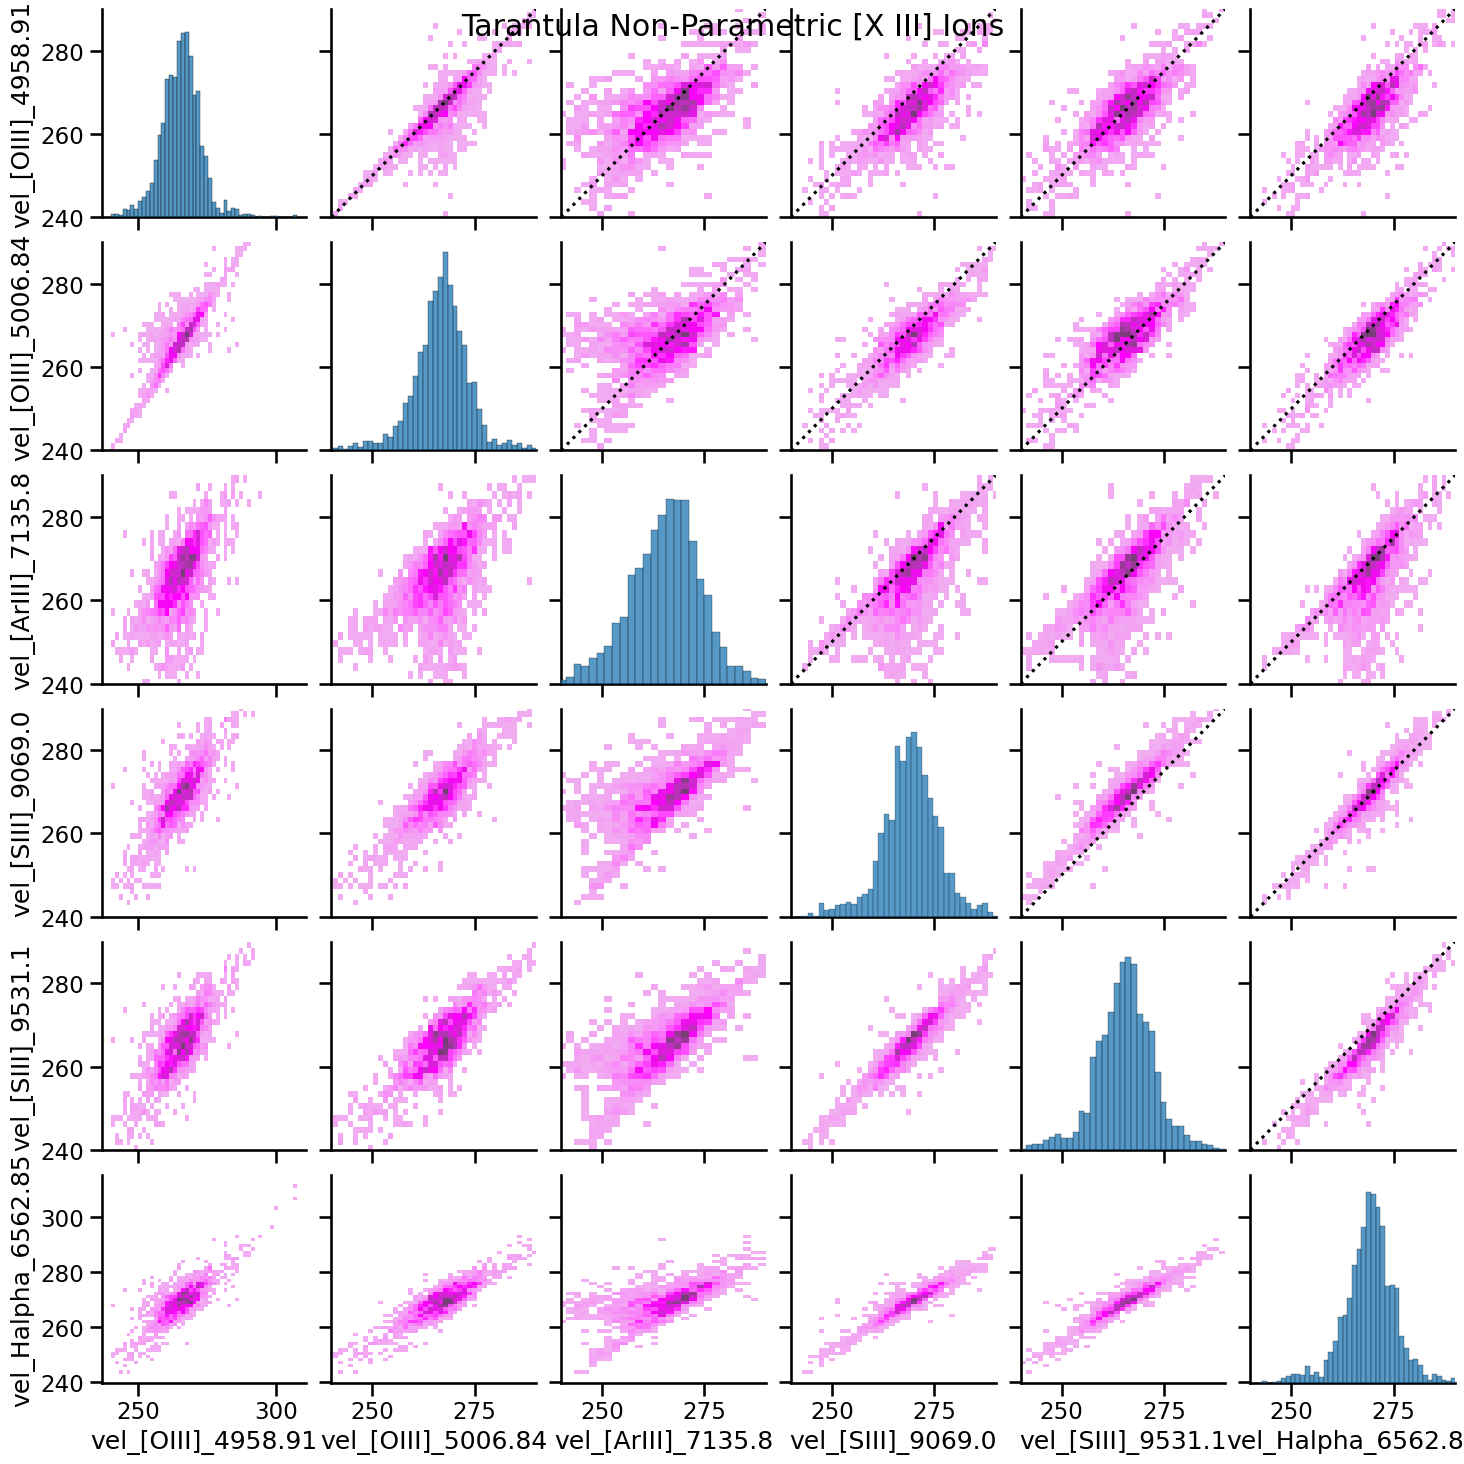

In [70]:
vmin, vmax = 240, 290
g = sns.pairplot(
    df_np,
    vars=np_iii_best,
    kind="hist",
    plot_kws=dict(color="purple"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Non-Parametric [X III] Ions")
g.fig.savefig("tarantula-np-iii-best-vel-correlations.pdf")

#### H lines

### Cross correlations between line classes

#### Singly vs doubly ionized

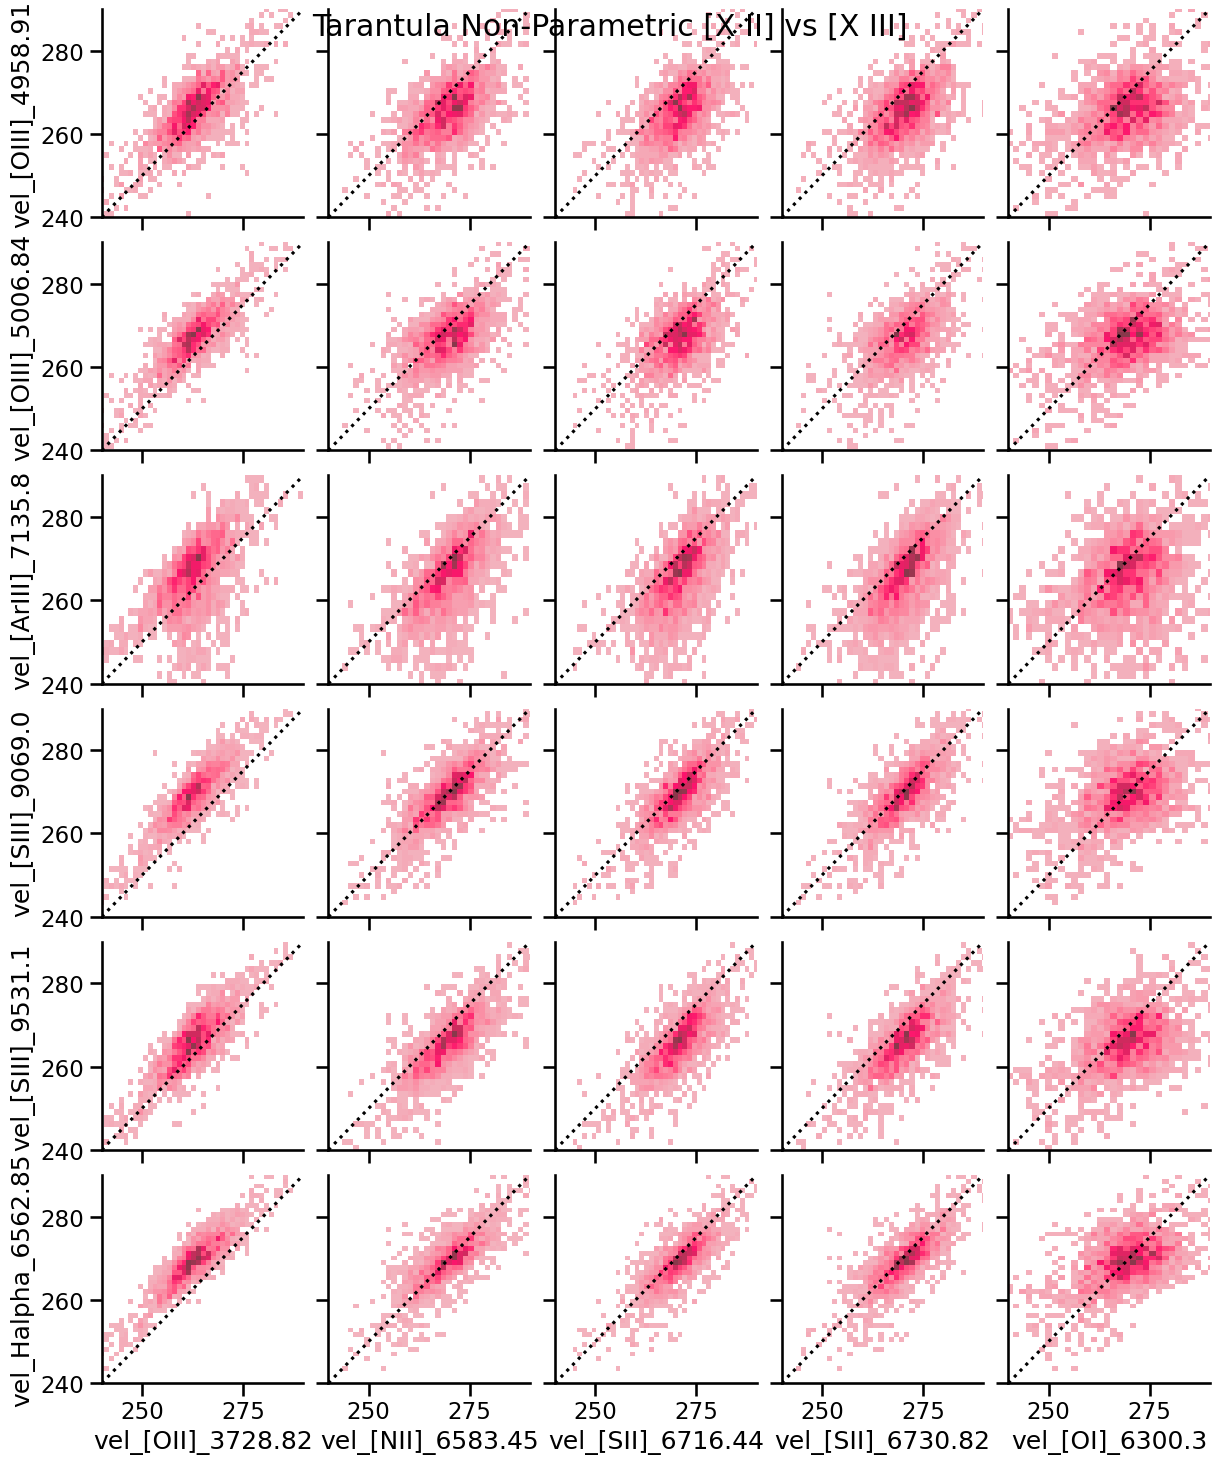

In [71]:
vmin, vmax = 240, 290
g = sns.pairplot(
    df_np,
    x_vars=np_ii_best,
    y_vars=np_iii_best,
    kind="hist",
    plot_kws=dict(color="pink"),
).map(draw_line)
g.fig.suptitle("Tarantula Non-Parametric [X II] vs [X III]")
g.fig.savefig("tarantula-np-ii-iii-vel-correlations.pdf")

Correlation matrix for the cross comparison

In [72]:
from great_tables import GT

In [73]:
GT(
    df_np[np_ii_best + np_iii_best].corr().loc[np_iii_best, np_ii_best].reset_index(),
    rowname_col="index",
).fmt_number(
    decimals=3,
).data_color(
    domain=[0.7, 1], palette=["white", "darkgreen"], na_color="white"
).opt_stylize(style=1).tab_options(
    column_labels_font_size="x-small",
    stub_font_size="x-small",
)

,vel_[OII]_3728.82,vel_[NII]_6583.45,vel_[SII]_6716.44,vel_[SII]_6730.82,vel_[OI]_6300.3
vel_[OIII]_4958.91,0.736,0.622,0.586,0.566,0.407
vel_[OIII]_5006.84,0.838,0.635,0.604,0.593,0.473
vel_[ArIII]_7135.8,0.589,0.654,0.623,0.618,0.341
vel_[SIII]_9069.0,0.860,0.767,0.752,0.744,0.497
vel_[SIII]_9531.1,0.846,0.792,0.761,0.758,0.500
vel_Halpha_6562.85,0.898,0.804,0.796,0.781,0.542


#### Low versus high ionization

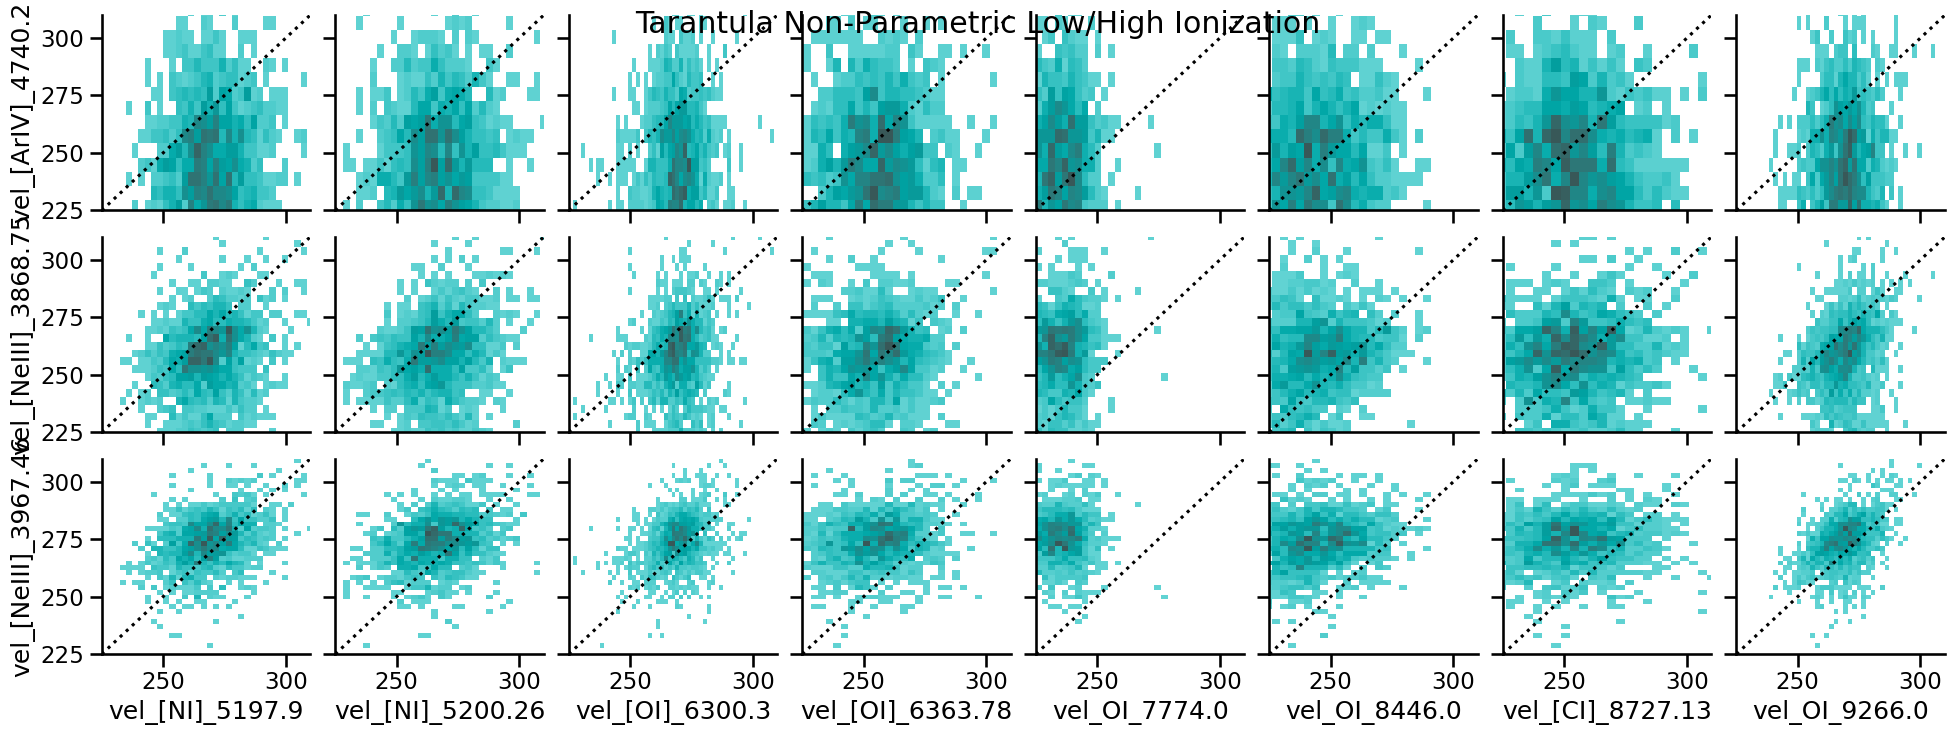

In [74]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_np,
    x_vars=np_low,
    y_vars=np_high,
    kind="hist",
    plot_kws=dict(color="c"),
).map(draw_line)
g.fig.suptitle("Tarantula Non-Parametric Low/High Ionization")
g.fig.savefig("tarantula-np-low-high-vel-correlations.pdf")

Strangely, the velocities of the low ionization lines and the high ionization lines are reasonably well correlated.

In [75]:
GT(
    df_np[np_low + np_high].corr().loc[np_high, np_low].reset_index(),
    rowname_col="index",
).fmt_number(
    decimals=3,
).data_color(
    domain=[0.0, 1], palette=["brown", "white", "darkgreen"], na_color="white"
).opt_stylize(style=1).tab_options(
    column_labels_font_size="x-small",
    stub_font_size="x-small",
)

,vel_[NI]_5197.9,vel_[NI]_5200.26,vel_[OI]_6300.3,vel_[OI]_6363.78,vel_OI_7774.0,vel_OI_8446.0,vel_[CI]_8727.13,vel_OI_9266.0
vel_[ArIV]_4740.2,0.109,0.111,0.079,0.048,0.160,0.036,0.090,0.116
vel_[NeIII]_3868.75,0.202,0.187,0.142,0.110,0.186,0.185,0.121,0.274
vel_[NeIII]_3967.46,0.364,0.297,0.324,0.215,0.336,0.186,0.151,0.443


### Other parametric lines

The `.xs()` method allows us to select all the vel columns.

In [76]:
df_pm_vel = df_pm_elines.xs("vel", axis=1)
df_pm_vel

wl,3726.03,3728.82,4101.77,4340.49,4861.36,4958.91,5006.84,6300.30,6548.05,6562.85,6583.45,6716.44,6730.82,9069.00,9531.10
id_fib,,,,,,,,,,,,,,,
0,265.5879,265.5879,270.4220,263.6887,269.4501,269.4501,269.4501,296.1292,271.2948,271.2948,271.2948,277.4763,277.4763,273.6001,267.3376
1,266.4029,266.4029,261.8148,273.3482,267.3642,267.3642,267.3642,294.7292,267.8486,267.8486,267.8486,275.7682,275.7682,269.5091,273.1160
2,269.3997,269.3997,255.5212,256.4234,272.4031,272.4031,272.4031,292.5782,271.6251,271.6251,271.6251,276.3876,276.3876,276.4232,280.4940
3,268.4192,268.4192,219.9630,241.2152,257.3260,257.3260,257.3260,281.8938,257.2515,257.2515,257.2515,263.4306,263.4306,251.3689,257.1261
4,251.7254,251.7254,255.1295,247.9752,253.6183,253.6183,253.6183,275.9567,247.3627,247.3627,247.3627,249.6368,249.6368,247.4910,245.9588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1749,270.1227,270.1227,257.3550,263.5846,266.7081,266.7081,266.7081,282.5440,268.6882,268.6882,268.6882,272.7283,272.7283,271.3321,266.3569
1750,275.8787,275.8787,248.3793,267.3432,272.0620,272.0620,272.0620,285.6954,273.7483,273.7483,273.7483,280.7698,280.7698,282.6559,273.6822
1751,283.0021,283.0021,271.6702,277.1294,272.4463,272.4463,272.4463,277.1955,272.9735,272.9735,272.9735,276.5727,276.5727,275.9943,270.4426


In [77]:
df_pm_vel.columns

Index([3726.03, 3728.82, 4101.77, 4340.49, 4861.36, 4958.91, 5006.84,  6300.3,
       6548.05, 6562.85, 6583.45, 6716.44, 6730.82,  9069.0,  9531.1],
      dtype='float64', name='wl')

Some of these are tied together, so I select the ones that are all independent. This means removing [N II] lines (tied to H alpha) and [O III] lines (tied to H beta).

*I am not sure why they did this, and it seems unwise to me*. We would expect that the high ionization lines (e.g., [O III]) and low ionization lines (e.g., [N II]) should differ slightly in their kinematics. See García-Díaz & Henney (2008). And this is therefore going to separate out Ha (biased by N II) from Hb (biased by [O III]).



In [78]:
pm_columns = [
    3726.03,
    4101.77,
    4340.49,
    4861.36,
    6300.3,
    6562.85,
    6716.44,
    9069.0,
    9531.1,
]

In [79]:
pm_columns2 = [3726.03, 4340.49, 6562.85, 6716.44, 9069.0]

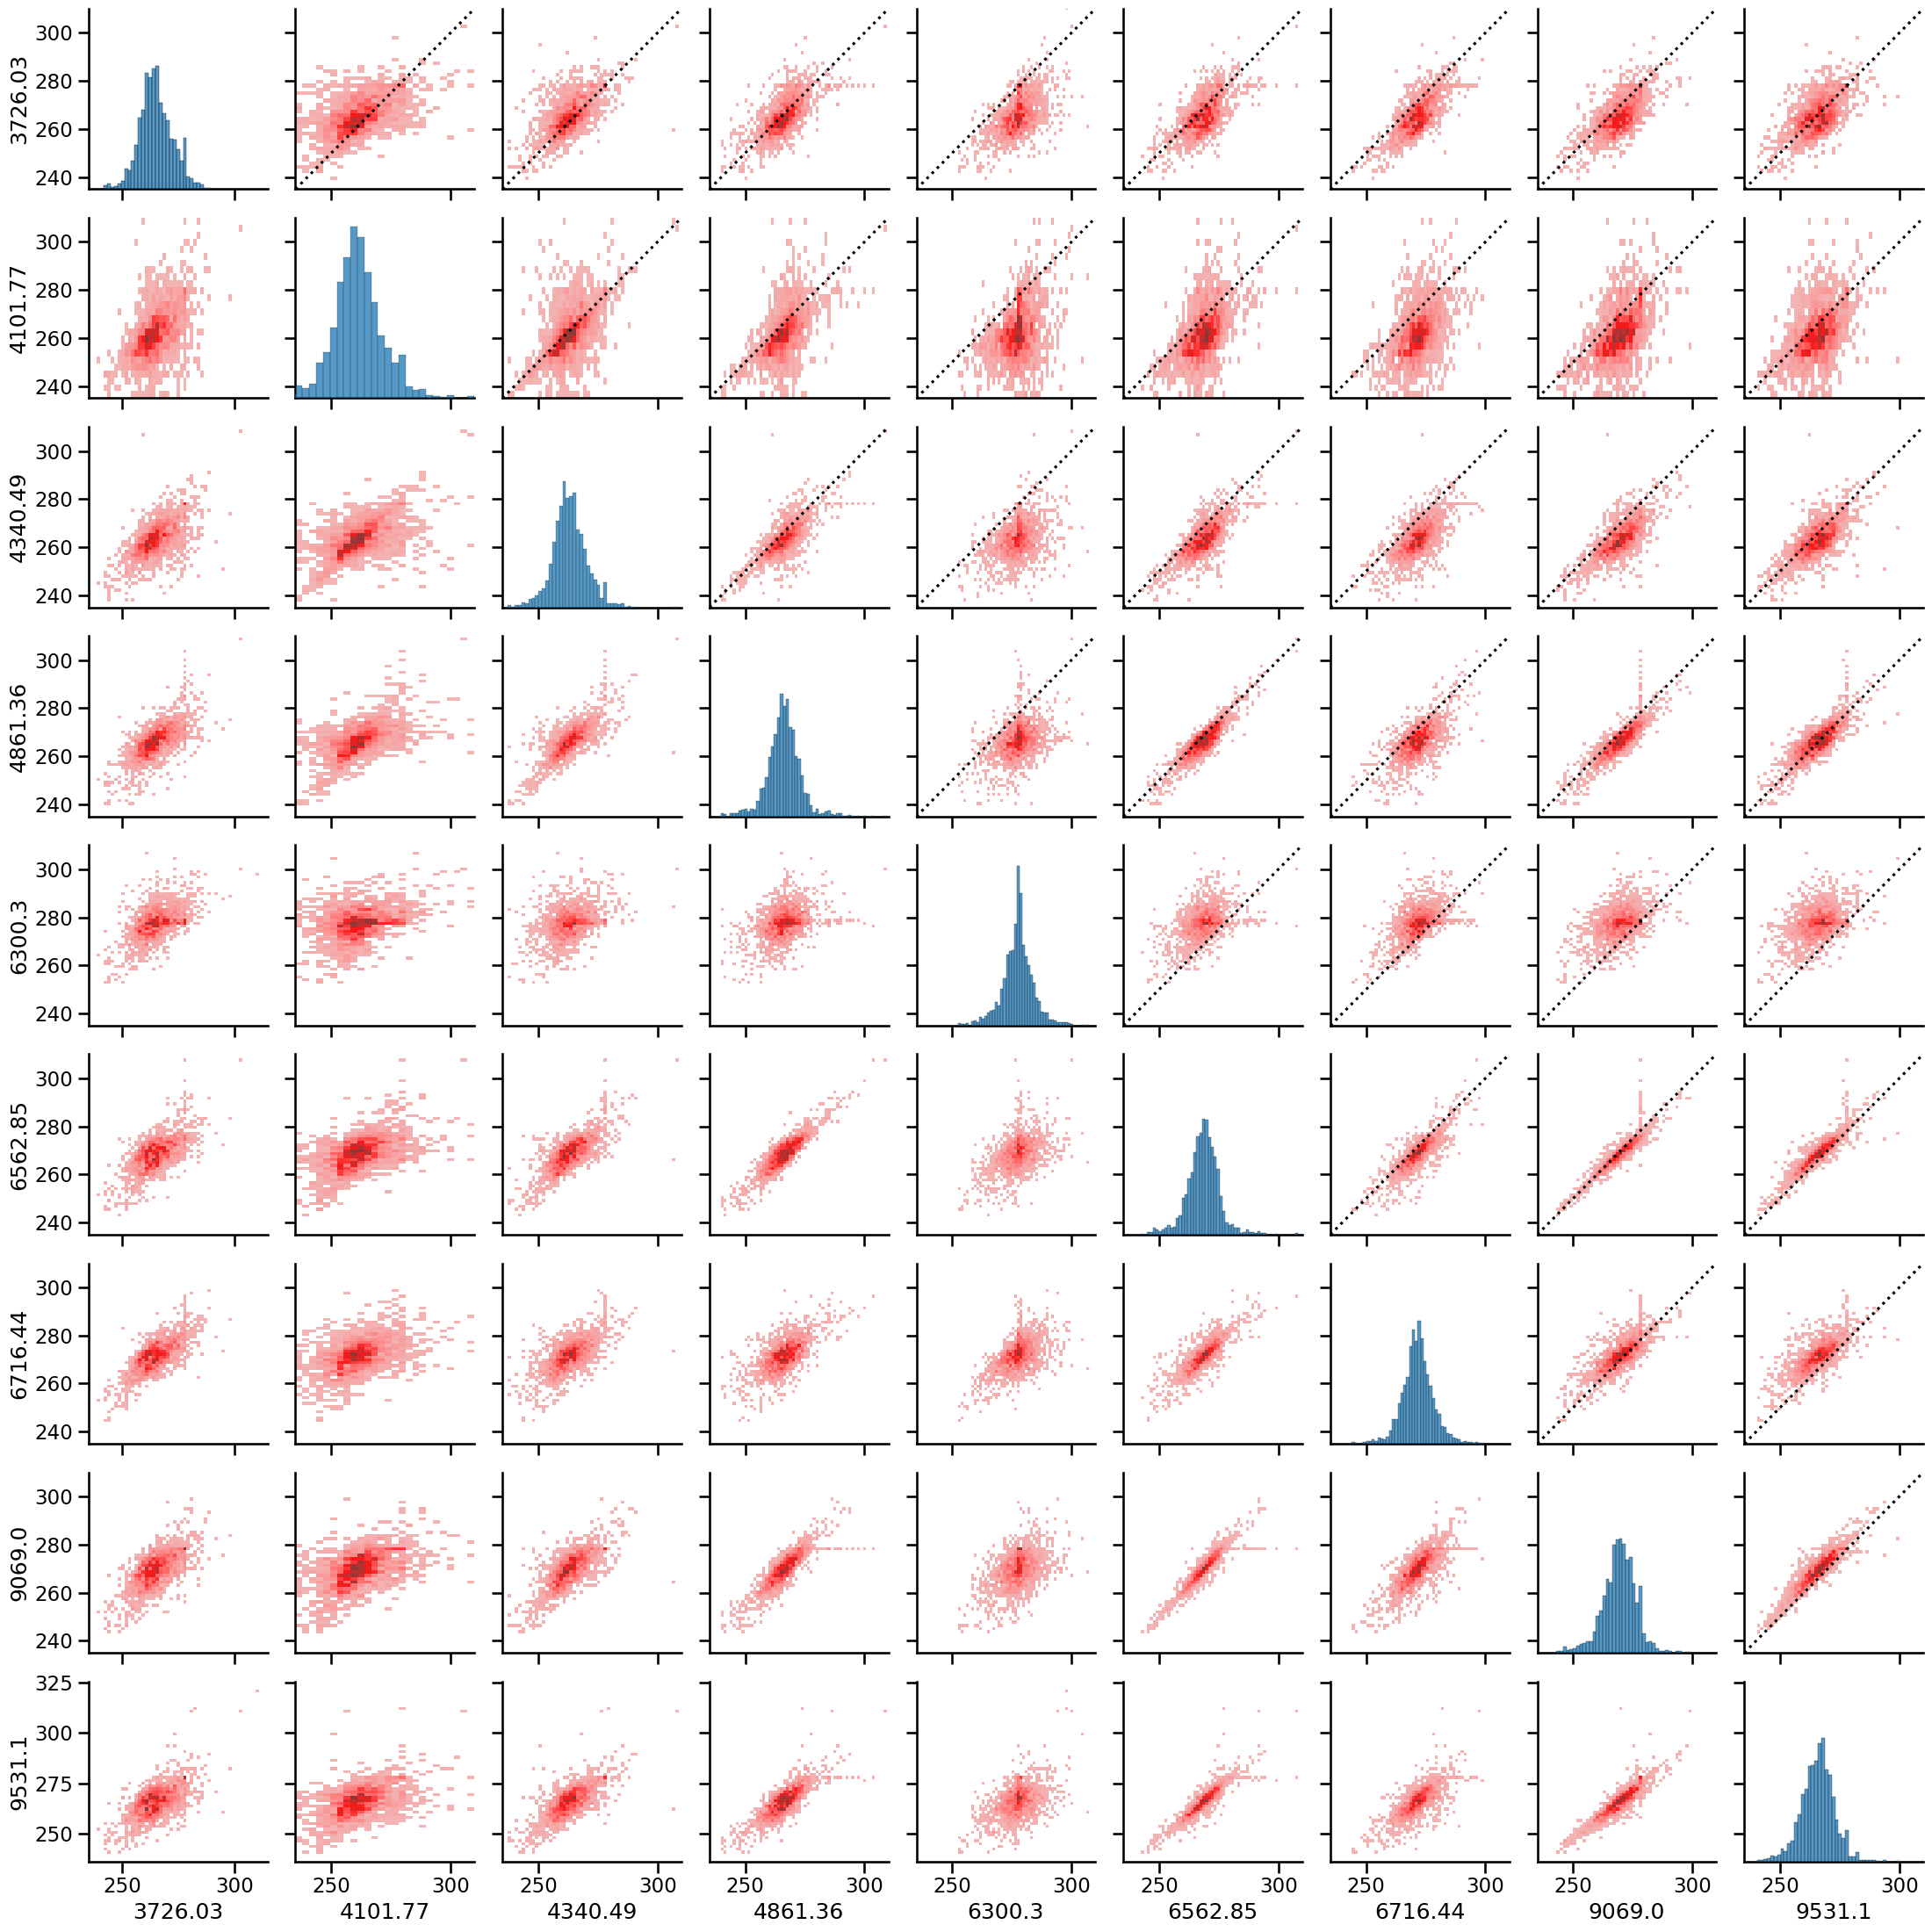

In [80]:
vmin, vmax = 235, 310
sns.pairplot(
    df_pm_elines.xs("vel", axis=1),
    vars=pm_columns,
    kind="hist",
    plot_kws=dict(color="r"),
).map_upper(draw_line)

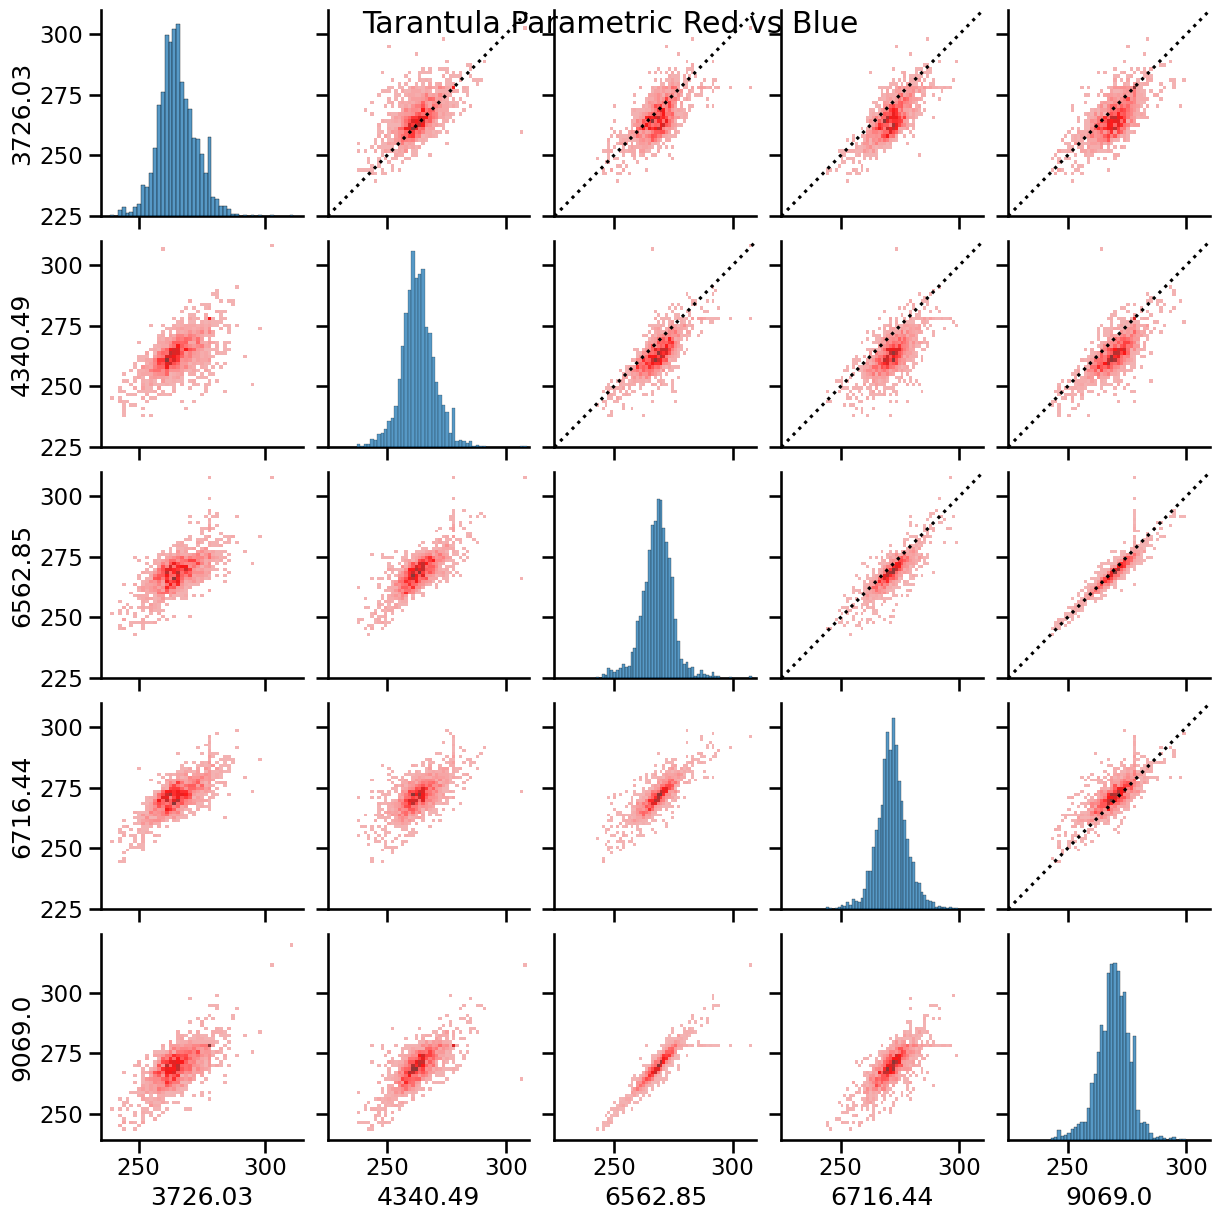

In [81]:
vmin, vmax = 225, 310
g = sns.pairplot(
    df_pm_vel,
    vars=pm_columns2,
    kind="hist",
    plot_kws=dict(color="r"),
).map_upper(draw_line)
g.fig.suptitle("Tarantula Parametric Red vs Blue")
g.fig.savefig("tarantula-pm-blue-red-vel-correlations.pdf")

In [82]:
g.fig.savefig("tarantula-pm-blue-red-vel-correlations.pdf")

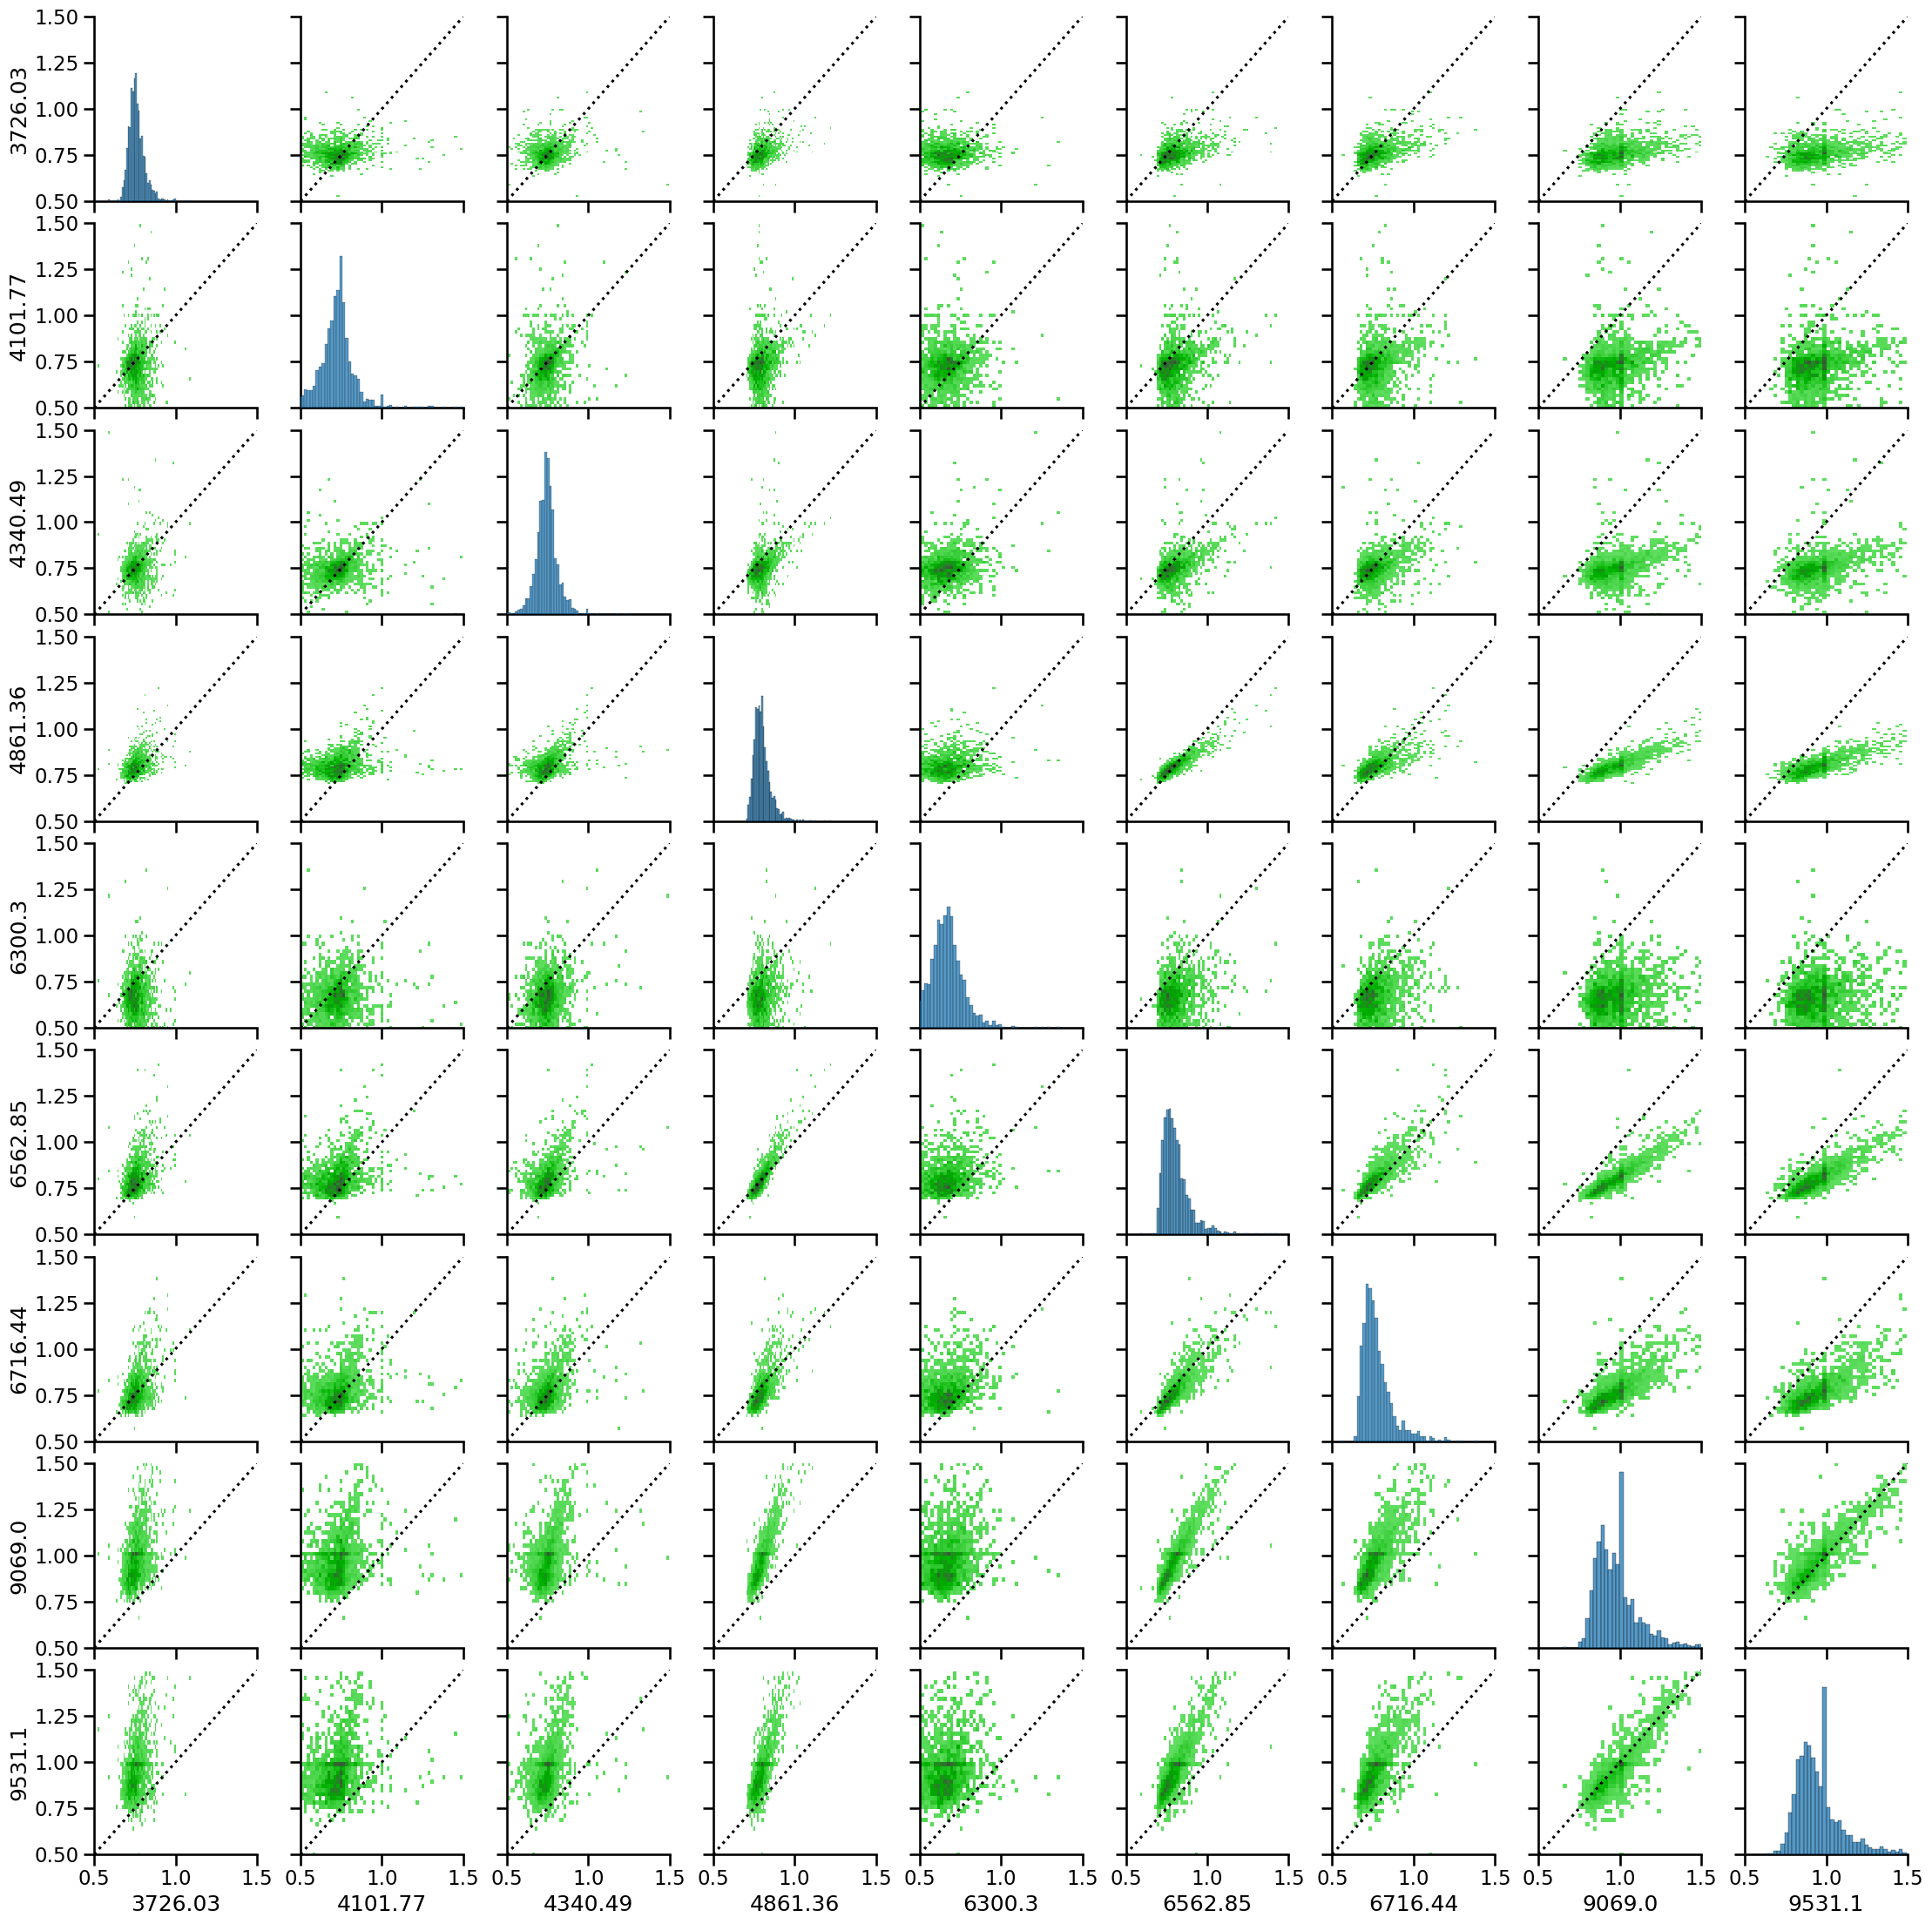

In [83]:
vmin, vmax = 0.5, 1.5
sns.pairplot(
    df_pm_elines.xs("disp", axis=1),
    vars=pm_columns,
    kind="hist",
    plot_kws=dict(color="g"),
).map_offdiag(draw_line)

## Making scatter maps from the tables

Reference coordinate centered on Tarantula Nebula

In [84]:
c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

Generate a dummy WCS for plotting with pixel size of 1 arcsecond and size 1 degree

In [85]:
from astropy.wcs import WCS

In [86]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count


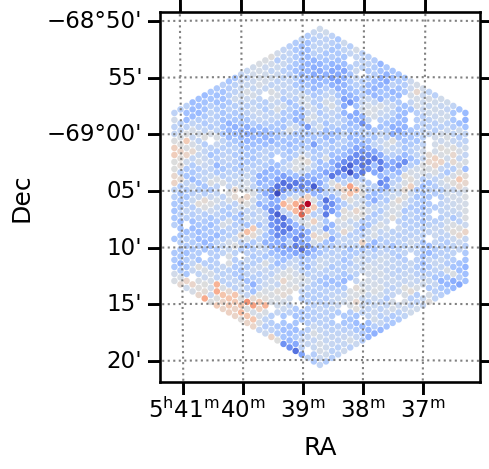

In [87]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
ax.scatter(
    c.ra.deg,
    c.dec.deg,
    transform=ax.get_transform("world"),
    s=10,
    edgecolor=None,
    c=tab_np_elines_r["vel_Halpha_6562.85"],
    cmap="coolwarm",
)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_aspect("equal")

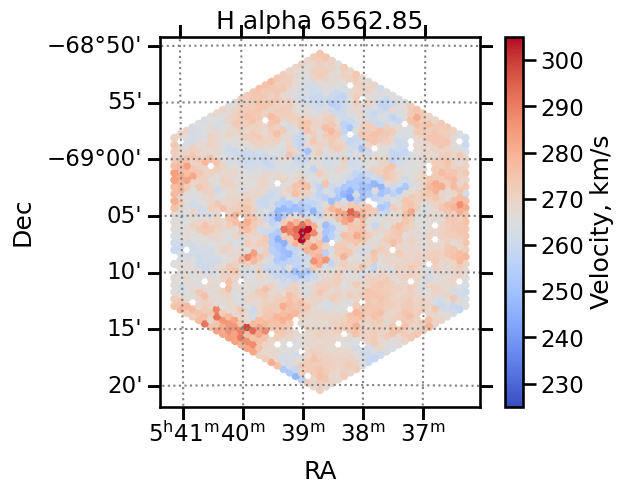

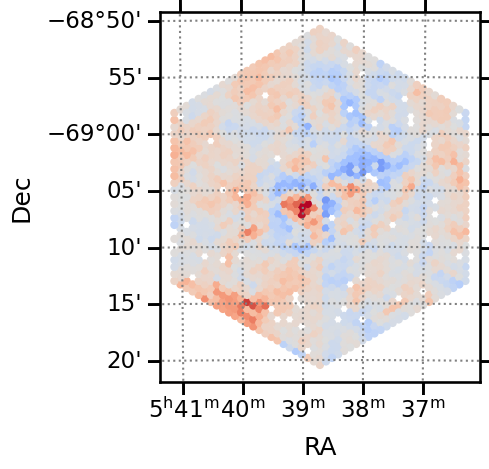

In [88]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
scat = ax.scatter(
    c.ra.deg,
    c.dec.deg,
    transform=ax.get_transform("world"),
    s=20,
    edgecolor=None,
    c=df_pm_elines[("vel", 6562.85)],
    cmap="coolwarm",
    vmin=225,
    vmax=305,
)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title("H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
ax.scatter(
    c.ra.deg,
    c.dec.deg,
    transform=ax.get_transform("world"),
    s=20,
    edgecolor=None,
    c=df_pm_elines[("vel", 5006.84)],
    cmap="coolwarm",
    vmin=225,
    vmax=305,
)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_aspect("equal")

In [89]:
ax.get_xlim(), ax.get_ylim()

((np.float64(2745.3224052943565), np.float64(4440.935376759968)),
 (np.float64(2643.770046876539), np.float64(4601.66110090352)))

In [90]:
tab_np_elines_r["vel_Halpha_6562.85"]

271.23285442243787
267.0337768881025
271.02259296725754
258.1981504666365
248.93487252186682
254.35596307196428
254.36592842156332
277.27144848122913
281.62107594145516
273.1707388360088
271.3439611693526


In [91]:
len(c)

1754

## Repeat for other exposures

In [92]:
from pathlib import Path

### List of all the pointings

In [93]:
files = sorted(Path.cwd().glob("dap-120-tarantula/*.fits"))
files

[PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00003735.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00008373.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009291.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009292.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009294.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009333.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009334.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009335.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009336.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009337.dap.fits'),
 PosixPath('/Users/javier/LVM_30dor/dap-120-tarantula/dap-rsp108-sn20-00009338.dap.fits'),

In [94]:
len(files)

202

### Table of the heliocentric corrections

In [95]:
heliotab = Table(
    [
        {
            "file": (h := fits.open(_)[0].header).get("FILENAME"),
            "heliorv": h.get("HIERARCH WAVE HELIORV_SCI"),
            "obstime": h.get("OBSTIME"),
        }
        for _ in files
    ]
)
heliotab

file,heliorv,obstime
str23,float64,str23
lvmSFrame-00003735.fits,-0.6423,2023-08-25T09:38:12.565
lvmSFrame-00008373.fits,-1.3644,2023-11-27T02:08:10.388
lvmSFrame-00009291.fits,-1.7346,2023-12-13T07:27:19.964
lvmSFrame-00009292.fits,-1.7404,2023-12-13T07:43:14.904
lvmSFrame-00009294.fits,-1.7535,2023-12-13T08:06:37.470
lvmSFrame-00009333.fits,-1.5095,2023-12-14T01:16:35.008
lvmSFrame-00009334.fits,-1.5177,2023-12-14T01:32:32.521
lvmSFrame-00009335.fits,-1.5216,2023-12-14T01:48:27.620
lvmSFrame-00009336.fits,-1.5328,2023-12-14T02:05:26.083


### Class to hold a single pointing

In [96]:
class Pointing:
    def __init__(self, fitsfile, apply_helio=True):
        self.tab_pt = Table.read(fitsfile, hdu="PT")
        self.tab_pm = Table.read(fitsfile, hdu="PM_ELINES")
        self.exposure = self.tab_pt["exposure"][0]
        self.coords = SkyCoord(
            ra=self.tab_pt["ra"] * u.deg,
            dec=self.tab_pt["dec"] * u.deg,
        )
        self.emcolumns = self.tab_pm.colnames[4:]
        self.df_pm = pd.pivot(
            # drop_duplicates needed to ensure pivot will work
            self.tab_pm.to_pandas().drop_duplicates(subset=["id_fib", "wl"]),
            index="id_fib",
            columns="wl",
            values=self.emcolumns,
        )
        self.df_np_b = Table.read(fitsfile, hdu="NP_ELINES_B").to_pandas()
        self.df_np_r = Table.read(fitsfile, hdu="NP_ELINES_R").to_pandas()
        self.df_np_i = Table.read(fitsfile, hdu="NP_ELINES_I").to_pandas()
        # Remove garbage wavelength column if present
        if 0.0 in self.df_pm.columns:
            self.df_pm = self.df_pm.drop(columns=[0.0])
        # Find the heliocentric correction
        hdr = fits.open(fitsfile)[0].header
        self.helio = hdr.get("HIERARCH WAVE HELIORV_SCI")
        if apply_helio:
            # Add the helio correction to all the velocity columns
            self.df_pm.loc[:, ("vel", slice(None))] += self.helio

### Test individual fields

In [97]:
p = Pointing(files[0], apply_helio=True)

In [98]:
p.coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.65      , -69.33053993), (84.67528433, -69.325388  ),
     (84.70055662, -69.32023239), ..., (84.12857359, -68.94348297),
     (84.10368789, -68.94855554), (84.07870385, -68.95362419)]>

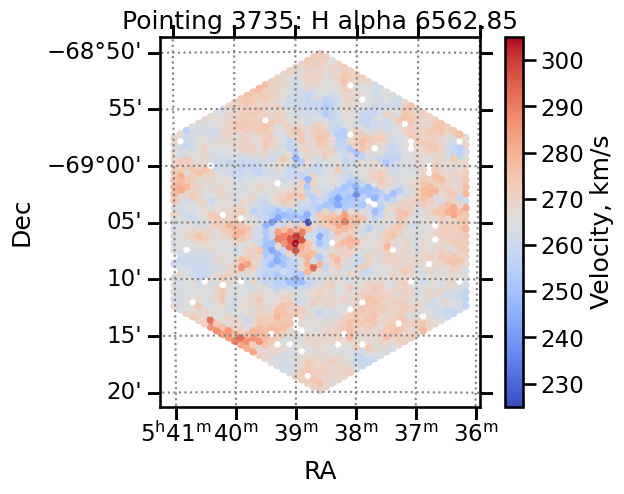

In [99]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
scat = ax.scatter(
    p.coords.ra.deg,
    p.coords.dec.deg,
    transform=ax.get_transform("world"),
    s=20,
    edgecolor=None,
    c=p.df_pm[("vel", 6562.85)],
    cmap="coolwarm",
    vmin=225,
    vmax=305,
)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"Pointing {p.exposure}: H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;

# My test

In [119]:
import json

class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)

In [120]:
#p = Pointing(files[0], apply_helio=True)

In [130]:
p.df_pm.columns[0][1]

np.float64(3726.03)

In [117]:
line_values = []
for col in p.df_pm.columns:
    if col[1] not in line_values:
        line_values.append(col[1])

In [123]:
line_values

[3726.03,
 3728.82,
 4101.77,
 4340.49,
 4861.36,
 4958.91,
 5006.84,
 6300.3,
 6548.05,
 6562.85,
 6583.45,
 6716.44,
 6730.82,
 9069.0,
 9531.1]

In [124]:
import json
import numpy as np

p = Pointing(files[0], apply_helio=True)

line_values = []
for col in p.df_pm.columns:
    if col[1] not in line_values:
        line_values.append(col[1])

for line_value in line_values:
    all_arrays = []

    for i in range(202):
        p = Pointing(files[i], apply_helio=True)

        arr0 = p.coords.ra.deg
        arr1 = p.coords.dec.deg
        arr2 = np.array(p.df_pm[("vel", line_value)])
        arr3 = np.array(p.df_pm[("flux", line_value)])
        arr4 = np.array(p.df_pm[("disp", line_value)])

        temp_array = np.column_stack((arr0, arr1, arr2, arr3, arr4))
        all_arrays.append(temp_array)

    big_array = np.vstack(all_arrays)

    name = f"LVM-30Dor-{int(round(line_value))}"

    data_export_list = {
        "name": name,
        "data": big_array,
    }

    jsonfilename = "observations/" + name + "-l.json"
    with open(jsonfilename, "w") as f:
        json.dump(data_export_list, fp=f, indent=3, cls=MyEncoder)

In [ ]:
xxx

# Other pointings

In [ ]:
p = Pointing(files[2])

In [ ]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
scat = ax.scatter(
    p.coords.ra.deg,
    p.coords.dec.deg,
    transform=ax.get_transform("world"),
    s=20,
    edgecolor=None,
    c=p.df_pm[("vel", 6562.85)],
    cmap="coolwarm",
    vmin=225,
    vmax=305,
)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"Pointing {p.exposure}: H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;


### Combine all the fields

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=0.3,
        edgecolor=None,
        c=p.df_pm[("vel", 6562.85)],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: H alpha 6562.85")
ax.set_aspect("equal")
ax.set_facecolor("gray")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...
x1, x2 = ax.get_xlim()
y1, y2 = ax.get_ylim()
xc, yc = np.mean([x1, x2]), np.mean([y1, y2])
xc, yc

In [ ]:
f

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=40,
        edgecolor=None,
        c=p.df_pm[("vel", 6562.85)],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"Zoom all Pointings: H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

p = Pointing(files[0])
scat = ax.scatter(
    p.coords.ra.deg,
    p.coords.dec.deg,
    transform=ax.get_transform("world"),
    s=40,
    edgecolor="k",
    c=p.df_pm[("vel", 6562.85)],
    cmap="coolwarm",
    vmin=225,
    vmax=305,
)
ax.set_facecolor("gray")
ax.set(
    xlim=[xc - 400, xc + 400],
    ylim=[yc - 400, yc + 400],
)
...;

In [ ]:
RMAX_ARCSEC = 1650

fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    m = p.coords.separation(c0) <= RMAX_ARCSEC * u.arcsec
    if not np.any(m):
        continue
    scat = ax.scatter(
        p.coords.ra.deg[m],
        p.coords.dec.deg[m],
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("vel", 6562.85)][m],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")


ax.set_facecolor("gray")
ax.set(
    xlim=[xc - RMAX_ARCSEC, xc + RMAX_ARCSEC],
    ylim=[yc - RMAX_ARCSEC, yc + RMAX_ARCSEC],
)
...;

The above shows a zoom of the central region. The black outlined symbols are from one particular pointing. This shows that the full sampling is improved by a factor of about 4

Mostly, the velocities are smooth on the sub-fiber scale. But there are some exceptions where we see systematic pattern of jumps between adjacent points


In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("vel", 4861.36)],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: H beta 4861.36")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("vel", 9069.0)],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [S III] 9069.0")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("vel", 6716.44)],
        cmap="coolwarm",
        vmin=225,
        vmax=305,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [S II] 6716.44")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
wav1, wav2 = 9069.0, 6716.44
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("vel", wav1)] - p.df_pm[("vel", wav2)],
        cmap="coolwarm",
        vmin=-20,
        vmax=20,
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: velocity difference {wav1} - {wav2})")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("flux", 6562.85)],
        cmap="magma",
        vmin=1e2,
        vmax=1e6,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All pointings: H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")

...;

In [ ]:
RMAX_ARCSEC = 1650

fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    m = p.coords.separation(c0) <= RMAX_ARCSEC * u.arcsec
    if not np.any(m):
        continue
    scat = ax.scatter(
        p.coords.ra.deg[m],
        p.coords.dec.deg[m],
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("flux", 6562.85)][m],
        cmap="magma",
        vmin=1e3,
        vmax=2e6,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
ax.set(
    xlim=[xc - RMAX_ARCSEC, xc + RMAX_ARCSEC],
    ylim=[yc - RMAX_ARCSEC, yc + RMAX_ARCSEC],
)
ax.set_facecolor("gray")

...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=2,
        edgecolor=None,
        c=p.df_pm[("flux", 6300.3)],
        cmap="magma",
        vmin=1e2,
        vmax=1e4,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [O I] 6300.3")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=2,
        edgecolor=None,
        c=p.df_np_b["flux_[NeIII]_3868.75"],
        cmap="magma",
        vmin=1e1,
        vmax=1e5,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [Ne III] 3868.75")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)

wav1, wav2 = 6300.3, 6562.85
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("flux", wav1)] / p.df_pm[("flux", wav2)],
        cmap="PuOr",
        vmin=1e-3,
        vmax=1e-1,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: {wav1} / {wav2}")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)

wav1, wav2 = 6583.45, 6562.85
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("flux", wav1)] / p.df_pm[("flux", wav2)],
        cmap="PuOr",
        vmin=2e-2,
        vmax=0.3,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: {wav1} / {wav2}")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)

wav1, wav2 = 9069.0, 6716.44
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("flux", wav1)] / p.df_pm[("flux", wav2)],
        cmap="PuOr",
        vmin=0.1,
        vmax=10,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: {wav1} / {wav2}")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)

wav1, wav2 = 5006.84, 4861.36
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=5,
        edgecolor=None,
        c=p.df_pm[("flux", wav1)] / p.df_pm[("flux", wav2)],
        cmap="PuOr",
        vmin=0.3,
        vmax=6,
        norm="log",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: {wav1} / {wav2}")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Flux")
...

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=3,
        edgecolor=None,
        c=p.df_pm[("disp", 6562.85)],
        cmap="viridis",
        vmin=0.5,
        vmax=1.5,
        norm="linear",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Dispersion")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=3,
        edgecolor=None,
        c=p.df_pm[("disp", 9069.0)],
        cmap="viridis",
        vmin=0.7,
        vmax=1.6,
        norm="linear",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [S III] 9069.0")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Dispersion")
...;

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw=dict(projection=wcs),
)
for f in files:
    p = Pointing(f)
    scat = ax.scatter(
        p.coords.ra.deg,
        p.coords.dec.deg,
        transform=ax.get_transform("world"),
        s=1,
        edgecolor=None,
        c=p.df_pm[("disp", 6716.44)],
        cmap="viridis",
        vmin=0.5,
        vmax=1.5,
        norm="linear",
    )
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"All Pointings: [S II] 6716.44")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Dispersion")
...;